# Syn Bank — Share of Wallet Intelligence Engine

**Team: *Put your money where your byte is*** — Vihan Allan, Joel Cedras, Viajul Moodley, Rahul Maharaj
Standard Bank & Stellenbosch University Hackathon, 2026

---

This notebook is the reproducible record of the production system. It runs the **same
modules** that build the dashboard and the generated briefings — nothing here is a parallel
implementation, a hand-typed figure, or a simplified restatement. Every number printed below
is either read back off the analytical contract (`data/processed/opportunity_engine.parquet`
and `client_opportunity_profile.parquet`) or computed by importing `src/syn_wallet/`.

| Companion document | What it holds |
|---|---|
| [`METHODOLOGY.md`](METHODOLOGY.md) | The formal methodology — this notebook's prose in reference form |
| `MODEL_FINAL_REPORT.md` | The analytical contract, generated from the Parquet |
| `MODEL_SENSITIVITY.md` | The 36-scenario sweep |
| `AUDIT_REPORT.md` | Data provenance and every known defect |
| `GENAI_DESIGN.md`, `GENAI_PROMPTS.md` | The copilot's architecture and its exact prompts |

**Contents** — 1 Executive introduction · 2 Data inventory · 3 Data pipeline · 4 FX conversion ·
5 Internal activity features · 6 External financial features · 7 Cash Management · 8 FX /
Global Markets · 9 Trade Finance · 10 Lending · 11 Investment Banking · 12 Confidence ·
13 Opportunity ranking · 14 Sensitivity analysis · 15 Portfolio results · 16 Client case
studies · 17 Generative AI · 18 Limitations · 19 Conclusion

## 0. Environment and reproducibility

The notebook locates the repository root and then **builds any pipeline stage whose outputs
are missing**. `data/processed/` is deliberately not in version control, so on a clean clone
this runs the whole pipeline — cleaning, feature layer, wallet engine including the 36-run
sensitivity sweep, and the commercial intelligence layer. It takes well under a minute.

Nothing is rebuilt if it already exists, so re-running the notebook is cheap. The engine is
deterministic: identical inputs produce byte-identical outputs, and the test suite asserts it.

Requirements: `pip install -r requirements.txt` (the notebook extras — matplotlib, ipykernel —
are listed at the bottom of that file).

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import tarfile
import time
import warnings
from pathlib import Path

# --- locate the repository root -------------------------------------------------
REPO = Path.cwd().resolve()
while not (REPO / "src" / "syn_wallet" / "config.py").is_file():
    if REPO.parent == REPO:
        raise RuntimeError(f"could not find the repository root from {Path.cwd()}")
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print(f"repository root : {REPO}")
print(f"python          : {sys.version.split()[0]}")

repository root : /Users/joelc/Projects/Standard Bank Hackathon
python          : 3.14.7


In [2]:
# --- restore the raw inputs if this is a clean clone with only the archive -------
RAW = ("transactional_banking.csv", "cross_border_payments.csv", "trade_finance.csv")
if not all((REPO / "data" / name).is_file() for name in RAW):
    with tarfile.open(REPO / "data" / "data.tgz") as archive:
        # Skip macOS AppleDouble sidecars, which python's tarfile would otherwise
        # write out as ._* files alongside the real CSVs.
        members = [m for m in archive.getmembers()
                   if not Path(m.name).name.startswith("._")]
        archive.extractall(REPO / "data", members=members)
    print("restored the three raw CSVs from data/data.tgz")
else:
    print("raw CSVs already present")

# --- build any stage whose outputs are missing -----------------------------------
PROCESSED = REPO / "data" / "processed"
STAGES = (
    ("stage 1  cleaning", ("src.syn_wallet.clean_data",),
     ("transactional_banking.parquet",)),
    ("stage 2  feature layer", ("src.syn_wallet.build_features",),
     ("client_features.parquet",)),
    ("stage 3  wallet engine", ("src.syn_wallet.build_wallet", "--sensitivity"),
     ("opportunity_engine.parquet", "client_opportunity_profile.parquet",
      "model_sensitivity.parquet")),
    ("stage 4  commercial intelligence", ("src.syn_wallet.build_intelligence",),
     ("client_opportunity_intelligence.parquet",)),
)

for label, argv, outputs in STAGES:
    if all((PROCESSED / name).is_file() for name in outputs):
        print(f"{label:36s} outputs present, skipped")
        continue
    started = time.monotonic()
    done = subprocess.run([sys.executable, "-m", argv[0], "--overwrite", *argv[1:]],
                          cwd=REPO, capture_output=True, text=True)
    if done.returncode != 0:
        print(done.stdout[-4000:]); print(done.stderr[-4000:])
        raise RuntimeError(f"{label} failed")
    print(f"{label:36s} built in {time.monotonic() - started:5.1f}s")

raw CSVs already present
stage 1  cleaning                    outputs present, skipped
stage 2  feature layer               outputs present, skipped
stage 3  wallet engine               outputs present, skipped
stage 4  commercial intelligence     outputs present, skipped


In [3]:
# --- the production package -------------------------------------------------------
import duckdb
import pandas as pd

from src.syn_wallet import config as paths
from src.syn_wallet import fx as fx_module
from src.syn_wallet import sources
from src.syn_wallet.wallet import assumptions, confidence as confidence_module, contract

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 110)
warnings.filterwarnings("ignore", category=FutureWarning)

CON = duckdb.connect(":memory:")


def load(name):
    """Read one published table off disk. The notebook never writes to data/."""
    return CON.execute(
        f"SELECT * FROM read_parquet('{paths.PROCESSED_DIR / (name + '.parquet')}')"
    ).df()


def report(name):
    return json.loads((paths.PROCESSED_DIR / f"{name}.json").read_text(encoding="utf-8"))


ENGINE = load("opportunity_engine")            # the contract: 20 clients x 5 pillars
PROFILE = load("client_opportunity_profile")   # the contract: one row per client
FEATURES = load("client_features")
MODEL_REPORT = report("model_report")

print(f"methodology                : {assumptions.METHODOLOGY_VERSION}")
print(f"opportunity_engine         : {ENGINE.shape[0]} rows x {ENGINE.shape[1]} columns")
print(f"client_opportunity_profile : {PROFILE.shape[0]} rows x {PROFILE.shape[1]} columns")
print(f"client_features            : {FEATURES.shape[0]} rows x {FEATURES.shape[1]} columns")

methodology                : wallet-1.1.0
opportunity_engine         : 100 rows x 37 columns
client_opportunity_profile : 20 rows x 38 columns
client_features            : 20 rows x 289 columns


### Presentation helpers

Formatting and chart styling only — **no business logic lives in this notebook**. `zar()` is
the same scaling rule every generated markdown report in this repository uses, so a figure
printed here reads identically to the same figure in `MODEL_FINAL_REPORT.md`.

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

# Pillar colours: saturated for the three CORE share-of-wallet pillars, grey for the two
# signal pillars -- the same visual grammar the dashboard uses.
PILLAR_COLOUR = {
    "cash_management":    "#1f4e79",
    "fx_global_markets":  "#2e8b8b",
    "trade_finance":      "#c8862c",
    "lending":            "#6b7280",
    "investment_banking": "#adb3bd",
}
CONFIDENCE_COLOUR = {"HIGH": "#2f6f4f", "MEDIUM": "#c8862c", "LOW": "#a33a3a"}
INK, MUTED, GRID = "#1a1d21", "#5b6169", "#dfe3e8"

plt.rcParams.update({
    "figure.dpi": 108, "savefig.dpi": 108, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": MUTED, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.titlepad": 11, "axes.labelsize": 9,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "font.size": 9.5, "font.family": "sans-serif",
})


def axis_style(ax, xgrid=False, ygrid=True):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.xaxis.grid(xgrid)
    ax.yaxis.grid(ygrid)
    return ax


def zar(value, na="n/a"):
    """Rand at a scale a reader can hold in their head -- the generated-report macro."""
    if value is None or pd.isna(value):
        return na
    value = float(value)
    for cut, suffix, digits in ((1e12, "tn", 2), (1e9, "bn", 2), (1e6, "m", 1), (1e3, "k", 1)):
        if abs(value) >= cut:
            return f"R{value / cut:,.{digits}f}{suffix}"
    return f"R{value:,.0f}"


def pct(value, digits=2, na="n/a"):
    return na if value is None or pd.isna(value) else f"{float(value) * 100:.{digits}f}%"


def num(value, digits=3, na="n/a"):
    return na if value is None or pd.isna(value) else f"{float(value):,.{digits}f}"


def count(value, na="n/a"):
    return na if value is None or pd.isna(value) else f"{int(value):,}"


def table(frame, caption="", money=(), percent=(), decimals=(), counts=()):
    """Display a frame with its rand / percentage / count columns formatted."""
    shown = frame.copy()
    for column in money:
        if column in shown:
            shown[column] = shown[column].map(zar)
    for column in percent:
        if column in shown:
            shown[column] = shown[column].map(lambda v: pct(v))
    for column in decimals:
        if column in shown:
            shown[column] = shown[column].map(lambda v: num(v))
    for column in counts:
        if column in shown:
            shown[column] = shown[column].map(count)
    if caption:
        display(Markdown(f"**{caption}**"))
    display(shown.reset_index(drop=True).style.hide(axis="index"))


def zar_axis(ax, axis="y"):
    getattr(ax, f"{axis}axis").set_major_formatter(FuncFormatter(lambda v, _: zar(v, na="")))


PILLARS = list(assumptions.PRODUCTS)
LABEL = dict(assumptions.PRODUCT_LABELS)
SHORT = {
    "cash_management": "Cash Management",
    "fx_global_markets": "FX / Global Markets",
    "trade_finance": "Trade Finance",
    "lending": "Lending",
    "investment_banking": "Investment Banking",
}
print("presentation helpers ready")

presentation helpers ready


---

# 1. Executive introduction

## The business problem

A large corporate does not bank in one place. It runs collections through one provider,
payroll through another, hedges with a third and syndicates its debt across five. Syn Bank
sees **only the part of that activity that settles through Syn Bank** — and from inside its
own ledger, a client that sends it R2.5bn a year is indistinguishable from a client whose
entire banking life is R2.5bn a year, and from a client whose banking life is R8.7 **trillion**
a year of which Syn Bank touches 0.03%.

The relationship manager cannot tell those apart. Which means they cannot tell a well-served
client from an almost-entirely-absent one, and the conversation defaults to whatever the
client happens to mention.

## What this engine does

It puts a **defensible denominator** next to the observed activity, built from the client's
own published financial statements — and it refuses to invent one where none exists.

1. **Estimate addressable activity** — how much banking activity this client must transact
   somewhere, from its disclosed economics.
2. **Measure Share of Wallet** where that denominator is defensible. Three of five pillars.
3. **Rank the opportunity** two different ways, because *largest* and *most absent* are
   different questions with different answers.
4. **Make it actionable** through a Generative AI copilot that writes the briefing and never
   computes a number in it.

## Four terms that must not be confused

The most likely misreading of this work is that a fourteen-trillion-rand figure is money a
bank could earn. It is not. The schema is built so nobody can read it that way — the fee
wallet exists as a named, permanently NULL column precisely so that it is visibly *absent*
rather than an omission a reader fills in with the flow figure.

In [5]:
GLOSSARY = pd.DataFrame([
    ("① Observed activity", "observed_zar",
     assumptions.TERMINOLOGY["observed_zar"]),
    ("② Estimated addressable activity", "addressable_zar / addressable_cash_flow_zar",
     assumptions.TERMINOLOGY["addressable_cash_flow_zar"]),
    ("③ Opportunity", "opportunity_zar",
     assumptions.TERMINOLOGY["opportunity_zar"]),
    ("④ Fee wallet — NOT PRODUCED", "cash_management_wallet_zar",
     assumptions.TERMINOLOGY["cash_management_wallet_zar"]),
], columns=["Term", "Column in the contract", "Definition (read from the production package)"])
table(GLOSSARY, "Terminology, imported from src/syn_wallet/wallet/assumptions.py")

print(f"cash_management_wallet_zar is NULL for "
      f"{int(PROFILE['cash_management_wallet_zar'].isna().sum())} of {len(PROFILE)} clients — "
      "permanently, by design, because Syn Bank discloses no pricing.")

**Terminology, imported from src/syn_wallet/wallet/assumptions.py**

Term,Column in the contract,Definition (read from the production package)
① Observed activity,observed_zar,"The in-scope activity Syn Bank actually handled for this client in the fiscal year, measured from the internal datasets. Never an estimate."
② Estimated addressable activity,addressable_zar / addressable_cash_flow_zar,"Addressable Cash Flow -- the client's annual gross operating collections and supplier payments (revenue + cost of sales), the turnover it must push through a bank account somewhere. A flow magnitude belonging to the client, not to any bank."
③ Opportunity,opportunity_zar,"Addressable activity not observed in Syn Bank's data. Not a claim that a competitor holds it, and never a revenue figure."
④ Fee wallet — NOT PRODUCED,cash_management_wallet_zar,"Cash Management Wallet -- the fee income a bank would earn on that flow. NOT ESTIMABLE and published as NULL for every client. Syn Bank is fictional and discloses no pricing, so converting flow to wallet would need an invented basis-point assumption."


cash_management_wallet_zar is NULL for 20 of 20 clients — permanently, by design, because Syn Bank discloses no pricing.


### Opportunity is *not* competitor ownership

> `opportunity_zar` is **addressable activity not observed in Syn Bank's supplied data.** It
> is not evidence that a competitor holds it, it is not lost revenue, and it is not win-back.
> The client may transact it elsewhere, may transact it through a channel Syn Bank does not
> record, or may not transact it at all in a given year.

The one thing in this dataset that *is* direct evidence of a competitor relationship is the
`memo` field — 4,184 rows describing facility drawdowns, bridging finance and syndicate
participations settling through a Syn Bank account, on credit Syn Bank did not extend. That
is *observed*, and it is reported as observed (§2.5 and §10). Everything else is a gap, and
the distinction is held throughout.

**A phrase blocklist is enforced in code**, not by convention. It is checked against every
deterministically generated string *and* against every sentence the language model writes.

In [6]:
from src.syn_wallet.intelligence import config as intelligence_config

print("Phrases the deterministic layer and the LLM validator both reject:\n")
for phrase in intelligence_config.FORBIDDEN_PHRASES:
    print(f"   ✗  {phrase}")

Phrases the deterministic layer and the LLM validator both reject:

   ✗  fee pool
   ✗  fee wallet
   ✗  bank revenue
   ✗  revenue opportunity
   ✗  revenue wallet
   ✗  competitor-held
   ✗  competitor held
   ✗  held by competitors
   ✗  win back
   ✗  win-back
   ✗  lost revenue
   ✗  guaranteed revenue
   ✗  confirmed revenue
   ✗  total opportunity across
   ✗  lending share of wallet
   ✗  investment banking share of wallet


---

# 2. Data inventory

Three internal flow datasets from Syn Bank's own systems, and a prepared external financial
store built from the twenty clients' published annual reports.

## 2.1 Internal datasets

All three are read from the **cleaned Parquet**, never from the raw CSV. The cleaning stage
normalises currency case *before* de-duplicating, which removes 260 true duplicates that a
naive `SELECT DISTINCT` over the CSV leaves in — an R34.8m difference on the transactional
total. Anyone re-deriving from the CSV will land on a different number; the Parquet is
authoritative.

In [7]:
INTERNAL = CON.execute(f"""
    WITH t AS (SELECT * FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')),
         x AS (SELECT * FROM read_parquet('{paths.PROCESSED_DIR}/cross_border_payments.parquet')),
         f AS (SELECT * FROM read_parquet('{paths.PROCESSED_DIR}/trade_finance.parquet'))
    SELECT 'transactional_banking' AS dataset, COUNT(*) AS rows,
           COUNT(DISTINCT entity_id) AS clients,
           CAST(SUM(CAST(amount_zar AS DECIMAL(30,10))) AS DOUBLE) AS total_zar,
           MIN(date)::VARCHAR AS first_date, MAX(date)::VARCHAR AS last_date FROM t
    UNION ALL
    SELECT 'cross_border_payments', COUNT(*), COUNT(DISTINCT entity_id),
           CAST(SUM(CAST(value_zar AS DECIMAL(30,10))) AS DOUBLE),
           MIN(date)::VARCHAR, MAX(date)::VARCHAR FROM x
    UNION ALL
    SELECT 'trade_finance', COUNT(*), COUNT(DISTINCT entity_id),
           CAST(SUM(CAST(value_zar AS DECIMAL(30,10))) AS DOUBLE),
           MIN(date)::VARCHAR, MAX(date)::VARCHAR FROM f
""").df()
table(INTERNAL, "Internal flow datasets — cleaned Parquet, 2023-07-01 → 2026-06-30",
      money=["total_zar"], counts=["rows", "clients"])

**Internal flow datasets — cleaned Parquet, 2023-07-01 → 2026-06-30**

dataset,rows,clients,total_zar,first_date,last_date
transactional_banking,"2,791,803",20,R403.84bn,2023-07-01,2026-06-30
cross_border_payments,"240,191",20,R133.24bn,2023-07-01,2026-06-30
trade_finance,"20,215",20,R38.31bn,2023-07-01,2026-06-30


> ### These three totals are never summed
> **279,389 transactional rows sit on the `SWIFT` channel** and conceptually overlap
> cross-border payments. The overlap cannot be resolved from the supplied fields — there is
> no product-lineage key, and the two datasets share entity, date and direction cells without
> exact payload matches. Adding the pillars double-counts an unknown amount.
>
> They are reported side by side, always labelled. If a stakeholder asks for "total flow",
> the answer is the three numbers and the reason there is no fourth. The same prohibition is
> enforced downstream by `contract.assert_no_pillar_summation`, which runs on every build
> (§15).

In [8]:
FIELDS = pd.DataFrame([
    ("transactional_banking",
     "transaction_id · entity_id · date · leg_type · channel · direction · amount_zar · "
     "beneficiary_name · memo · has_identifier_conflict",
     "5 leg types (collections, supplier_payments, intercompany_sweeps, payroll, tax) × "
     "5 channels (EFT, RTC, Internal Transfer, SWIFT, Debit Order)"),
    ("cross_border_payments",
     "transaction_id · entity_id · date · direction · currency_pair · counterparty_country · "
     "corridor_type · value_zar · memo",
     "5 currency pairs (USD/EUR/GBP/AED/CNY vs ZAR) · 3 corridor types "
     "(trade, intercompany, other)"),
    ("trade_finance",
     "instrument_id · entity_id · date · instrument_type · direction · status · tenor_days · "
     "value_zar · counterparty_country · commodity_or_contract_type · memo",
     "3 instrument types (letters_of_credit, guarantees, export_collections) · 2 directions · "
     "4 statuses (active, issued, settled, expired)"),
], columns=["dataset", "major fields", "vocabulary"])
table(FIELDS, "Major fields")

**Major fields**

dataset,major fields,vocabulary
transactional_banking,transaction_id · entity_id · date · leg_type · channel · direction · amount_zar · beneficiary_name · memo · has_identifier_conflict,"5 leg types (collections, supplier_payments, intercompany_sweeps, payroll, tax) × 5 channels (EFT, RTC, Internal Transfer, SWIFT, Debit Order)"
cross_border_payments,transaction_id · entity_id · date · direction · currency_pair · counterparty_country · corridor_type · value_zar · memo,"5 currency pairs (USD/EUR/GBP/AED/CNY vs ZAR) · 3 corridor types (trade, intercompany, other)"
trade_finance,instrument_id · entity_id · date · instrument_type · direction · status · tenor_days · value_zar · counterparty_country · commodity_or_contract_type · memo,"3 instrument types (letters_of_credit, guarantees, export_collections) · 2 directions · 4 statuses (active, issued, settled, expired)"


## 2.2 External financial datasets

The canonical store is `external_financials_normalized.csv` — long format, 20 entities × 19
fields = 380 rows, carrying `status`, `basis` and `gap_reason` alongside every value.

`external_financials_wide.csv` also exists and reconciles to it across all 340 numeric cells,
but it is **display-only and never an analytical input**: it has no `status` column, and its
86 absent cells are bare empty strings that any `fillna(0)` would merge with the 10 genuine
zeros. *This client discloses zero debt* and *we could not find this client's debt* are
opposite statements, and a gap measure depends entirely on telling them apart.

In [9]:
NORMALIZED = (f"read_csv_auto('{paths.FINANCES_DIR}/external_financials_normalized.csv', "
              "header = true, nullstr = '')")

EXTERNAL = CON.execute(f"""
    SELECT status, COUNT(*) AS cells, COUNT(DISTINCT entity_id) AS entities,
           COUNT(DISTINCT field) AS fields
    FROM {NORMALIZED} GROUP BY status ORDER BY cells DESC
""").df()
table(EXTERNAL, "external_financials_normalized.csv — all 380 cells, by extraction status",
      counts=["cells", "entities", "fields"])

BASIS = CON.execute(f"""
    SELECT basis, COUNT(*) AS cells, COUNT(DISTINCT entity_id) AS entities
    FROM {NORMALIZED} WHERE status = 'OK' GROUP BY basis ORDER BY cells DESC
""").df()
table(BASIS, "Measurement basis of the usable cells — `as_reported` is the clean case, and "
             "the rest are the denominator-quality signal that matters",
      counts=["cells", "entities"])

**external_financials_normalized.csv — all 380 cells, by extraction status**

status,cells,entities,fields
OK,295,20,19
NOT_DISCLOSED,82,20,10
NOT_EXTRACTED,1,1,1
NOT_APPLICABLE,1,1,1
NOT_FOUND,1,1,1


**Measurement basis of the usable cells — `as_reported` is the clean case, and the rest are the denominator-quality signal that matters**

basis,cells,entities
as_reported,268,20
commentary,10,4
pro_forma,9,1
derived,7,5
constructed,1,1


## 2.3 FX data

Nine of twenty clients report in a currency other than ZAR. Three prepared rate sources exist
and agree with each other to within 0.85%; the engine derives its own rates from the SARB
daily series so that **every entity gets a rate from the same method**, and uses the other two
as cross-checks (§4).

In [10]:
FX_INVENTORY = CON.execute(f"""
    SELECT 'fx_rates_sarb_daily.csv' AS file, COUNT(*) AS rows,
           MIN(date)::VARCHAR AS covers_from, MAX(date)::VARCHAR AS covers_to,
           string_agg(DISTINCT foreign_currency, ', ') AS currencies
    FROM read_csv_auto('{paths.FINANCES_DIR}/fx_rates_sarb_daily.csv',
                       header = true, nullstr = '')
""").df()
table(FX_INVENTORY, "SARB daily mid-rates — the engine's single rate source", counts=["rows"])

REPORTING = CON.execute(f"""
    SELECT reporting_currency, COUNT(*) AS entities,
           string_agg(entity_id, ', ' ORDER BY entity_id) AS ids
    FROM read_csv_auto('{paths.FINANCES_DIR}/entities.csv', header = true, nullstr = '')
    GROUP BY reporting_currency ORDER BY entities DESC
""").df()
table(REPORTING, "Reporting currency — 9 of 20 clients do not report in ZAR",
      counts=["entities"])

**SARB daily mid-rates — the engine's single rate source**

file,rows,covers_from,covers_to,currencies
fx_rates_sarb_daily.csv,"2,709",2023-01-03,2026-08-14,"EUR, GBP, USD"


**Reporting currency — 9 of 20 clients do not report in ZAR**

reporting_currency,entities,ids
ZAR,11,"E06, E07, E08, E09, E10, E11, E12, E16, E17, E18, E19"
USD,7,"E01, E02, E03, E04, E05, E14, E15"
GBP,1,E20
EUR,1,E13


## 2.4 The portfolio

Twenty JSE-listed corporates, `E01`–`E20`, across seven sectors. Entity ids, names and sectors
are **identical across all four sources** — zero name mismatches, no `Ltd`/`Limited`
divergence — so the join is exact and needs no fuzzy matching or mapping table.

**The 20-client portfolio**

entity_id,entity_name,sector,reporting_currency,fy_label,fiscal_year_end
E01,BHP Group,mining,USD,FY2025,2025-06-30
E02,Glencore,mining,USD,FY2025,2025-12-31
E03,Anglo American,mining,USD,FY2025,2025-12-31
E04,AngloGold Ashanti,mining,USD,FY2025,2025-12-31
E05,Gold Fields,mining,USD,FY2025,2025-12-31
E06,Valterra Platinum,mining,ZAR,FY2025,2025-12-31
E07,OUTsurance Group,insurance,ZAR,FY2025,2025-06-30
E08,Sanlam,insurance,ZAR,FY2025,2025-12-31
E09,Shoprite Holdings,consumer,ZAR,FY2025,2025-06-30
E10,Bid Corporation,consumer,ZAR,FY2025,2025-06-30


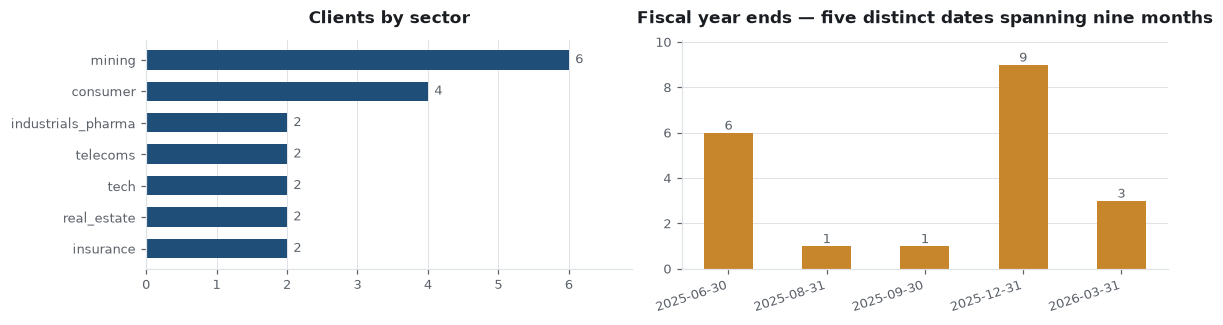

In [11]:
ROSTER = CON.execute(f"""
    SELECT e.entity_id, e.entity_name, f.sector, e.reporting_currency,
           e.fy_label, e.fiscal_year_end::VARCHAR AS fiscal_year_end
    FROM read_csv_auto('{paths.FINANCES_DIR}/entities.csv', header = true, nullstr = '') e
    JOIN (SELECT DISTINCT entity_id, sector
          FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')) f
      USING (entity_id)
    ORDER BY e.entity_id
""").df()
table(ROSTER, "The 20-client portfolio")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.1))
sectors = ROSTER["sector"].value_counts().sort_values()
axes[0].barh(sectors.index, sectors.values, color=PILLAR_COLOUR["cash_management"], height=0.62)
for y, v in enumerate(sectors.values):
    axes[0].text(v + 0.09, y, str(v), va="center", fontsize=8.5, color=MUTED)
axes[0].set_xlim(0, sectors.max() + 0.9)
axes[0].set_title("Clients by sector")
axis_style(axes[0], xgrid=True, ygrid=False)

fye = ROSTER["fiscal_year_end"].value_counts().sort_index()
axes[1].bar(range(len(fye)), fye.values, color=PILLAR_COLOUR["trade_finance"], width=0.5)
axes[1].set_xticks(range(len(fye)))
axes[1].set_xticklabels(fye.index, rotation=18, ha="right")
for x, v in enumerate(fye.values):
    axes[1].text(x, v + 0.13, str(v), ha="center", fontsize=8.5, color=MUTED)
axes[1].set_ylim(0, fye.max() + 1.1)
axes[1].set_title("Fiscal year ends — five distinct dates spanning nine months")
axis_style(axes[1])
plt.tight_layout(); plt.show()

## 2.5 Data-quality observations that change the model

The full derivation is in `AUDIT_REPORT.md`. These are the findings that actually alter a
modelling decision. Each is carried through the engine as a **flag rather than a correction**:
a value we cannot verify is not a value we are entitled to overwrite.

In [12]:
OBSERVATIONS = pd.DataFrame([
    ("Revenue-split identity fails for 3 clients",
     "E08 Sanlam (revenue_total exceeds SA + foreign by R102.9bn, basis=constructed), "
     "E18 Bidvest (+R409m), E06 Valterra (−R68m)",
     "Geographic splits on these legs do not reconcile. Carried as an internal_consistency "
     "penalty in the confidence score and as a diagnostic — never corrected."),
    ("Five unverifiable zeros in debt / FX-notional fields",
     "E05 fx_forward_notional; E06 debt_noncurrent; E07 gross_debt, debt_current, "
     "debt_noncurrent",
     "All carry status = OK, so they read as facts. A false zero on gross_debt suppresses a "
     "lending signal entirely. E06 and E07 zero-debt claims are treated as provisional."),
    ("Four clients disclose no cost of sales",
     "Their supplier-payment and import components rest on a sector-median ratio applied to "
     "revenue",
     "driver_source = 'portfolio_benchmark' is recorded per component and cuts "
     "input_completeness, so the confidence score shows it rather than hiding it."),
    ("Fiscal year ends span nine months across five dates",
     "2025-06-30 (6 entities), 2025-08-31 (1), 2025-09-30 (1), 2025-12-31 (9), 2026-03-31 (3)",
     "There is no single portfolio fiscal year. Every client is aligned to its OWN 12-month "
     "window inside the 36-month flow data (§3.3)."),
    ("Status vocabulary has drifted",
     "NOT_EXTRACTED and BLOCKED_NO_FYE sit outside the original closed set",
     "Validators accept the union rather than failing on a legitimate new reason code."),
    ("total_assets / equity / total_liabilities do not exist in the data at all",
     "No balance-sheet identity can be checked for any entity",
     "The gross-debt identity passes 20/20; net debt has no field to check against."),
], columns=["Finding", "Detail", "How the model handles it"])
table(OBSERVATIONS)

Finding,Detail,How the model handles it
Revenue-split identity fails for 3 clients,"E08 Sanlam (revenue_total exceeds SA + foreign by R102.9bn, basis=constructed), E18 Bidvest (+R409m), E06 Valterra (−R68m)",Geographic splits on these legs do not reconcile. Carried as an internal_consistency penalty in the confidence score and as a diagnostic — never corrected.
Five unverifiable zeros in debt / FX-notional fields,"E05 fx_forward_notional; E06 debt_noncurrent; E07 gross_debt, debt_current, debt_noncurrent","All carry status = OK, so they read as facts. A false zero on gross_debt suppresses a lending signal entirely. E06 and E07 zero-debt claims are treated as provisional."
Four clients disclose no cost of sales,Their supplier-payment and import components rest on a sector-median ratio applied to revenue,"driver_source = 'portfolio_benchmark' is recorded per component and cuts input_completeness, so the confidence score shows it rather than hiding it."
Fiscal year ends span nine months across five dates,"2025-06-30 (6 entities), 2025-08-31 (1), 2025-09-30 (1), 2025-12-31 (9), 2026-03-31 (3)",There is no single portfolio fiscal year. Every client is aligned to its OWN 12-month window inside the 36-month flow data (§3.3).
Status vocabulary has drifted,NOT_EXTRACTED and BLOCKED_NO_FYE sit outside the original closed set,Validators accept the union rather than failing on a legitimate new reason code.
total_assets / equity / total_liabilities do not exist in the data at all,No balance-sheet identity can be checked for any entity,The gross-debt identity passes 20/20; net debt has no field to check against.


### Three apparent signals that are generation artefacts — do not model them

Measured below, not assumed. Each one, modelled, produces a confident finding about nothing.

In [13]:
DOW = CON.execute(f"""
    SELECT dayname(date) AS day, COUNT(*) AS rows
    FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')
    GROUP BY 1 ORDER BY MIN(dayofweek(date))
""").df()

CHANNEL = CON.execute(f"""
    WITH mix AS (
        SELECT entity_id, channel,
               COUNT(*)::DOUBLE / SUM(COUNT(*)) OVER (PARTITION BY entity_id) AS share
        FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')
        GROUP BY 1, 2)
    SELECT channel, MIN(share) AS min_client_share, MAX(share) AS max_client_share,
           MAX(share) - MIN(share) AS spread
    FROM mix GROUP BY 1 ORDER BY max_client_share DESC
""").df()

print(f"1. Day-of-week distribution is flat — max ÷ min = "
      f"{DOW['rows'].max() / DOW['rows'].min():.3f}. No weekday/weekend structure, no "
      "month-end spike, no payment-cycle rhythm. Any 'cash cycle timing' finding built on "
      "day-of-week is an artefact.\n")
print(f"2. Channel mix is near-identical across all 20 clients — the widest client-to-client "
      f"spread on any channel is {CHANNEL['spread'].max() * 100:.1f} percentage points. "
      "Channel preference carries no client-level signal.\n")
table(CHANNEL, "Channel mix — the range across the 20 clients",
      percent=["min_client_share", "max_client_share", "spread"])
print("\n3. commodity_or_contract_type in trade finance is drawn independently of sector — "
      "mining clients show more 'consumer_goods' and 'pharmaceuticals' instructions than "
      "'gold'. Do not infer supply-chain or commodity exposure from it.")

1. Day-of-week distribution is flat — max ÷ min = 1.011. No weekday/weekend structure, no month-end spike, no payment-cycle rhythm. Any 'cash cycle timing' finding built on day-of-week is an artefact.

2. Channel mix is near-identical across all 20 clients — the widest client-to-client spread on any channel is 3.6 percentage points. Channel preference carries no client-level signal.



**Channel mix — the range across the 20 clients**

channel,min_client_share,max_client_share,spread
EFT,43.44%,45.34%,1.90%
RTC,19.44%,20.56%,1.12%
Internal Transfer,14.39%,18.01%,3.62%
Debit Order,7.05%,10.53%,3.48%
SWIFT,9.63%,10.35%,0.72%



3. commodity_or_contract_type in trade finance is drawn independently of sector — mining clients show more 'consumer_goods' and 'pharmaceuticals' instructions than 'gold'. Do not infer supply-chain or commodity exposure from it.


### The one field everybody dismisses, which is the point of the dataset

`memo` is null on 99.87% of transactional rows, which reads as a broken column. The populated
rows are **planted competitor-lending evidence**: every one describes a facility drawdown,
bridging facility, loan drawdown or syndicate participation settling through a Syn Bank
account — on credit Syn Bank is not the lender for. This is the only *observed* competitor
signal in the data, and it feeds the lending narrative in §10.

In [14]:
MEMO = CON.execute(f"""
    WITH m AS (
      SELECT memo FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')
        WHERE memo IS NOT NULL
      UNION ALL
      SELECT memo FROM read_parquet('{paths.PROCESSED_DIR}/cross_border_payments.parquet')
        WHERE memo IS NOT NULL
      UNION ALL
      SELECT memo FROM read_parquet('{paths.PROCESSED_DIR}/trade_finance.parquet')
        WHERE memo IS NOT NULL)
    SELECT regexp_replace(memo, '[0-9]+$', '<n>') AS phrase_template, COUNT(*) AS rows
    FROM m GROUP BY 1 ORDER BY rows DESC
""").df()
table(MEMO, "Every populated memo across all three datasets reduces to four phrase templates",
      counts=["rows"])

TOP_MEMO = (FEATURES[["entity_id", "entity_name", "txn_memo_count_36m"]]
            .sort_values("txn_memo_count_36m", ascending=False).head(6)
            .rename(columns={"txn_memo_count_36m": "memos (36m)"}))
table(TOP_MEMO, "Highest competitor-lending memo intensity", counts=["memos (36m)"])
print("Clients with zero memos — a signal in its own right, in either direction: "
      + ", ".join(sorted(FEATURES.loc[FEATURES["txn_memo_count_36m"] == 0, "entity_name"])))

**Every populated memo across all three datasets reduces to four phrase templates**

phrase_template,rows
Settlement re: facility drawdown - ref,"1,079"
Bridging facility settlement - ref,"1,078"
Syndicate participation settlement - ref,"1,032"
Loan drawdown proceeds - ext. ref,995


**Highest competitor-lending memo intensity**

entity_id,entity_name,memos (36m)
E10,Bid Corporation,809
E09,Shoprite Holdings,727
E16,MTN Group,721
E19,Aspen Pharmacare,364
E18,The Bidvest Group,361
E14,Prosus,180


Clients with zero memos — a signal in its own right, in either direction: Anglo American, BHP Group, Pepkor Holdings, Sanlam


---

# 3. Data pipeline

```
data/*.csv  (3 raw inputs, gitignored, restorable from data/data.tgz)
  └─► clean_data.py ───────────► data/processed/*.parquet + quality_report.json
data/finances/*.csv  (9 files)
  └─► build_features.py ───────► client_features.parquet (20 × 289) + client_master
        │                         entity mapping · fiscal-year alignment · ZAR conversion
        └─► build_wallet.py ───► opportunity_engine.parquet          ◄── THE CONTRACT
              │                   client_opportunity_profile.parquet ◄── THE CONTRACT
              │                   + 12 supporting tables + a 36-run sensitivity sweep
              └─► build_intelligence.py ──► client_opportunity_intelligence
                    │                        banker_questions · opportunity_explanations
                    └─► copilot/ ──► router → retrieval → context → LLM → validation → audit
                          └─► api/ + dashboard/   (service layer projects; browser never computes)
```

Every stage is a module in `src/syn_wallet/`, run by the bootstrap cell at the top of this
notebook. What follows inspects what those modules produced — **no stage is re-implemented
here**.

## 3.1 Cleaning — what stage 1 removed, and what it refused to remove

In [15]:
QUALITY = report("quality_report")
rows = []
for name, block in QUALITY["datasets"].items():
    rows.append({
        "dataset": name,
        "source rows": block["source_rows"],
        "clean rows": block["clean_rows"],
        "exact duplicates removed": block["canonical_exact_duplicate_rows_removed"],
        "ID-conflict groups retained": block["identifier_conflict_groups_retained"],
        "conflict-flagged rows": block["identifier_conflict_rows_retained"],
    })
table(pd.DataFrame(rows), "Stage 1 — cleaning",
      counts=["source rows", "clean rows", "exact duplicates removed",
              "ID-conflict groups retained", "conflict-flagged rows"])

**Stage 1 — cleaning**

dataset,source rows,clean rows,exact duplicates removed,ID-conflict groups retained,conflict-flagged rows
transactional_banking,"2,802,875","2,791,803","11,072","42,289","85,010"
cross_border_payments,"241,117","240,191",926,297,594
trade_finance,"20,303","20,215",88,3,6


> **Exact duplicates are removed; conflicting records are preserved and flagged.** An
> identifier reused with a *different* payload is a data-quality fact about the source system,
> not a row to silently pick a winner for. The transactional conflict groups are retained with
> `has_identifier_conflict = true` on 85,010 rows, so any downstream analysis can exclude them
> explicitly and say that it did.
>
> **Ordering matters and must not be changed.** `UPPER(currency)` is applied when the
> canonical relation is built, *before* the `ROW_NUMBER()` de-duplication runs. Normalising
> first catches 260 additional true duplicates worth R35.3m that a case-sensitive de-dup
> leaves in.

## 3.2 Entity mapping

`entities.csv` is authoritative for reporting currency and fiscal year end; `sector` exists
only on the flow datasets, where it is identical across all three. The production join is
`sources.entity_dimension_sql()` — the notebook calls it rather than restating it.

In [16]:
CONNECTION = sources.connect()          # every analytical input registered as a DuckDB view
CONNECTION.execute(f"CREATE OR REPLACE TABLE entity_dim AS {sources.entity_dimension_sql()}")

MAPPING = CONNECTION.execute("""
    SELECT COUNT(*) AS entities,
           SUM(CASE WHEN distinct_sectors > 1 THEN 1 ELSE 0 END) AS sector_conflicts,
           SUM(CASE WHEN distinct_names   > 1 THEN 1 ELSE 0 END) AS name_conflicts,
           SUM(CASE WHEN fiscal_year_end IS NULL THEN 1 ELSE 0 END) AS missing_fiscal_year_end,
           SUM(CASE WHEN fy_start < flow_window_start OR fiscal_year_end > flow_window_end
                    THEN 1 ELSE 0 END) AS fy_outside_flow_window
    FROM entity_dim
""").df()
table(MAPPING, "Entity mapping integrity — every count except `entities` must be zero",
      counts=list(MAPPING.columns))

**Entity mapping integrity — every count except `entities` must be zero**

entities,sector_conflicts,name_conflicts,missing_fiscal_year_end,fy_outside_flow_window
20,0,0,0,0


## 3.3 Fiscal-period alignment

Each client is aligned to **its own** twelve-month window,
`[fiscal_year_end − 1 year + 1 day, fiscal_year_end]`.

This is the decision the data forces. Five distinct year ends spanning nine months means
there is no single portfolio "fiscal year", and aligning everyone to one calendar window
would measure a different twelve months of trading against each client's published accounts —
putting a denominator from one period opposite a numerator from another. Cross-client rand
comparisons therefore carry the caveat that the twelve months are not the same twelve months.

Every window falls inside the 36-month internal flow window, so no client is period-aligned
against partial internal data — verified as `fy_outside_flow_window = 0` above.

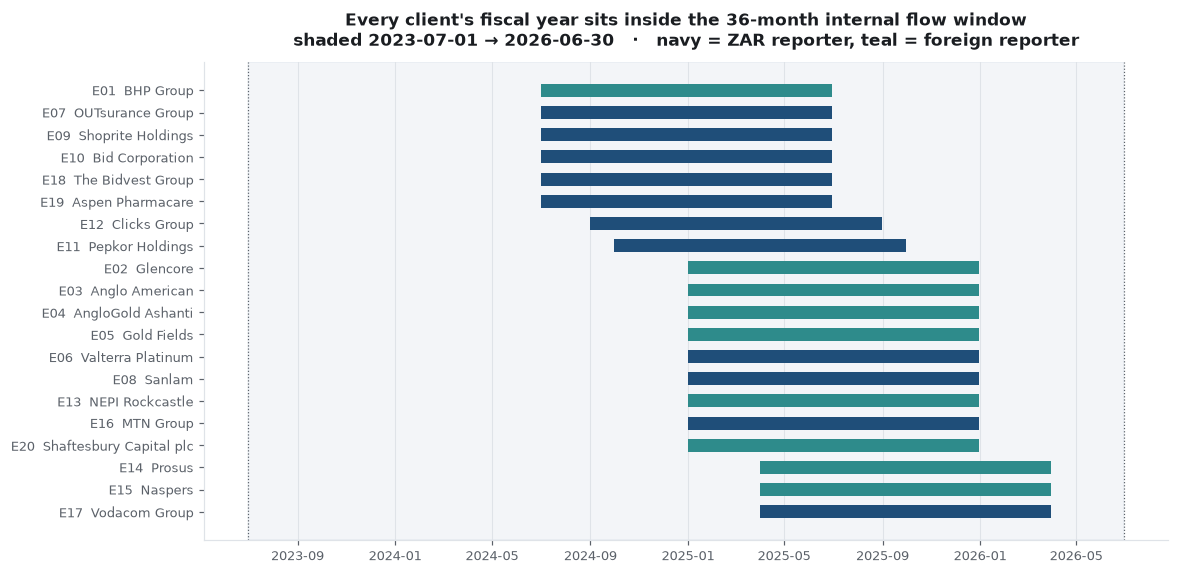

In [17]:
ALIGN = CONNECTION.execute("""
    SELECT entity_id, entity_name, fy_label, fy_start, fiscal_year_end AS fy_end,
           reporting_currency
    FROM entity_dim ORDER BY fiscal_year_end DESC, entity_id DESC
""").df()

fig, ax = plt.subplots(figsize=(11, 5.4))
starts = pd.to_datetime(ALIGN["fy_start"]); ends = pd.to_datetime(ALIGN["fy_end"])
labels = ALIGN["entity_id"] + "  " + ALIGN["entity_name"]
ax.barh(labels, (ends - starts).dt.days, left=starts, height=0.58,
        color=[PILLAR_COLOUR["cash_management"] if c == "ZAR"
               else PILLAR_COLOUR["fx_global_markets"]
               for c in ALIGN["reporting_currency"]])
ax.axvspan(pd.Timestamp(paths.FLOW_WINDOW_START), pd.Timestamp(paths.FLOW_WINDOW_END),
           color=PILLAR_COLOUR["cash_management"], alpha=0.05, zorder=0)
for edge in (paths.FLOW_WINDOW_START, paths.FLOW_WINDOW_END):
    ax.axvline(pd.Timestamp(edge), color=MUTED, lw=0.8, ls=":")
ax.set_title("Every client's fiscal year sits inside the 36-month internal flow window\n"
             "shaded 2023-07-01 → 2026-06-30   ·   navy = ZAR reporter, teal = foreign reporter")
axis_style(ax, xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

## 3.4 Feature construction

Stage 2 produces `client_features.parquet` — 20 rows × 289 columns. Internal activity is
aggregated over four windows: the full 36-month window, **each client's own fiscal year**
(the scope every wallet estimate uses), and trailing 12-month pairs for year-on-year trend.

In [18]:
groups = {}
for column in FEATURES.columns:
    if column.startswith("txn_"):
        groups.setdefault("internal · transactional", []).append(column)
    elif column.startswith("xb_"):
        groups.setdefault("internal · cross-border", []).append(column)
    elif column.startswith("tf_"):
        groups.setdefault("internal · trade finance", []).append(column)
    elif column.endswith(("_native", "_zar")) or column in {
            "employees", "lenders_named", "named_lender_count", "working_capital_zar"}:
        groups.setdefault("external · financial", []).append(column)
    elif column.startswith("fx_"):
        groups.setdefault("fx conversion", []).append(column)
    else:
        groups.setdefault("identity, period & derived ratios", []).append(column)

table(pd.DataFrame([{"feature group": name, "columns": len(cols),
                     "examples": ", ".join(cols[:4]) + " …"} for name, cols in groups.items()]),
      f"client_features.parquet — {FEATURES.shape[1]} columns across {len(groups)} groups",
      counts=["columns"])

FEATURE_REPORT = report("feature_report")
validation = FEATURE_REPORT["validation"]
print(f"Feature-layer validation: {validation['checks_run']} checks run, "
      f"{validation['failures']} failures, passed = {validation['passed']}")
print("FX crosscheck:", json.dumps(FEATURE_REPORT["fx_crosscheck"]))

**client_features.parquet — 289 columns across 6 groups**

feature group,columns,examples
"identity, period & derived ratios",38,"entity_id, entity_name, sector, fy_label …"
fx conversion,4,"fx_avg_rate_zar_per_unit, fx_closing_rate_zar_per_unit, fx_conversion_basis, fx_observation_count …"
external · financial,40,"revenue_total_native, revenue_total_zar, revenue_south_africa_native, revenue_south_africa_zar …"
internal · transactional,69,"txn_total_volume_zar_36m, txn_inbound_volume_zar_36m, txn_outbound_volume_zar_36m, txn_collections_volume_zar_36m …"
internal · cross-border,62,"xb_total_volume_zar_36m, xb_inbound_volume_zar_36m, xb_outbound_volume_zar_36m, xb_trade_corridor_volume_zar_36m …"
internal · trade finance,76,"tf_total_value_zar_36m, tf_letters_of_credit_value_zar_36m, tf_letters_of_credit_count_36m, tf_guarantees_value_zar_36m …"


Feature-layer validation: 49 checks run, 0 failures, passed = True
FX crosscheck: {"fy_window_rows_compared": 51, "fy_window_max_abs_diff": 4.45783132647648e-05, "self_reported_rows_compared": 20, "self_reported_max_abs_pct_diff": 0.8560876029547078}


---

# 4. FX conversion

**Never compute a ratio with a ZAR numerator and a non-ZAR denominator.** Internal flow values
are all ZAR; external financials are stored raw in the entity's own reporting currency.
Dividing one by the other unconverted understates the nine foreign reporters' wallets by
roughly 17–24× and makes them look like the bank's best-penetrated accounts.

## 4.1 The policy, declared in code

| Item class | Rate | Why |
|---|---|---|
| **Income statement / cash flow** — revenue, cost of sales, finance costs, capex | fiscal-year **average** | A flow accrues across the year, so the average is the only unbiased translation of it |
| **Balance sheet / facility register** — inventory, receivables, payables, debt, cash, facilities, FX notional | fiscal-year-end **closing** | A stock exists at one instant, the reporting date, so it translates at the rate on that date |
| Non-monetary — employees, note page, lenders named | never converted | Not a monetary amount |

Mixing the two is the classic translation error. The policy is a dictionary in
`src/syn_wallet/config.py`, so it cannot drift out of the documentation.

In [19]:
POLICY = pd.DataFrame([(field, basis.value) for field, basis in paths.FX_BASIS_BY_FIELD.items()],
                      columns=["external field", "conversion basis"])
POLICY["item class"] = POLICY["conversion basis"].map({
    "fy_average": "income statement / cash flow  (flow)",
    "fy_closing": "balance sheet / facilities  (stock)",
    "not_monetary": "not a monetary amount"})
table(POLICY, "src/syn_wallet/config.py :: FX_BASIS_BY_FIELD — the policy *is* the code")

**src/syn_wallet/config.py :: FX_BASIS_BY_FIELD — the policy *is* the code**

external field,conversion basis,item class
revenue_total,fy_average,income statement / cash flow (flow)
revenue_south_africa,fy_average,income statement / cash flow (flow)
revenue_foreign,fy_average,income statement / cash flow (flow)
cost_of_sales,fy_average,income statement / cash flow (flow)
finance_costs,fy_average,income statement / cash flow (flow)
capex,fy_average,income statement / cash flow (flow)
inventory,fy_closing,balance sheet / facilities (stock)
trade_receivables,fy_closing,balance sheet / facilities (stock)
trade_payables,fy_closing,balance sheet / facilities (stock)
gross_debt,fy_closing,balance sheet / facilities (stock)


## 4.2 The rates are deterministic, and derived from one source

`src/syn_wallet/fx.py` averages the SARB daily mid-rate series over **each entity's own**
fiscal-year window. Every entity gets its rate from the same method — no per-entity source
switching — and the two prepared rate files are used only as cross-checks.

The check against `fx_rates_fy_window.csv` is a **reproduction** check, not a reconciliation
tolerance: it uses the same method, so it must give the same answer. The check against each
client's self-reported rates is a genuine agreement test, and the tolerance is stated.

> `fx_rates_fy_window.csv` is stale: its nine `BLOCKED_NO_FYE` rows for E11, E12 and E13 wait
> on fiscal year ends that `entities.csv` now supplies. Deriving from the daily series fills
> those gaps and reproduces every one of its 51 `OK` rows exactly, which is why the engine
> derives rather than reads.

In [20]:
CROSSCHECK = fx_module.build(CONNECTION)     # the production function, on live inputs

ENTITY_FX = CONNECTION.execute("""
    SELECT entity_id, entity_name, reporting_currency, fy_label,
           fx_avg_rate_zar_per_unit AS avg_rate,
           fx_closing_rate_zar_per_unit AS closing_rate,
           fx_conversion_basis, fx_observation_count AS daily_observations
    FROM entity_fx WHERE reporting_currency <> 'ZAR' ORDER BY entity_id
""").df()
table(ENTITY_FX, "Derived fiscal-year rates for the nine foreign reporters",
      decimals=["avg_rate", "closing_rate"], counts=["daily_observations"])

print(f"Reproduces {CROSSCHECK.fy_window_rows_compared} rows of the prepared "
      f"fx_rates_fy_window.csv to within {CROSSCHECK.fy_window_max_abs_diff:.2e} ZAR "
      f"(tolerance {fx_module.FY_WINDOW_TOLERANCE:.0e})")
print(f"Agrees with {CROSSCHECK.self_reported_rows_compared} client-published rates to within "
      f"{CROSSCHECK.self_reported_max_abs_pct_diff:.2f}% "
      f"(tolerance {fx_module.SELF_REPORTED_TOLERANCE_PCT:.1f}%)")
print("\nZAR reporters convert at exactly 1.0 with basis 'no_conversion'. No FX rate is "
      "applied to them, and no internal ZAR flow value is ever re-denominated.")

**Derived fiscal-year rates for the nine foreign reporters**

entity_id,entity_name,reporting_currency,fy_label,avg_rate,closing_rate,fx_conversion_basis,daily_observations
E01,BHP Group,USD,FY2025,18.157,17.776,sarb_daily_fy_window,249
E02,Glencore,USD,FY2025,17.883,16.598,sarb_daily_fy_window,250
E03,Anglo American,USD,FY2025,17.883,16.598,sarb_daily_fy_window,250
E04,AngloGold Ashanti,USD,FY2025,17.883,16.598,sarb_daily_fy_window,250
E05,Gold Fields,USD,FY2025,17.883,16.598,sarb_daily_fy_window,250
E13,NEPI Rockcastle,EUR,FY2025,20.181,19.469,sarb_daily_fy_window,250
E14,Prosus,USD,FY2026,17.343,17.094,sarb_daily_fy_window,251
E15,Naspers,USD,FY2026,17.343,17.094,sarb_daily_fy_window,251
E20,Shaftesbury Capital plc,GBP,FY2025,23.557,22.316,sarb_daily_fy_window,250


Reproduces 51 rows of the prepared fx_rates_fy_window.csv to within 4.46e-05 ZAR (tolerance 5e-04)
Agrees with 20 client-published rates to within 0.86% (tolerance 1.5%)

ZAR reporters convert at exactly 1.0 with basis 'no_conversion'. No FX rate is applied to them, and no internal ZAR flow value is ever re-denominated.


## 4.3 One worked conversion

BHP Group (`E01`) reports in USD with a 30 June 2025 year end. Its revenue is a flow and
converts at the fiscal-year average; its gross debt is a stock and converts at the closing
rate. Both are recomputed in this cell from the published rate and **asserted** against the
value the feature layer actually stored.

In [21]:
example = FEATURES[FEATURES["entity_id"] == "E01"].iloc[0]
avg_rate = float(example["fx_avg_rate_zar_per_unit"])
closing_rate = float(example["fx_closing_rate_zar_per_unit"])

display(Markdown(
    f"**{example['entity_name']}** ({example['entity_id']}) · reports in "
    f"**{example['reporting_currency']}** · {example['fy_label']} · year end "
    f"{pd.Timestamp(example['fiscal_year_end']).date()}<br>"
    f"fiscal-year average **{avg_rate:.4f}** ZAR/USD &nbsp;·&nbsp; "
    f"closing **{closing_rate:.4f}** ZAR/USD &nbsp;·&nbsp; "
    f"{int(example['fx_observation_count'])} daily observations"))

WORKED = pd.DataFrame([
    ("revenue_total", "flow", "fy average", example["revenue_total_native"], avg_rate),
    ("capex", "flow", "fy average", example["capex_native"], avg_rate),
    ("inventory", "stock", "fy closing", example["inventory_native"], closing_rate),
    ("gross_debt", "stock", "fy closing", example["gross_debt_native"], closing_rate),
    ("undrawn_facilities", "stock", "fy closing", example["undrawn_facilities_native"],
     closing_rate),
], columns=["external field", "item class", "rate used", "native (USD)", "rate"])
WORKED["recomputed in this cell"] = WORKED["native (USD)"] * WORKED["rate"]
WORKED["stored by the feature layer"] = [
    example[f"{field}_zar"] for field in WORKED["external field"]]

for row in WORKED.itertuples(index=False):
    assert abs(row[5] - row[6]) < 1.0, f"{row[0]}: notebook and feature layer disagree"

WORKED["native (USD)"] = WORKED["native (USD)"].map(lambda v: f"{v:,.0f}")
table(WORKED, "Worked conversion — recomputed here, asserted against the stored feature layer",
      money=["recomputed in this cell", "stored by the feature layer"], decimals=["rate"])
print("✓ assertion passed — every recomputed value matches the stored value to within R1")
print(f"\ncost_of_sales is absent for {example['entity_name']} — native "
      f"{example['cost_of_sales_native']}, ZAR {example['cost_of_sales_zar']}. It stays NULL "
      "through the FX layer and is imputed later, visibly, by the wallet engine (§7).")

**BHP Group** (E01) · reports in **USD** · FY2025 · year end 2025-06-30<br>fiscal-year average **18.1569** ZAR/USD &nbsp;·&nbsp; closing **17.7758** ZAR/USD &nbsp;·&nbsp; 249 daily observations

**Worked conversion — recomputed here, asserted against the stored feature layer**

external field,item class,rate used,native (USD),rate,recomputed in this cell,stored by the feature layer
revenue_total,flow,fy average,"51,262,000,000",18.157,R930.76bn,R930.76bn
capex,flow,fy average,"9,794,000,000",18.157,R177.83bn,R177.83bn
inventory,stock,fy closing,"6,978,000,000",17.776,R124.04bn,R124.04bn
gross_debt,stock,fy closing,"24,496,000,000",17.776,R435.44bn,R435.44bn
undrawn_facilities,stock,fy closing,"5,500,000,000",17.776,R97.77bn,R97.77bn


✓ assertion passed — every recomputed value matches the stored value to within R1

cost_of_sales is absent for BHP Group — native nan, ZAR nan. It stays NULL through the FX layer and is imputed later, visibly, by the wallet engine (§7).


---

# 5. Internal activity features

What Syn Bank **observes**. Everything in this section is measured, not estimated — it is the
numerator of every share of wallet that follows. All figures are on each client's own fiscal
year (`_fy` suffix), the scope the wallet engine uses.

## 5.1 Cash — the five transactional legs

Two legs are *in scope* for the cash wallet: **collections** and **supplier payments**, because
they have an accounting-identity denominator (revenue and cost of sales). Three legs —
**payroll**, **tax** and **intercompany sweeps** — are excluded from *both* sides and carried
separately, because no external field sizes them and putting an invented denominator opposite
a token numerator would manufacture a fake gap.

SWIFT-channel volume is excluded from the cash numerator **and not added to FX**, so no rand
is counted twice in either direction.

In [22]:
CASH_LEGS = FEATURES[[
    "entity_id", "entity_name",
    "txn_collections_domestic_volume_zar_fy", "txn_collections_count_fy",
    "txn_supplier_payments_domestic_volume_zar_fy", "txn_supplier_payments_count_fy",
    "txn_payroll_volume_zar_fy", "txn_payroll_count_fy",
    "txn_tax_volume_zar_fy", "txn_tax_count_fy",
    "txn_intercompany_sweeps_volume_zar_fy", "txn_intercompany_sweeps_count_fy",
    "txn_swift_channel_volume_zar_fy", "txn_transaction_count_fy", "txn_active_days_fy",
]].copy()
CASH_LEGS.columns = [
    "id", "client", "collections (dom.)", "collections n", "supplier pmts (dom.)",
    "supplier n", "payroll", "payroll n", "tax", "tax n", "intercompany", "intercompany n",
    "SWIFT excluded", "transactions", "active days"]
table(CASH_LEGS.sort_values("collections (dom.)", ascending=False),
      "Observed transactional activity, each client's own fiscal year",
      money=["collections (dom.)", "supplier pmts (dom.)", "payroll", "tax", "intercompany",
             "SWIFT excluded"],
      counts=["collections n", "supplier n", "payroll n", "tax n", "intercompany n",
              "transactions", "active days"])

**Observed transactional activity, each client's own fiscal year**

id,client,collections (dom.),collections n,supplier pmts (dom.),supplier n,payroll,payroll n,tax,tax n,intercompany,intercompany n,SWIFT excluded,transactions,active days
E11,Pepkor Holdings,R8.65bn,"126,852",R5.62bn,"108,383",R10.9m,"1,160",R27.3m,353,R18.39bn,"72,376",R3.36bn,"309,124",365
E01,BHP Group,R7.90bn,"16,339",R1.42bn,"14,158",R2.9m,160,R8.3m,54,R4.78bn,"9,575",R1.52bn,"40,286",365
E08,Sanlam,R5.54bn,"74,447",R3.58bn,"63,350",R8.4m,818,R19.8m,248,R11.96bn,"42,217",R2.32bn,"181,080",365
E03,Anglo American,R4.04bn,"11,557",R775.7m,"9,987",R1.8m,122,R4.5m,40,R2.35bn,"6,639",R703.6m,"28,345",365
E10,Bid Corporation,R2.57bn,"29,120",R1.68bn,"24,932",R8.3m,702,R22.1m,222,R6.44bn,"19,085",R1.17bn,"74,061",365
E16,MTN Group,R2.39bn,"27,571",R1.57bn,"23,564",R8.1m,683,R22.1m,193,R5.93bn,"17,938",R1.01bn,"69,949",365
E09,Shoprite Holdings,R2.37bn,"26,548",R1.58bn,"22,721",R8.5m,687,R17.1m,178,R5.86bn,"17,202",R1.06bn,"67,336",365
E02,Glencore,R2.14bn,"2,741",R365.3m,"2,330",R1.8m,64,R5.6m,20,R1.49bn,"1,809",R447.4m,"6,964",365
E18,The Bidvest Group,R1.01bn,"13,593",R659.5m,"11,923",R3.5m,353,R9.4m,103,R2.49bn,"8,911",R408.9m,"34,883",365
E04,AngloGold Ashanti,R855.0m,"3,017",R170.1m,"2,685",R1.0m,89,R1.9m,25,R633.3m,"2,058",R187.3m,"7,874",365


### Payroll row count is the sharpest engagement signal in the dataset

Payroll is the stickiest transactional-banking product. A client running payroll elsewhere is
a client whose primary banking relationship sits with a competitor. The contrast is not
subtle, and it is not explained by client size — it is specific to domestic transactional
banking.

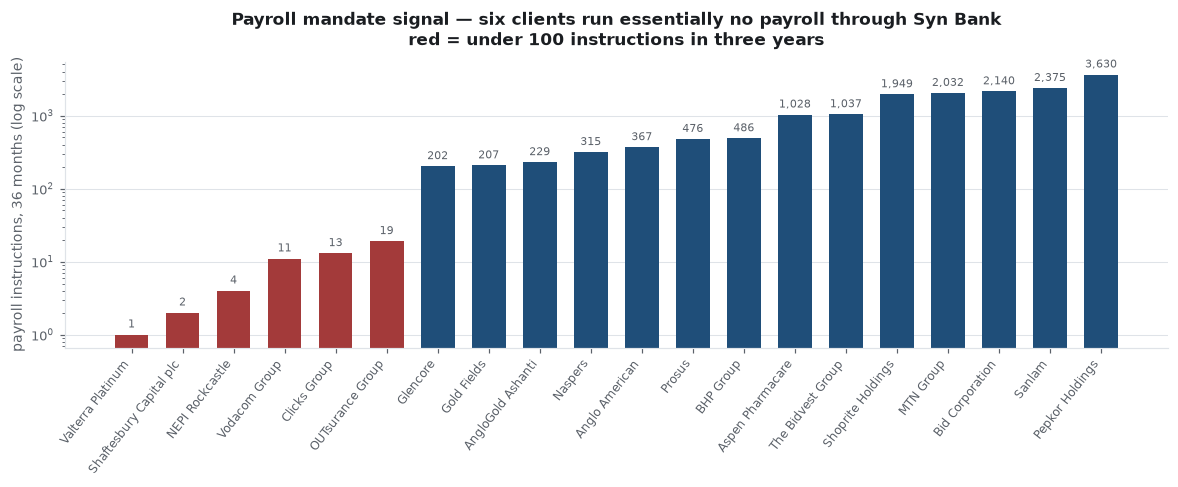

**The sector-peer contrast is the strongest single fact in the dataset.** MTN Group ran **2,032** payroll instructions (R24.6m) against Vodacom Group's **11** (R101.1k) — 184.7× on count. MTN's domestic non-SWIFT flow is R28.37bn against Vodacom's R676.5m (41.9×), yet Vodacom's cross-border flow is 46.6% of MTN's. The gap is specific to domestic transactional banking, not to client size.

In [23]:
PAYROLL = (FEATURES[["entity_id", "entity_name", "sector", "txn_payroll_count_36m",
                     "txn_payroll_volume_zar_36m", "txn_domestic_volume_zar_36m",
                     "xb_total_volume_zar_36m"]]
           .sort_values("txn_payroll_count_36m").reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 4.6))
order = PAYROLL.sort_values("txn_payroll_count_36m")
bars = ax.bar(range(len(order)), order["txn_payroll_count_36m"].clip(lower=0.7),
              color=[PILLAR_COLOUR["cash_management"] if v >= 100 else "#a33a3a"
                     for v in order["txn_payroll_count_36m"]], width=0.66)
ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order["entity_name"], rotation=52, ha="right", fontsize=8)
ax.set_ylabel("payroll instructions, 36 months (log scale)")
ax.set_title("Payroll mandate signal — six clients run essentially no payroll through Syn Bank\n"
             "red = under 100 instructions in three years")
for x, v in enumerate(order["txn_payroll_count_36m"]):
    ax.text(x, max(v, 0.7) * 1.25, f"{int(v):,}", ha="center", fontsize=7.5, color=MUTED)
axis_style(ax)
plt.tight_layout(); plt.show()

peers = PAYROLL[PAYROLL["entity_name"].isin(["MTN Group", "Vodacom Group"])].set_index("entity_name")
mtn, voda = peers.loc["MTN Group"], peers.loc["Vodacom Group"]
display(Markdown(
    f"**The sector-peer contrast is the strongest single fact in the dataset.** "
    f"MTN Group ran **{int(mtn['txn_payroll_count_36m']):,}** payroll instructions "
    f"({zar(mtn['txn_payroll_volume_zar_36m'])}) against Vodacom Group's "
    f"**{int(voda['txn_payroll_count_36m']):,}** ({zar(voda['txn_payroll_volume_zar_36m'])}) — "
    f"{mtn['txn_payroll_count_36m'] / max(voda['txn_payroll_count_36m'], 1):.1f}× on count. "
    f"MTN's domestic non-SWIFT flow is {zar(mtn['txn_domestic_volume_zar_36m'])} against "
    f"Vodacom's {zar(voda['txn_domestic_volume_zar_36m'])} "
    f"({mtn['txn_domestic_volume_zar_36m'] / voda['txn_domestic_volume_zar_36m']:.1f}×), yet "
    f"Vodacom's cross-border flow is "
    f"{voda['xb_total_volume_zar_36m'] / mtn['xb_total_volume_zar_36m'] * 100:.1f}% of MTN's. "
    "The gap is specific to domestic transactional banking, not to client size."))

## 5.2 FX — cross-border volume, currencies, countries, corridors

In [24]:
FX_FEAT = FEATURES[[
    "entity_id", "entity_name", "xb_total_volume_zar_fy", "xb_inbound_volume_zar_fy",
    "xb_outbound_volume_zar_fy", "xb_transaction_count_fy", "xb_active_countries_fy",
    "xb_active_currency_pairs_fy", "xb_trade_corridor_volume_zar_fy",
    "xb_intercompany_corridor_volume_zar_fy", "xb_other_corridor_volume_zar_fy",
    "xb_top_country_fy", "xb_country_hhi_fy",
]].copy()
FX_FEAT.columns = ["id", "client", "total", "inbound", "outbound", "payments", "countries",
                   "ccy pairs", "trade corridor", "intercompany corridor", "other corridor",
                   "top country", "country HHI"]
table(FX_FEAT.sort_values("total", ascending=False),
      "Observed cross-border activity, each client's own fiscal year",
      money=["total", "inbound", "outbound", "trade corridor", "intercompany corridor",
             "other corridor"],
      counts=["payments", "countries", "ccy pairs"], decimals=["country HHI"])

**Observed cross-border activity, each client's own fiscal year**

id,client,total,inbound,outbound,payments,countries,ccy pairs,trade corridor,intercompany corridor,other corridor,top country,country HHI
E11,Pepkor Holdings,R6.82bn,R3.35bn,R3.47bn,"14,592",21,5,R3.04bn,R3.09bn,R687.9m,Mozambique,0.054
E16,MTN Group,R6.43bn,R2.98bn,R3.45bn,"10,731",18,5,R2.88bn,R2.86bn,R695.1m,Nigeria,0.062
E10,Bid Corporation,R5.18bn,R2.50bn,R2.68bn,"8,327",15,5,R2.32bn,R2.39bn,R478.4m,Botswana,0.146
E09,Shoprite Holdings,R3.46bn,R1.74bn,R1.72bn,"5,511",21,5,R1.49bn,R1.66bn,R307.8m,Malawi,0.054
E17,Vodacom Group,R3.09bn,R1.54bn,R1.55bn,"5,781",19,5,R1.42bn,R1.34bn,R331.0m,Kenya,0.061
E08,Sanlam,R2.74bn,R1.31bn,R1.43bn,"5,290",20,5,R1.32bn,R1.16bn,R257.9m,Kenya,0.055
E02,Glencore,R2.41bn,R1.24bn,R1.17bn,"1,508",14,5,R985.1m,R1.20bn,R226.3m,DRC,0.295
E15,Naspers,R2.21bn,R1.02bn,R1.18bn,"4,132",10,5,R1.01bn,R964.2m,R229.0m,United Arab Emirates,0.099
E01,BHP Group,R2.17bn,R1.01bn,R1.16bn,"2,411",10,5,R941.0m,R1.02bn,R215.7m,Brazil,0.100
E14,Prosus,R2.08bn,R949.3m,R1.13bn,"4,236",10,5,R948.5m,R934.8m,R198.5m,India,0.098


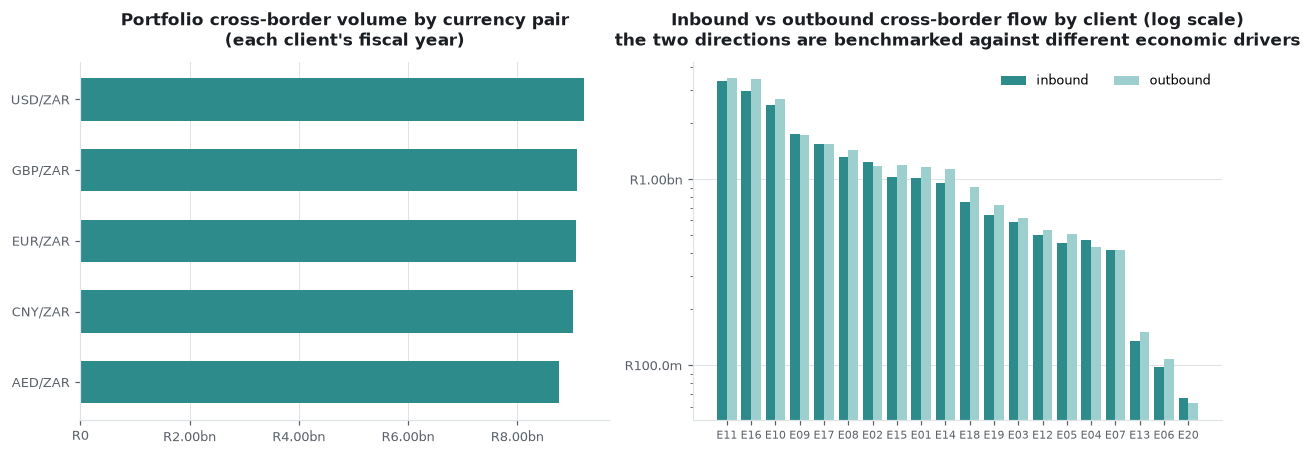

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# --- currency-pair mix across the portfolio -----------------------------------------
pairs = {"USD": "xb_pair_usd_volume_zar_fy", "EUR": "xb_pair_eur_volume_zar_fy",
         "GBP": "xb_pair_gbp_volume_zar_fy", "AED": "xb_pair_aed_volume_zar_fy",
         "CNY": "xb_pair_cny_volume_zar_fy"}
mix = pd.Series({name: FEATURES[col].sum() for name, col in pairs.items()}).sort_values()
axes[0].barh(mix.index + "/ZAR", mix.values, color=PILLAR_COLOUR["fx_global_markets"],
             height=0.6)
zar_axis(axes[0], "x")
axes[0].set_title("Portfolio cross-border volume by currency pair\n(each client's fiscal year)")
axis_style(axes[0], xgrid=True, ygrid=False)

# --- inbound vs outbound, per client -------------------------------------------------
order = FEATURES.sort_values("xb_total_volume_zar_fy", ascending=False)
x = np.arange(len(order))
axes[1].bar(x - 0.2, order["xb_inbound_volume_zar_fy"], width=0.4,
            color=PILLAR_COLOUR["fx_global_markets"], label="inbound")
axes[1].bar(x + 0.2, order["xb_outbound_volume_zar_fy"], width=0.4,
            color="#9ecfcf", label="outbound")
axes[1].set_xticks(x); axes[1].set_xticklabels(order["entity_id"], fontsize=7.5)
axes[1].set_yscale("log"); zar_axis(axes[1], "y")
axes[1].legend(ncols=2)
axes[1].set_title("Inbound vs outbound cross-border flow by client (log scale)\n"
                  "the two directions are benchmarked against different economic drivers")
axis_style(axes[1])
plt.tight_layout(); plt.show()

**Why inbound and outbound are separated.** They are driven by different economics: money
coming *in* is export settlement, benchmarked against **foreign revenue**; money going *out* is
import settlement, benchmarked against **cost of sales**. Netting them would put one
coefficient against a driver it does not describe.

## 5.3 Trade finance — instruments, direction, value, tenor, status

The four statuses are **not equivalent cash flows** and are never summed as one number
without saying so. The wallet numerator is annual *issuance demand* — instruments dated inside
the fiscal year across all four statuses — because the denominator is annual issuance demand.
That is the one place they are legitimately summed, and it is stated rather than assumed. The
live book (`active + issued`) is reported alongside it, never inside it.

In [26]:
TF_STATUS = CON.execute(f"""
    SELECT status, COUNT(*) AS instruments,
           CAST(SUM(CAST(value_zar AS DECIMAL(30,10))) AS DOUBLE) AS value_zar,
           AVG(tenor_days) AS avg_tenor_days
    FROM read_parquet('{paths.PROCESSED_DIR}/trade_finance.parquet')
    GROUP BY 1 ORDER BY value_zar DESC
""").df()
table(TF_STATUS, "Trade-finance book by status, full 36-month window — four different things",
      money=["value_zar"], counts=["instruments"], decimals=["avg_tenor_days"])

TF_FEAT = FEATURES[[
    "entity_id", "entity_name", "tf_total_value_zar_fy", "tf_instrument_count_fy",
    "tf_letters_of_credit_value_zar_fy", "tf_guarantees_value_zar_fy",
    "tf_export_collections_value_zar_fy", "tf_import_value_zar_fy", "tf_export_value_zar_fy",
    "tf_live_value_zar_fy", "tf_weighted_avg_tenor_days_fy", "tf_active_countries_fy",
]].copy()
TF_FEAT.columns = ["id", "client", "issued in FY", "instruments", "letters of credit",
                   "guarantees", "export collections", "import", "export", "live book",
                   "wtd tenor (days)", "countries"]
table(TF_FEAT.sort_values("issued in FY", ascending=False),
      "Observed trade-finance activity, each client's own fiscal year",
      money=["issued in FY", "letters of credit", "guarantees", "export collections",
             "import", "export", "live book"],
      counts=["instruments", "countries"], decimals=["wtd tenor (days)"])

**Trade-finance book by status, full 36-month window — four different things**

status,instruments,value_zar,avg_tenor_days
settled,"8,591",R16.33bn,108.347
active,"7,039",R13.40bn,106.888
issued,"2,983",R5.81bn,108.709
expired,"1,602",R2.76bn,108.230


**Observed trade-finance activity, each client's own fiscal year**

id,client,issued in FY,instruments,letters of credit,guarantees,export collections,import,export,live book,wtd tenor (days),countries
E10,Bid Corporation,R1.96bn,953,R683.4m,R405.6m,R875.3m,R1.24bn,R726.9m,R880.1m,108.019,15
E11,Pepkor Holdings,R1.58bn,"1,051",R485.1m,R282.1m,R812.0m,R785.9m,R793.3m,R842.3m,110.162,21
E16,MTN Group,R1.54bn,779,R620.2m,R586.0m,R329.6m,R847.3m,R688.6m,R761.1m,107.777,19
E09,Shoprite Holdings,R1.47bn,687,R518.3m,R197.8m,R757.0m,R799.6m,R673.5m,R729.4m,102.517,21
E01,BHP Group,R1.28bn,418,R613.9m,R439.0m,R225.8m,R601.2m,R677.5m,R569.2m,103.441,10
E18,The Bidvest Group,R1.15bn,716,R580.2m,R300.3m,R268.6m,R617.9m,R531.3m,R616.9m,107.324,22
E02,Glencore,R1.03bn,250,R402.1m,R408.4m,R219.1m,R405.4m,R624.2m,R612.1m,108.924,15
E03,Anglo American,R658.7m,287,R264.4m,R237.8m,R156.5m,R418.2m,R240.5m,R370.0m,93.650,16
E05,Gold Fields,R526.3m,299,R243.3m,R163.3m,R119.7m,R255.9m,R270.4m,R287.6m,122.204,14
E04,AngloGold Ashanti,R419.4m,264,R184.5m,R122.1m,R112.9m,R207.8m,R211.7m,R203.5m,114.602,18


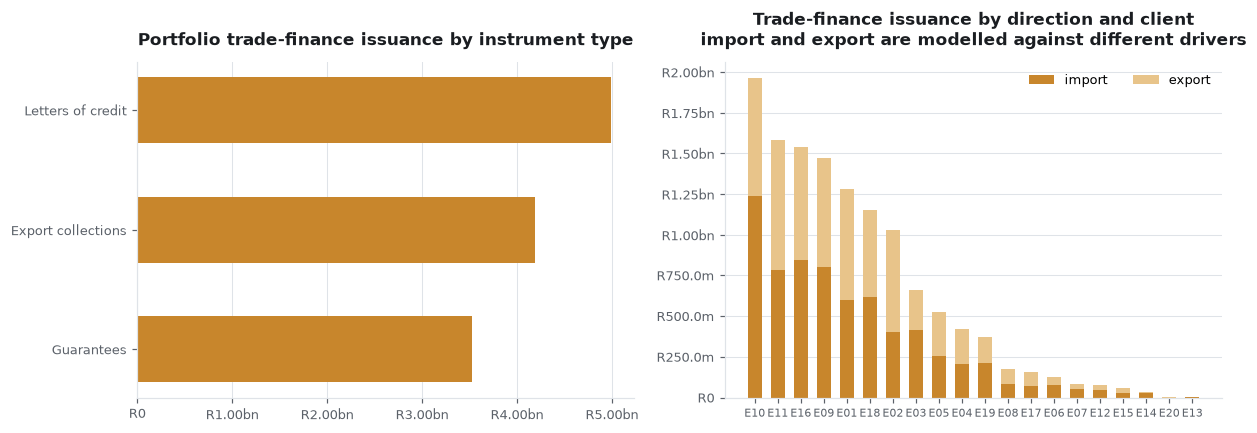

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

instruments = pd.Series({
    "Letters of credit": FEATURES["tf_letters_of_credit_value_zar_fy"].sum(),
    "Guarantees": FEATURES["tf_guarantees_value_zar_fy"].sum(),
    "Export collections": FEATURES["tf_export_collections_value_zar_fy"].sum(),
}).sort_values()
axes[0].barh(instruments.index, instruments.values, color=PILLAR_COLOUR["trade_finance"],
             height=0.55)
zar_axis(axes[0], "x")
axes[0].set_title("Portfolio trade-finance issuance by instrument type")
axis_style(axes[0], xgrid=True, ygrid=False)

order = FEATURES.sort_values("tf_total_value_zar_fy", ascending=False)
x = np.arange(len(order))
axes[1].bar(x, order["tf_import_value_zar_fy"], width=0.62,
            color=PILLAR_COLOUR["trade_finance"], label="import")
axes[1].bar(x, order["tf_export_value_zar_fy"], width=0.62,
            bottom=order["tf_import_value_zar_fy"], color="#e8c48a", label="export")
axes[1].set_xticks(x); axes[1].set_xticklabels(order["entity_id"], fontsize=7.5)
zar_axis(axes[1], "y"); axes[1].legend(ncols=2)
axes[1].set_title("Trade-finance issuance by direction and client\n"
                  "import and export are modelled against different drivers")
axis_style(axes[1])
plt.tight_layout(); plt.show()

## 5.4 What "single-product client" would have been, and why it is wrong

The obvious hypothesis for a share-of-wallet exercise is that some clients use one product
and not others, and that the opportunity is to cross-sell. **In this portfolio that hypothesis
is factually false**, and any deliverable claiming it would not survive a check.

In [28]:
COVERAGE = CON.execute(f"""
    SELECT COUNT(DISTINCT entity_id) AS clients_in_all_three
    FROM (SELECT entity_id FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')
          INTERSECT
          SELECT entity_id FROM read_parquet('{paths.PROCESSED_DIR}/cross_border_payments.parquet')
          INTERSECT
          SELECT entity_id FROM read_parquet('{paths.PROCESSED_DIR}/trade_finance.parquet'))
""").df().iloc[0, 0]

BREADTH = CON.execute(f"""
    SELECT SUM(CASE WHEN legs = 5 THEN 1 ELSE 0 END) AS clients_using_all_5_leg_types,
           SUM(CASE WHEN channels = 5 THEN 1 ELSE 0 END) AS clients_using_all_5_channels,
           MIN(legs) AS fewest_leg_types, MIN(channels) AS fewest_channels
    FROM (SELECT entity_id, COUNT(DISTINCT leg_type) AS legs, COUNT(DISTINCT channel) AS channels
          FROM read_parquet('{paths.PROCESSED_DIR}/transactional_banking.parquet')
          GROUP BY entity_id)
""").df().iloc[0]

print(f"Clients appearing in all three internal datasets : {COVERAGE} of 20")
print(f"Clients using all 5 transactional leg types      : "
      f"{int(BREADTH['clients_using_all_5_leg_types'])} of 20 "
      f"(fewest used by any client: {int(BREADTH['fewest_leg_types'])})")
print(f"Clients using all 5 channels                     : "
      f"{int(BREADTH['clients_using_all_5_channels'])} of 20 "
      f"(fewest: {int(BREADTH['fewest_channels'])})")
print("\nThere is essentially no single-product client and no coverage gap to find. The real "
      "pattern is UNIFORM PRODUCT BREADTH WITH HETEROGENEOUS DEPTH — which is exactly what a "
      "share-of-wallet measure, rather than a coverage measure, is built to detect.")

DEPTH = FEATURES[["entity_id", "entity_name", "txn_total_volume_zar_fy",
                  "xb_total_volume_zar_fy", "txn_transaction_count_fy",
                  "xb_transaction_count_fy"]].copy()
DEPTH["txn ÷ xb value"] = DEPTH["txn_total_volume_zar_fy"] / DEPTH["xb_total_volume_zar_fy"]
DEPTH = DEPTH.sort_values("txn ÷ xb value").head(6)
DEPTH.columns = ["id", "client", "transactional value", "cross-border value",
                 "txn count", "xb count", "txn ÷ xb value"]
table(DEPTH, "Anomalously low transactional engagement relative to FX flow — depth, not breadth",
      money=["transactional value", "cross-border value"],
      counts=["txn count", "xb count"], decimals=["txn ÷ xb value"])

Clients appearing in all three internal datasets : 20 of 20
Clients using all 5 transactional leg types      : 19 of 20 (fewest used by any client: 4)
Clients using all 5 channels                     : 20 of 20 (fewest: 5)

There is essentially no single-product client and no coverage gap to find. The real pattern is UNIFORM PRODUCT BREADTH WITH HETEROGENEOUS DEPTH — which is exactly what a share-of-wallet measure, rather than a coverage measure, is built to detect.


**Anomalously low transactional engagement relative to FX flow — depth, not breadth**

id,client,transactional value,cross-border value,txn count,xb count,txn ÷ xb value
E17,Vodacom Group,R249.8m,R3.09bn,"2,594","5,781",0.081
E20,Shaftesbury Capital plc,R12.1m,R129.5m,482,628,0.093
E13,NEPI Rockcastle,R44.1m,R286.8m,"1,074","1,104",0.154
E12,Clicks Group,R202.5m,R1.03bn,"3,048","2,555",0.196
E06,Valterra Platinum,R51.7m,R205.8m,279,388,0.251
E07,OUTsurance Group,R282.5m,R829.0m,"4,507","2,449",0.341


---

# 6. External financial features

What the client **discloses**. Sixteen monetary fields plus employees, converted to ZAR under
the §4 policy, form the economic drivers of every estimate.

**Disclosure coverage — 20 clients × 19 fields**

field,disclosed,absent,absence_reasons
capex,20,0,nan
cash_and_equivalents,20,0,nan
debt_current,20,0,nan
debt_noncurrent,20,0,nan
finance_costs,20,0,nan
gross_debt,20,0,nan
revenue_total,20,0,nan
trade_payables,20,0,nan
trade_receivables,20,0,nan
inventory,17,3,NOT_DISCLOSED


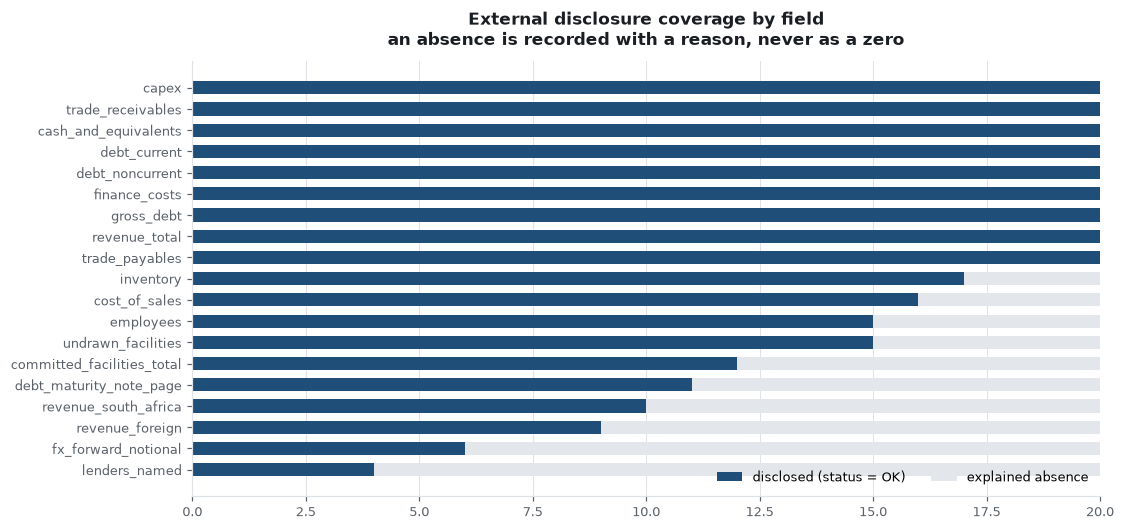

In [29]:
COVERAGE = CON.execute(f"""
    SELECT field,
           SUM(CASE WHEN status = 'OK' THEN 1 ELSE 0 END) AS disclosed,
           SUM(CASE WHEN status <> 'OK' THEN 1 ELSE 0 END) AS absent,
           string_agg(DISTINCT CASE WHEN status <> 'OK' THEN status END, ', ') AS absence_reasons
    FROM {NORMALIZED}
    GROUP BY field ORDER BY disclosed DESC, field
""").df()
table(COVERAGE, "Disclosure coverage — 20 clients × 19 fields",
      counts=["disclosed", "absent"])

fig, ax = plt.subplots(figsize=(10.5, 5))
order = COVERAGE.sort_values("disclosed")
ax.barh(order["field"], order["disclosed"], color=PILLAR_COLOUR["cash_management"], height=0.62,
        label="disclosed (status = OK)")
ax.barh(order["field"], order["absent"], left=order["disclosed"], color="#e3e6ea", height=0.62,
        label="explained absence")
ax.set_xlim(0, 20); ax.legend(ncols=2, loc="lower right")
ax.set_title("External disclosure coverage by field\n"
             "an absence is recorded with a reason, never as a zero")
axis_style(ax, xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

## 6.1 From disclosure to economic driver — never straight to bank wallet

A disclosed financial figure is **not** a banking wallet. It is the *scale of the client's own
economic activity* that a banking product attaches to. The engine turns one into the other in
exactly one of four ways, and every component records which was used.

| Basis | What it means | Where it is used |
|---|---|---|
| `accounting_identity` | The coefficient is 1.0 because the cash must move. Revenue is collected into a bank account; cost of sales is paid out of one. Not an estimate. | Cash management, both legs |
| `structural` | The coefficient follows from a disclosed structure — debt classified current is contractually repayable within twelve months; undrawn committed facilities are by definition unused headroom another lender provides. | Lending refinancing and undrawn legs; FX forward roll |
| `portfolio_benchmark` | No identity exists, so the coefficient is **measured from this portfolio at build time** — the intensity a well-penetrated peer achieves (§11). | FX and trade sub-models; lending working capital |
| `judgement` | A number that could not be derived. There are deliberately few, each is named, and a diagnostic fires when an estimate leans on one. | `capex_debt_funded_share = 0.30`; the IB thresholds |

The full registry is in `src/syn_wallet/wallet/assumptions.py` and is republished with every
run, so a reader can see every number that influenced an estimate and where its authority
comes from.

In [30]:
ASSUMPTIONS = load("model_assumptions")
DRIVER_MAP = pd.DataFrame([
    ("revenue_total", "flow", "collections (identity) · guarantee issuance (benchmark) · "
     "IB scale and leverage percentiles"),
    ("cost_of_sales", "flow", "supplier payments (identity) · import settlement (benchmark) · "
     "import documentary credit (benchmark)"),
    ("revenue_foreign", "flow", "export settlement (benchmark) · export documentary (benchmark)"),
    ("capex", "flow", "capex funding (judgement 0.30) · IB capex-intensity percentile"),
    ("finance_costs", "flow", "implied cost of debt, an IB mandate threshold"),
    ("inventory / trade_receivables / trade_payables", "stock",
     "working capital = inventory + receivables − payables, the lending working-capital driver"),
    ("debt_current", "stock", "refinancing need (structural, coefficient 1.0)"),
    ("gross_debt / debt_noncurrent", "stock", "leverage and near-term-maturity IB percentiles"),
    ("undrawn_facilities", "stock", "committed headroom another lender provides (structural)"),
    ("committed_facilities_total", "stock", "facility context; drawn = committed − undrawn"),
    ("fx_forward_notional", "stock", "hedging execution (structural, 1.0 roll per year)"),
    ("cash_and_equivalents", "stock", "net debt, an IB leverage input"),
    ("employees", "not monetary", "payroll mandate signal (instructions per 1,000 staff)"),
    ("lenders_named", "not monetary", "syndicate-breadth IB percentile · competitor-lending evidence"),
], columns=["disclosed field", "item class", "becomes which economic driver"])
table(DRIVER_MAP, "Disclosure → economic driver map")

table(ASSUMPTIONS.groupby("basis", as_index=False)
      .agg(coefficients=("name", "count"), examples=("name", lambda s: ", ".join(sorted(s)[:3]))),
      "The assumption registry, grouped by where each coefficient's authority comes from",
      counts=["coefficients"])

**Disclosure → economic driver map**

disclosed field,item class,becomes which economic driver
revenue_total,flow,collections (identity) · guarantee issuance (benchmark) · IB scale and leverage percentiles
cost_of_sales,flow,supplier payments (identity) · import settlement (benchmark) · import documentary credit (benchmark)
revenue_foreign,flow,export settlement (benchmark) · export documentary (benchmark)
capex,flow,capex funding (judgement 0.30) · IB capex-intensity percentile
finance_costs,flow,"implied cost of debt, an IB mandate threshold"
inventory / trade_receivables / trade_payables,stock,"working capital = inventory + receivables − payables, the lending working-capital driver"
debt_current,stock,"refinancing need (structural, coefficient 1.0)"
gross_debt / debt_noncurrent,stock,leverage and near-term-maturity IB percentiles
undrawn_facilities,stock,committed headroom another lender provides (structural)
committed_facilities_total,stock,facility context; drawn = committed − undrawn


**The assumption registry, grouped by where each coefficient's authority comes from**

basis,coefficients,examples
accounting_identity,3,"collections_banked_share, opportunity_intensity_denominator, supplier_payment_share_of_cogs"
judgement,17,"benchmark_min_sample, benchmark_percentile, capex_debt_funded_share"
structural,7,"benchmark_leave_one_out, cash_management_fee_wallet, fx_forward_rolls_per_year"


> **No fee, margin or basis-point assumption appears anywhere in this repository.** Syn Bank is
> fictional and discloses no pricing — there is no rates config, no economics config, no fee
> schedule. Every metric is a flow-based ratio or a relative economic weight. Any absolute
> revenue number would be invented.

---

# 7. Pillar 1 — Transactional / Cash Management  ·  `CORE`

## The formula

```
addressable_cash_flow_zar = revenue_total_zar + cost_of_sales_zar
                            ^ collections        ^ supplier payments
                            (revenue is           (cost of sales is paid
                             collected into        out of a bank account)
                             a bank account)

observed_zar    = domestic collections + domestic supplier payments, fiscal year
share           = observed_zar / addressable_cash_flow_zar
opportunity_zar = addressable_cash_flow_zar − observed_zar        (floored at 0)

cash_management_wallet_zar = NULL     ← no disclosed pricing, never derived
```

Both coefficients are **1.0 on an accounting-identity basis**, which is why no scenario in the
36-run sensitivity grid can move this pillar (§14).

In [31]:
table(ASSUMPTIONS[ASSUMPTIONS["product"] == "cash_management"][
          ["name", "value", "unit", "basis", "rationale"]],
      "Every coefficient the cash pillar uses, from the production registry")

**Every coefficient the cash pillar uses, from the production registry**

name,value,unit,basis,rationale
collections_banked_share,1.000000,fraction of revenue,accounting_identity,"Revenue is ultimately received into a bank account, so the collections a corporate generates across all of its banks equals its revenue. This is an identity, not a coefficient to tune. Where reported revenue is not a cash measure (insurance), the sector applicability weight and a diagnostic flag carry the caveat instead of a fabricated haircut."
supplier_payment_share_of_cogs,1.000000,fraction of cost of sales,accounting_identity,Cost of sales is settled in cash to suppliers through a bank account. Timing differences shift the payment between periods but not the annual total in a steady state.
payroll_rand_wallet,nan,excluded,judgement,"DELIBERATELY EXCLUDED from the rand wallet. No employee-cost field exists in the external data, and observed payroll volume is a token R61m across the whole portfolio for a year at an average of R11k per transaction. Sizing a payroll wallet would require inventing a cost per head. Payroll is carried instead as a mandate signal (rows per employee) feeding confidence and the narrative."
tax_rand_wallet,nan,excluded,judgement,"DELIBERATELY EXCLUDED. No tax charge is disclosed, and observed tax volume is R163m across the portfolio for a year on 5,395 instructions over three years. Retained as an engagement signal only."
intercompany_rand_wallet,nan,excluded,judgement,"DELIBERATELY EXCLUDED from both numerator and denominator. Treasury sweep volume has no external anchor, and including observed sweeps in the numerator while the denominator cannot cover them would inflate share. Reported separately as out-of-scope observed activity so the excluded amount stays visible."
swift_overlap_treatment,nan,exclusion,structural,"SWIFT-channel transactional rows conceptually overlap the cross-border pillar and the overlap cannot be resolved from the supplied fields. They are excluded from the cash numerator and NOT added to the FX numerator, so no rand is counted twice in either direction. The excluded amount is published per client."
cash_management_fee_wallet,nan,not estimable,structural,"The fee wallet on addressable cash flow is published as NULL for every client and is never derived. Syn Bank is fictional and discloses no pricing, so any rand fee figure would rest on an invented basis-point assumption. The flow figure is the client's turnover, not the bank's revenue, and the two are given different column names so a reader cannot mistake one for the other."


## Results

In [32]:
CASH = ENGINE[ENGINE["product"] == "cash_management"].copy()
CASH_VIEW = CASH[["entity_id", "entity_name", "sector", "observed_zar",
                  "addressable_cash_flow_zar", "share", "opportunity_zar",
                  "confidence", "confidence_band"]].sort_values(
                      "addressable_cash_flow_zar", ascending=False)
CASH_VIEW.columns = ["id", "client", "sector", "observed", "Addressable Cash Flow",
                     "share of wallet", "opportunity", "confidence", "band"]
table(CASH_VIEW, "Cash Management — all 20 clients, each on its own fiscal year",
      money=["observed", "Addressable Cash Flow", "opportunity"],
      percent=["share of wallet"], decimals=["confidence"])

print(f"Portfolio observed          : {zar(CASH['observed_zar'].sum())}")
print(f"Portfolio Addressable Cash Flow : {zar(CASH['addressable_cash_flow_zar'].sum())}")
print(f"Portfolio share of wallet   : "
      f"{pct(CASH['observed_zar'].sum() / CASH['addressable_cash_flow_zar'].sum())}")
print(f"Highest client share        : {pct(CASH['share'].max())}   "
      f"lowest: {pct(CASH['share'].min(), 4)}")

**Cash Management — all 20 clients, each on its own fiscal year**

id,client,sector,observed,Addressable Cash Flow,share of wallet,opportunity,confidence,band
E02,Glencore,mining,R2.50bn,R8.75tn,0.03%,R8.75tn,0.938,HIGH
E01,BHP Group,mining,R9.32bn,R1.52tn,0.61%,R1.51tn,0.669,MEDIUM
E03,Anglo American,mining,R4.82bn,R540.95bn,0.89%,R536.14bn,0.665,MEDIUM
E09,Shoprite Holdings,consumer,R3.96bn,R447.94bn,0.88%,R443.98bn,0.925,HIGH
E10,Bid Corporation,consumer,R4.25bn,R413.51bn,1.03%,R409.26bn,0.926,HIGH
E16,MTN Group,telecoms,R3.96bn,R376.90bn,1.05%,R372.94bn,0.593,MEDIUM
E15,Naspers,tech,R538.0m,R292.67bn,0.18%,R292.13bn,0.945,HIGH
E17,Vodacom Group,telecoms,R164.2m,R278.72bn,0.06%,R278.56bn,0.556,MEDIUM
E04,AngloGold Ashanti,mining,R1.03bn,R266.72bn,0.38%,R265.70bn,0.940,HIGH
E14,Prosus,tech,R744.3m,R258.47bn,0.29%,R257.73bn,0.952,HIGH


Portfolio observed          : R58.81bn
Portfolio Addressable Cash Flow : R14.31tn
Portfolio share of wallet   : 0.41%
Highest client share        : 9.34%   lowest: 0.0204%


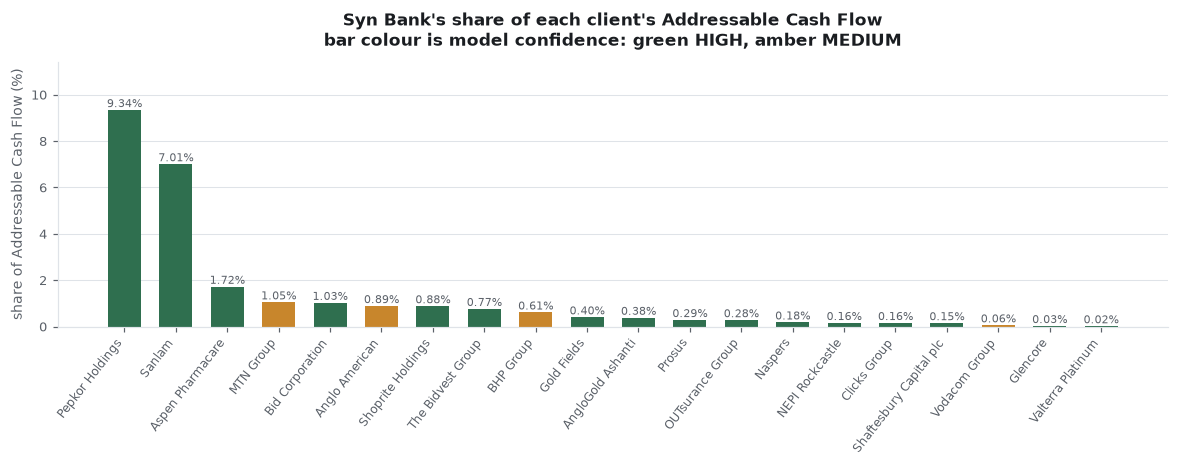

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.4))
order = CASH.sort_values("share", ascending=False)
x = np.arange(len(order))
ax.bar(x, order["share"] * 100, width=0.64,
       color=[CONFIDENCE_COLOUR[b] for b in order["confidence_band"]])
ax.set_xticks(x); ax.set_xticklabels(order["entity_name"], rotation=52, ha="right", fontsize=8)
ax.set_ylabel("share of Addressable Cash Flow (%)")
ax.set_title("Syn Bank's share of each client's Addressable Cash Flow\n"
             "bar colour is model confidence: green HIGH, amber MEDIUM")
for x_, v in zip(x, order["share"] * 100):
    ax.text(x_, v + 0.12, f"{v:.2f}%", ha="center", fontsize=7.5, color=MUTED)
ax.set_ylim(0, order["share"].max() * 100 * 1.22)
axis_style(ax)
plt.tight_layout(); plt.show()

> ## This is a flow magnitude. It is not bank revenue and it is not a fee wallet.
>
> **Addressable Cash Flow is the client's own annual operating turnover** — the money it must
> push through *a* bank account somewhere. Syn Bank's share of it says how much of that
> turnover currently settles through Syn Bank. It says nothing at all about what Syn Bank
> would earn, because the fee wallet on that flow **is not estimable from this data** and is
> published as a named NULL column so that its absence is visible rather than something a
> reader fills in with the flow figure.

In [34]:
assert PROFILE["cash_management_wallet_zar"].isna().all(), "the fee wallet must stay NULL"
print("✓ cash_management_wallet_zar is NULL for all 20 clients — asserted here, and enforced "
      "by the wallet engine and by the test suite.")
print(f"\n{assumptions.TERMINOLOGY['cash_management_wallet_zar']}")

✓ cash_management_wallet_zar is NULL for all 20 clients — asserted here, and enforced by the wallet engine and by the test suite.

Cash Management Wallet -- the fee income a bank would earn on that flow. NOT ESTIMABLE and published as NULL for every client. Syn Bank is fictional and discloses no pricing, so converting flow to wallet would need an invented basis-point assumption.


## Payroll, tax and intercompany — carried separately, deliberately

These three legs are excluded from **both** the numerator and the denominator. No external
field sizes an employee cost base, a tax charge, or a treasury sweep programme, so there is no
denominator to divide by; and putting observed sweeps into the numerator while the denominator
cannot cover them would inflate every share. The excluded amount is published per client as
`out_of_scope_observed_zar` so it stays visible, and the underlying counts feed the confidence
score and the narrative as **mandate signals**.

In [35]:
ESTIMATES = load("wallet_estimates")
OUT_OF_SCOPE = ESTIMATES[ESTIMATES["product"] == "cash_management"][
    ["entity_id", "entity_name", "observed_zar", "out_of_scope_observed_zar",
     "overlap_excluded_zar"]].copy()
OUT_OF_SCOPE = OUT_OF_SCOPE.merge(
    FEATURES[["entity_id", "txn_payroll_count_fy", "txn_tax_count_fy",
              "txn_intercompany_sweeps_count_fy", "employees"]], on="entity_id")
OUT_OF_SCOPE["payroll per 1,000 staff"] = (
    OUT_OF_SCOPE["txn_payroll_count_fy"] / OUT_OF_SCOPE["employees"] * 1000)
OUT_OF_SCOPE.columns = ["id", "client", "in-scope observed", "out-of-scope observed",
                        "SWIFT excluded", "payroll n", "tax n", "sweeps n", "employees",
                        "payroll per 1,000 staff"]
table(OUT_OF_SCOPE.sort_values("out-of-scope observed", ascending=False),
      "Out-of-scope observed activity — reported, never folded into the share",
      money=["in-scope observed", "out-of-scope observed", "SWIFT excluded"],
      counts=["payroll n", "tax n", "sweeps n", "employees"],
      decimals=["payroll per 1,000 staff"])

**Out-of-scope observed activity — reported, never folded into the share**

id,client,in-scope observed,out-of-scope observed,SWIFT excluded,payroll n,tax n,sweeps n,employees,"payroll per 1,000 staff"
E11,Pepkor Holdings,R14.27bn,R18.42bn,R1.57bn,"1,160",353,"72,376",n/a,n/a
E08,Sanlam,R9.12bn,R11.98bn,R1.05bn,818,248,"42,217","23,363",35.013
E10,Bid Corporation,R4.25bn,R6.47bn,R485.7m,702,222,"19,085","30,581",22.955
E16,MTN Group,R3.96bn,R5.96bn,R432.9m,683,193,"17,938",n/a,n/a
E09,Shoprite Holdings,R3.96bn,R5.89bn,R442.2m,687,178,"17,202","168,000",4.089
E01,BHP Group,R9.32bn,R4.80bn,R1.02bn,160,54,"9,575","91,304",1.752
E18,The Bidvest Group,R1.67bn,R2.50bn,R186.1m,353,103,"8,911","131,326",2.688
E03,Anglo American,R4.82bn,R2.36bn,R502.7m,122,40,"6,639","60,000",2.033
E19,Aspen Pharmacare,R1.16bn,R1.74bn,R136.3m,350,102,"8,760","9,557",36.622
E02,Glencore,R2.50bn,R1.49bn,R293.8m,64,20,"1,809","140,000",0.457


---

# 8. Pillar 2 — FX / Global Markets  ·  `CORE`

No disclosure states any client's total cross-border settlement volume across all of its
banks. There is no identity to appeal to. So the denominator is built the only defensible way
left: **the client's own disclosed exposure, scaled by the intensity a well-penetrated peer in
this portfolio achieves.**

```
export_settlement = foreign_revenue_zar     × peer_p75(xb_inbound / revenue_foreign)
import_settlement = cost_of_sales_zar       × peer_p75(xb_outbound / cost_of_sales)
hedging_execution = fx_forward_notional_zar × 1.0 roll per year   (structural floor)

addressable_zar = export + import + hedging          (floored at observed)
observed_zar    = cross-border volume, fiscal year
share           = observed_zar / addressable_zar
```

Inbound and outbound are benchmarked separately because they are driven by different
economics. Disclosed FX forwards are added where a client publishes a notional — one roll per
year is a deliberate floor, since corporates typically roll shorter-dated hedges several times
and no tenor is disclosed.

## 8.1 The peer benchmark, and the two rules that make it defensible

### Leave-one-out

**The client being estimated is excluded from the population that sets its own coefficient.**
Including it is circular in both directions: a heavily penetrated client raises the benchmark
it is then measured against, flattening its own gap; a dormant client drags the benchmark down
and makes its own share look healthy. With twenty clients, one company is 5% of the portfolio
and up to a third of its sector, so this is a material correction rather than a theoretical
one.

### Sector before portfolio, with a hard floor on sample size

```
IF the client's sector has ≥ 3 peer observations AFTER excluding the client:
        use the sector P75
ELSE:   use the portfolio P75  (itself requiring ≥ 4 contributors after exclusion)
IF neither population is large enough:
        publish no coefficient — the component is NULL, never a borrowed number
```

A sector benchmark built from one or two companies is a restatement of those companies, not a
sector norm.

In [36]:
BENCHMARK_METRICS = load("model_benchmark_metrics")
table(BENCHMARK_METRICS[[
        "metric", "product", "numerator", "denominator", "percentile", "population_n",
        "population_median", "population_p75", "clients_on_sector_benchmark",
        "clients_on_portfolio_benchmark", "clients_without_benchmark"]],
      "Every measured coefficient in the engine, and which population each client landed on",
      decimals=["percentile", "population_median", "population_p75"],
      counts=["population_n", "clients_on_sector_benchmark",
              "clients_on_portfolio_benchmark", "clients_without_benchmark"])

print("The two foreign-revenue metrics land on the PORTFOLIO for all 20 clients. That is the "
      "sector rule working, not failing: only 9 of 20 clients disclose foreign revenue at all, "
      "spread across 6 sectors with at most two each, so no sector can reach three peers. The "
      "rule declines to build a sector benchmark exactly where it would have been one or two "
      "companies.")

**Every measured coefficient in the engine, and which population each client landed on**

metric,product,numerator,denominator,percentile,population_n,population_median,population_p75,clients_on_sector_benchmark,clients_on_portfolio_benchmark,clients_without_benchmark
cash_cogs_to_revenue_imputation,cash_management,cost_of_sales_zar,revenue_total_zar,0.500,12,0.662,n/a,2,2,0
fx_inbound_per_foreign_revenue,fx_global_markets,xb_inbound_volume_zar_fy,revenue_foreign_zar,0.750,9,0.020,0.085,0,20,0
fx_outbound_per_cost_of_sales,fx_global_markets,xb_outbound_volume_zar_fy,cost_of_sales_zar,0.750,12,0.011,0.015,10,10,0
trade_import_per_cost_of_sales,trade_finance,tf_import_value_zar_fy,cost_of_sales_zar,0.750,12,0.003,0.007,10,10,0
trade_export_per_foreign_revenue,trade_finance,tf_export_value_zar_fy,revenue_foreign_zar,0.750,6,0.010,0.028,0,20,0
trade_guarantees_per_revenue,trade_finance,tf_guarantees_value_zar_fy,revenue_total_zar,0.750,20,0.001,0.002,10,10,0
lending_current_debt_per_working_capital,lending,debt_current_zar,working_capital_zar,0.500,12,0.258,0.318,10,10,0


The two foreign-revenue metrics land on the PORTFOLIO for all 20 clients. That is the sector rule working, not failing: only 9 of 20 clients disclose foreign revenue at all, spread across 6 sectors with at most two each, so no sector can reach three peers. The rule declines to build a sector benchmark exactly where it would have been one or two companies.


In [37]:
BENCHMARKS = load("model_benchmarks")
one = BENCHMARKS[(BENCHMARKS["entity_id"] == "E09")
                 & (BENCHMARKS["metric"] == "fx_outbound_per_cost_of_sales")].iloc[0]
peer = BENCHMARKS[(BENCHMARKS["entity_id"] == "E16")
                  & (BENCHMARKS["metric"] == "fx_outbound_per_cost_of_sales")].iloc[0]
display(Markdown(f"""
**Leave-one-out, on one real coefficient — `{one['metric']}`**

| | {one['entity_name']} ({one['entity_id']}, {one['sector']}) | {peer['entity_name']} ({peer['entity_id']}, {peer['sector']}) |
|---|---|---|
| Population used | **{one['benchmark_level']}**, n = {int(one['benchmark_n'])} | **{peer['benchmark_level']}**, n = {int(peer['benchmark_n'])} |
| Why that population | `{one['fallback_reason']}` | `{peer['fallback_reason']}` |
| Contributing peers | {one['sample_entities']} | {peer['sample_entities']} |
| Population median | {one['benchmark_median']:.4f} | {peer['benchmark_median']:.4f} |
| Population **P{one['percentile'] * 100:.0f}** ← the coefficient | **{one['benchmark_p75']:.4f}** | **{peer['benchmark_p75']:.4f}** |
| Population max | {one['benchmark_max']:.4f} | {peer['benchmark_max']:.4f} |
| Leave-one-out enforced | `{bool(one['leave_one_out'])}` · in own population: `{bool(one['self_in_population'])}` | `{bool(peer['leave_one_out'])}` · in own population: `{bool(peer['self_in_population'])}` |

Shoprite reaches a three-peer consumer population and so gets a **sector** coefficient
{one['benchmark_p75'] / peer['benchmark_p75']:.1f}× the portfolio one. MTN's telecoms sector
cannot reach three peers after exclusion, so it falls back to the portfolio and the fallback
reason is recorded rather than inferred. Each of the 120 client × metric coefficients carries
this much detail, so any single estimate can be reconstructed from `model_benchmarks.parquet`.
"""))

assert not BENCHMARKS["self_in_population"].any(), "a client contributed to its own benchmark"
print("✓ asserted across all 120 coefficients: no client appears in the population that sets "
      "its own coefficient.")


**Leave-one-out, on one real coefficient — `fx_outbound_per_cost_of_sales`**

| | Shoprite Holdings (E09, consumer) | MTN Group (E16, telecoms) |
|---|---|---|
| Population used | **sector**, n = 3 | **portfolio**, n = 12 |
| Why that population | `sector_sample_3_meets_minimum_3` | `sector_sample_0_below_minimum_3` |
| Contributing peers | E10, E11, E12 | E02, E04, E05, E06, E09, E10, E11, E12, E14, E15, E18, E19 |
| Population median | 0.0151 | 0.0106 |
| Population **P75** ← the coefficient | **0.0378** | **0.0148** |
| Population max | 0.0605 | 0.0605 |
| Leave-one-out enforced | `True` · in own population: `False` | `True` · in own population: `False` |

Shoprite reaches a three-peer consumer population and so gets a **sector** coefficient
2.6× the portfolio one. MTN's telecoms sector
cannot reach three peers after exclusion, so it falls back to the portfolio and the fallback
reason is recorded rather than inferred. Each of the 120 client × metric coefficients carries
this much detail, so any single estimate can be reconstructed from `model_benchmarks.parquet`.


✓ asserted across all 120 coefficients: no client appears in the population that sets its own coefficient.


## 8.2 Results

In [38]:
FX_ROWS = ENGINE[ENGINE["product"] == "fx_global_markets"].copy()
FX_VIEW = FX_ROWS[["entity_id", "entity_name", "sector", "observed_zar", "addressable_zar",
                   "share", "opportunity_zar", "confidence", "confidence_band",
                   "benchmark_level", "benchmark_n", "high_severity_diagnostic"]].sort_values(
                       "opportunity_zar", ascending=False)
FX_VIEW.columns = ["id", "client", "sector", "observed", "peer-benchmark addressable",
                   "share", "opportunity", "confidence", "band", "benchmark", "n", "HIGH flag"]
table(FX_VIEW, "FX / Global Markets — all 20 clients",
      money=["observed", "peer-benchmark addressable", "opportunity"],
      percent=["share"], decimals=["confidence"], counts=["n"])

**FX / Global Markets — all 20 clients**

id,client,sector,observed,peer-benchmark addressable,share,opportunity,confidence,band,benchmark,n,HIGH flag
E02,Glencore,mining,R2.41bn,R195.48bn,1.23%,R193.07bn,0.190,LOW,mixed,9,True
E01,BHP Group,mining,R2.17bn,R45.29bn,4.80%,R43.12bn,0.235,LOW,mixed,9,True
E16,MTN Group,telecoms,R6.43bn,R24.02bn,26.78%,R17.59bn,0.429,LOW,portfolio,12,True
E06,Valterra Platinum,mining,R205.8m,R13.62bn,1.51%,R13.41bn,0.413,LOW,mixed,8,True
E03,Anglo American,mining,R1.21bn,R13.78bn,8.75%,R12.57bn,0.135,LOW,mixed,9,True
E17,Vodacom Group,telecoms,R3.09bn,R10.97bn,28.13%,R7.89bn,0.405,LOW,portfolio,12,True
E15,Naspers,tech,R2.21bn,R8.71bn,25.33%,R6.50bn,0.207,LOW,portfolio,11,False
E04,AngloGold Ashanti,mining,R901.2m,R7.13bn,12.64%,R6.23bn,0.167,LOW,mixed,9,False
E14,Prosus,tech,R2.08bn,R7.74bn,26.89%,R5.66bn,0.206,LOW,portfolio,11,False
E19,Aspen Pharmacare,industrials_pharma,R1.37bn,R7.00bn,19.58%,R5.63bn,0.619,MEDIUM,portfolio,11,False


## 8.3 Sensitivity — and why no single FX number should be quoted

The FX denominator **is** the coefficient: with no disclosed total, changing the peer statistic
changes the answer directly. Across the 36-scenario grid the portfolio FX **opportunity** total
spans **7.4×** — R78.37bn to R583.70bn.

This is not a defect. It is the honest consequence of having no disclosure to anchor to, and
the correct response is to **rank these clients and quote the range** — never a point estimate.

In [39]:
SENSITIVITY = load("opportunity_sensitivity_summary")
FX_SENS = SENSITIVITY[SENSITIVITY["product"] == "fx_global_markets"].merge(
    ENGINE[["entity_id", "entity_name"]].drop_duplicates(), on="entity_id")
FX_SENS_VIEW = FX_SENS[["entity_id", "entity_name", "estimate_low", "estimate_base",
                        "estimate_high", "estimate_range_pct", "rank_base", "rank_swing",
                        "rank_stability", "sensitivity_flag"]].sort_values("estimate_base",
                                                                          ascending=False)
FX_SENS_VIEW.columns = ["id", "client", "low", "base", "high", "range %", "base rank",
                        "rank swing", "rank stability", "flag"]
table(FX_SENS_VIEW, "FX addressable estimate across all 36 scenarios",
      money=["low", "base", "high"], percent=["range %"],
      counts=["base rank", "rank swing"])

flags = FX_SENS["sensitivity_flag"].value_counts()
print("Sensitivity flags across the 20 FX estimates: "
      + ", ".join(f"{k} {v}" for k, v in flags.items()))

**FX addressable estimate across all 36 scenarios**

id,client,low,base,high,range %,base rank,rank swing,rank stability,flag
E02,Glencore,R53.76bn,R195.48bn,R358.29bn,155.79%,1,1,STABLE,SENSITIVE
E01,BHP Group,R16.96bn,R45.29bn,R77.08bn,132.74%,3,1,STABLE,SENSITIVE
E16,MTN Group,R6.43bn,R24.02bn,R33.72bn,113.59%,4,16,SENSITIVE,SENSITIVE
E03,Anglo American,R3.68bn,R13.78bn,R25.10bn,155.51%,7,3,MODERATE,SENSITIVE
E06,Valterra Platinum,R2.42bn,R13.62bn,R20.19bn,130.41%,2,2,STABLE,SENSITIVE
E17,Vodacom Group,R3.09bn,R10.97bn,R15.13bn,109.78%,5,14,SENSITIVE,SENSITIVE
E10,Bid Corporation,R5.18bn,R8.93bn,R11.42bn,69.78%,17,4,MODERATE,SENSITIVE
E09,Shoprite Holdings,R3.46bn,R8.80bn,R11.25bn,88.55%,10,6,SENSITIVE,SENSITIVE
E15,Naspers,R2.76bn,R8.71bn,R14.04bn,129.40%,8,5,MODERATE,SENSITIVE
E14,Prosus,R2.44bn,R7.74bn,R12.51bn,130.01%,11,4,MODERATE,SENSITIVE


Sensitivity flags across the 20 FX estimates: SENSITIVE 18, STABLE 2


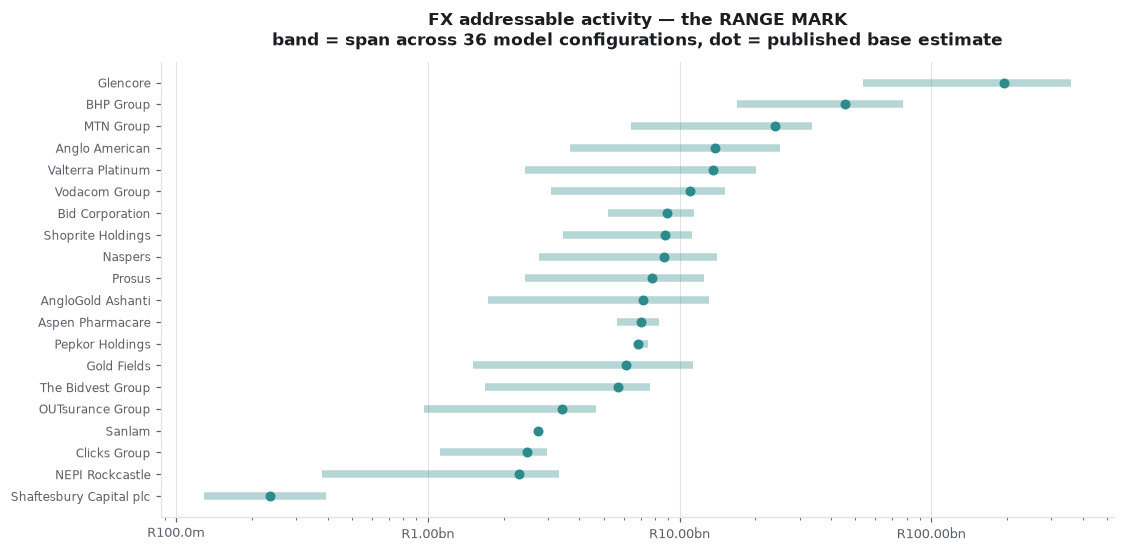

In [40]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
order = FX_SENS.sort_values("estimate_base")
y = np.arange(len(order))
ax.hlines(y, order["estimate_low"], order["estimate_high"],
          color=PILLAR_COLOUR["fx_global_markets"], lw=5, alpha=0.35)
ax.scatter(order["estimate_base"], y, color=PILLAR_COLOUR["fx_global_markets"], s=32, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(order["entity_name"], fontsize=8)
ax.set_xscale("log"); zar_axis(ax, "x")
ax.set_title("FX addressable activity — the RANGE MARK\n"
             "band = span across 36 model configurations, dot = published base estimate")
axis_style(ax, xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

---

# 9. Pillar 3 — Trade Finance  ·  `CORE`

Same structure as FX, three sub-models, and one extra rule that matters more here than
anywhere else in the engine.

```
import_documentary = cost_of_sales_zar   × peer_p75(tf_import      / cost_of_sales)
export_documentary = foreign_revenue_zar × peer_p75(tf_export      / revenue_foreign)
guarantees         = revenue_total_zar   × peer_p75(tf_guarantees  / revenue)

addressable_zar = the applicable components          (floored at observed)
observed_zar    = instruments dated in the fiscal year, all four statuses
```

## 9.1 Sector treatment — switching a sub-model off is a modelling decision, not a data fact

"Should an insurer be scored for import letters of credit?" is a judgement, so it is declared
in the assumption registry rather than emerging from an aggregation. An insurer buys no goods;
a property group holds no tradeable inventory. For both, the **import and export documentary
sub-models are suppressed entirely** and only guarantees apply — genuine ones, covering rental
deposits, construction performance bonds and utility guarantees. Applicability drops to 0.30,
which pushes confidence into LOW, so the reader is told that only a third of the model ran.

In [41]:
RULES = load("model_sector_rules")
table(RULES[RULES["product"] == "trade_finance"][
          ["sector", "applicability", "suppressed_components", "note"]].sort_values(
              "applicability"),
      "Trade-finance sector applicability, from src/syn_wallet/wallet/assumptions.py",
      decimals=["applicability"])

**Trade-finance sector applicability, from src/syn_wallet/wallet/assumptions.py**

sector,applicability,suppressed_components,note
insurance,0.300,"import_documentary, export_documentary","An insurer buys no goods, so cost of sales and inventory are not trade-finance drivers. The import and export documentary sub-models are switched off; only the guarantee sub-model applies, since financial and performance guarantees are genuine for a financial services group."
real_estate,0.300,"import_documentary, export_documentary","A property group holds no tradeable inventory and imports no goods. Import and export documentary sub-models are switched off; guarantees remain, covering rental deposits, construction performance bonds and utility guarantees."
tech,0.600,,"Digital and marketplace revenue settles electronically rather than under documentary credit, so the trade-finance drivers are weaker here than for a goods business, but device and hardware procurement keeps them relevant."
telecoms,0.600,,"Trade finance applies to network equipment and handset procurement, a minority of the cost base, and neither telecoms client discloses cost of sales at all."
consumer,1.000,,The model's economic drivers apply to this sector without adjustment.
industrials_pharma,1.000,,The model's economic drivers apply to this sector without adjustment.
mining,1.000,,The model's economic drivers apply to this sector without adjustment.


## 9.2 Results

In [42]:
TRADE_ROWS = ENGINE[ENGINE["product"] == "trade_finance"].copy()
TRADE_VIEW = TRADE_ROWS[["entity_id", "entity_name", "sector", "observed_zar",
                         "addressable_zar", "share", "opportunity_zar", "confidence",
                         "confidence_band", "benchmark_level", "benchmark_n",
                         "high_severity_diagnostic"]].sort_values("opportunity_zar",
                                                                  ascending=False)
TRADE_VIEW.columns = ["id", "client", "sector", "observed", "peer-benchmark addressable",
                      "share", "opportunity", "confidence", "band", "benchmark", "n",
                      "HIGH flag"]
table(TRADE_VIEW, "Trade Finance — all 20 clients",
      money=["observed", "peer-benchmark addressable", "opportunity"],
      percent=["share"], decimals=["confidence"], counts=["n"])

COMPONENTS = load("wallet_components")
TRADE_COMP = COMPONENTS[COMPONENTS["product"] == "trade_finance"].pivot_table(
    index=["entity_id", "entity_name", "sector"], columns="component",
    values="component_zar", aggfunc="first").reset_index()
table(TRADE_COMP.sort_values("guarantees", ascending=False),
      "Trade-finance sub-model components — a suppressed sub-model is NULL, never zero",
      money=[c for c in TRADE_COMP.columns if c not in ("entity_id", "entity_name", "sector")])

**Trade Finance — all 20 clients**

id,client,sector,observed,peer-benchmark addressable,share,opportunity,confidence,band,benchmark,n,HIGH flag
E02,Glencore,mining,R1.03bn,R72.99bn,1.41%,R71.96bn,0.251,LOW,mixed,6,True
E01,BHP Group,mining,R1.28bn,R14.12bn,9.06%,R12.84bn,0.182,LOW,mixed,6,True
E16,MTN Group,telecoms,R1.54bn,R7.10bn,21.63%,R5.56bn,0.421,LOW,portfolio,19,True
E03,Anglo American,mining,R658.7m,R5.02bn,13.12%,R4.36bn,0.178,LOW,mixed,6,True
E06,Valterra Platinum,mining,R125.2m,R3.81bn,3.28%,R3.69bn,0.482,MEDIUM,mixed,5,False
E15,Naspers,tech,R59.4m,R3.43bn,1.73%,R3.38bn,0.223,LOW,portfolio,19,True
E17,Vodacom Group,telecoms,R157.1m,R3.51bn,4.48%,R3.35bn,0.370,LOW,portfolio,19,False
E14,Prosus,tech,R34.6m,R3.05bn,1.14%,R3.01bn,0.215,LOW,portfolio,19,False
E04,AngloGold Ashanti,mining,R419.4m,R2.60bn,16.16%,R2.18bn,0.220,LOW,mixed,6,False
E05,Gold Fields,mining,R526.3m,R2.21bn,23.84%,R1.68bn,0.210,LOW,mixed,6,False


**Trade-finance sub-model components — a suppressed sub-model is NULL, never zero**

entity_id,entity_name,sector,export_documentary,guarantees,import_documentary
E02,Glencore,mining,R56.42bn,R3.17bn,R13.40bn
E01,BHP Group,mining,R11.86bn,R667.4m,R1.59bn
E09,Shoprite Holdings,consumer,R310.6m,R600.7m,R1.97bn
E10,Bid Corporation,consumer,R753.5m,R439.4m,R1.59bn
E15,Naspers,tech,R2.40bn,R320.4m,R716.2m
E16,MTN Group,telecoms,R5.77bn,R309.3m,R1.02bn
E14,Prosus,tech,R2.15bn,R286.7m,R617.7m
E17,Vodacom Group,telecoms,R2.47bn,R285.5m,R755.4m
E03,Anglo American,mining,R4.23bn,R228.8m,R566.6m
E08,Sanlam,insurance,n/a,R219.1m,n/a


## 9.3 Sensitivity

The portfolio trade **opportunity** total spans **4.0×** across the grid — R39.28bn to
R157.64bn. Less extreme than FX, and still far from robust. Rank these; quote the range.

**Trade-finance addressable estimate across all 36 scenarios**

id,client,low,base,high,range %,base rank,rank swing,rank stability,flag
E02,Glencore,R28.41bn,R72.99bn,R103.15bn,102.40%,1,0,STABLE,SENSITIVE
E01,BHP Group,R5.46bn,R14.12bn,R19.43bn,98.95%,4,1,STABLE,SENSITIVE
E16,MTN Group,R2.30bn,R7.10bn,R8.05bn,81.02%,3,9,SENSITIVE,SENSITIVE
E03,Anglo American,R1.91bn,R5.02bn,R6.92bn,99.85%,6,4,MODERATE,SENSITIVE
E06,Valterra Platinum,R1.21bn,R3.81bn,R4.79bn,93.86%,2,1,STABLE,SENSITIVE
E17,Vodacom Group,R1.18bn,R3.51bn,R3.90bn,77.64%,5,4,MODERATE,SENSITIVE
E15,Naspers,R1.26bn,R3.43bn,R3.83bn,74.92%,7,4,MODERATE,SENSITIVE
E14,Prosus,R1.12bn,R3.05bn,R3.41bn,75.06%,8,3,MODERATE,SENSITIVE
E09,Shoprite Holdings,R1.47bn,R2.89bn,R3.22bn,60.52%,10,4,MODERATE,SENSITIVE
E10,Bid Corporation,R1.96bn,R2.78bn,R3.12bn,41.57%,15,3,MODERATE,SENSITIVE


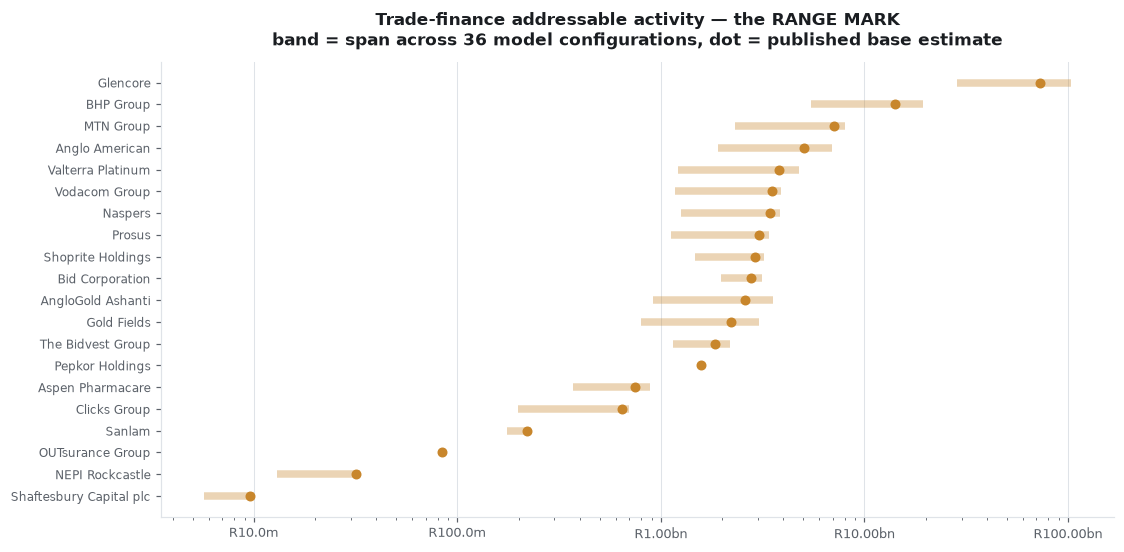

In [43]:
TRADE_SENS = SENSITIVITY[SENSITIVITY["product"] == "trade_finance"].merge(
    ENGINE[["entity_id", "entity_name"]].drop_duplicates(), on="entity_id")
TRADE_SENS_VIEW = TRADE_SENS[["entity_id", "entity_name", "estimate_low", "estimate_base",
                              "estimate_high", "estimate_range_pct", "rank_base", "rank_swing",
                              "rank_stability", "sensitivity_flag"]].sort_values(
                                  "estimate_base", ascending=False)
TRADE_SENS_VIEW.columns = ["id", "client", "low", "base", "high", "range %", "base rank",
                           "rank swing", "rank stability", "flag"]
table(TRADE_SENS_VIEW, "Trade-finance addressable estimate across all 36 scenarios",
      money=["low", "base", "high"], percent=["range %"],
      counts=["base rank", "rank swing"])

fig, ax = plt.subplots(figsize=(10.5, 5.2))
order = TRADE_SENS.sort_values("estimate_base")
y = np.arange(len(order))
ax.hlines(y, order["estimate_low"], order["estimate_high"],
          color=PILLAR_COLOUR["trade_finance"], lw=5, alpha=0.35)
ax.scatter(order["estimate_base"], y, color=PILLAR_COLOUR["trade_finance"], s=32, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(order["entity_name"], fontsize=8)
ax.set_xscale("log"); zar_axis(ax, "x")
ax.set_title("Trade-finance addressable activity — the RANGE MARK\n"
             "band = span across 36 model configurations, dot = published base estimate")
axis_style(ax, xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

---

# 10. Pillar 4 — Lending  ·  `SUPPORTING`  ·  **no Share of Wallet**

## Why there is no share

A share of wallet is a numerator divided by a denominator. **Syn Bank's supplied datasets
contain no loan book.** There is no observed lending numerator for any client — not a small
one, not a zero, none at all — so there is nothing to divide.

The engine could have invented one. It does not. Instead it publishes a **rand-denominated
financing need** built from the client's own disclosed debt structure, and labels it a
*financing opportunity signal*. `share` is NULL for all twenty clients, and a test asserts
that no lending share of wallet can appear anywhere in the system.

```
refinancing        = debt_current_zar        × 1.0   structural
undrawn_facilities = undrawn_facilities_zar  × 1.0   structural
working_capital    = working_capital_zar     × peer_median(debt_current / working_capital)
capex_funding      = capex_zar               × 0.30  JUDGEMENT — the one underived coefficient

opportunity_zar = the sum of the components
share           = NULL      ← no loan book exists in the supplied data
```

**Refinancing** and **undrawn facilities** are structural, not estimated: debt classified as
current is contractually repayable within twelve months and must be repaid or refinanced
inside the horizon, and undrawn committed facilities are by disclosure capacity another lender
is already providing that the client is not using. Neither is a claim that Syn Bank could win
it.

In [44]:
LENDING = ENGINE[ENGINE["product"] == "lending"].copy()
assert LENDING["share"].isna().all(), "lending must publish no share"
assert LENDING["observed_zar"].isna().all(), "lending has no observed numerator"
print("✓ lending share is NULL for all 20 clients")
print("✓ lending observed_zar is NULL for all 20 clients — there is no loan book to observe")

table(ASSUMPTIONS[ASSUMPTIONS["product"] == "lending"][
          ["name", "value", "unit", "basis", "rationale"]],
      "Every coefficient the lending pillar uses")

✓ lending share is NULL for all 20 clients
✓ lending observed_zar is NULL for all 20 clients — there is no loan book to observe


**Every coefficient the lending pillar uses**

name,value,unit,basis,rationale
refinancing_share_of_current_debt,1.000000,fraction of current debt,structural,"Debt classified as current is contractually repayable within twelve months. It must be repaid from cash or refinanced, so the whole balance is a financing decision inside the horizon. This is not a claim that Syn Bank could win it."
undrawn_facility_share,1.000000,fraction of undrawn facilities,structural,"Undrawn committed facilities are, by disclosure, committed capacity another lender is already providing and the client is not using. The full balance is a contestable facility at its next renewal."
capex_debt_funded_share,0.300000,fraction of annual capex,judgement,"THE ONE UNDERIVED COEFFICIENT IN THE ENGINE. Capex is funded from a mix of operating cash flow and new debt, and no cash-flow statement field exists to split it. 0.30 is a deliberately conservative third. A diagnostic fires whenever this component exceeds half of a client's lending estimate, and the component breakdown lets a reviewer set it to zero."


In [45]:
LENDING_COMP = COMPONENTS[COMPONENTS["product"] == "lending"].pivot_table(
    index=["entity_id", "entity_name", "sector"], columns="component",
    values="component_zar", aggfunc="first").reset_index()
LENDING_COMP = LENDING_COMP.merge(
    LENDING[["entity_id", "opportunity_zar", "confidence", "confidence_band"]], on="entity_id")
ORDER = ["refinancing", "undrawn_facilities", "working_capital", "capex_funding"]
LENDING_COMP = LENDING_COMP[["entity_id", "entity_name", "sector", *ORDER, "opportunity_zar",
                             "confidence", "confidence_band"]].sort_values(
                                 "opportunity_zar", ascending=False)
LENDING_COMP.columns = ["id", "client", "sector", "refinancing", "undrawn facilities",
                        "working capital", "capex funding", "financing opportunity",
                        "confidence", "band"]
table(LENDING_COMP, "Lending — a financing opportunity signal, decomposed. NULL means the "
                    "driver was not disclosed; it is never a zero.",
      money=["refinancing", "undrawn facilities", "working capital", "capex funding",
             "financing opportunity"], decimals=["confidence"])

**Lending — a financing opportunity signal, decomposed. NULL means the driver was not disclosed; it is never a zero.**

id,client,sector,refinancing,undrawn facilities,working capital,capex funding,financing opportunity,confidence,band
E02,Glencore,mining,R240.57bn,R214.11bn,R104.60bn,R36.97bn,R596.26bn,0.738,HIGH
E01,BHP Group,mining,R35.87bn,R97.77bn,R25.15bn,R53.35bn,R212.14bn,0.581,MEDIUM
E03,Anglo American,mining,R17.84bn,R99.59bn,R17.60bn,R17.70bn,R152.73bn,0.641,MEDIUM
E14,Prosus,tech,R31.56bn,R42.74bn,R0,R509.9m,R74.80bn,0.843,HIGH
E16,MTN Group,telecoms,R17.75bn,R35.95bn,R0,R11.55bn,R65.25bn,0.790,HIGH
E06,Valterra Platinum,mining,R4.05bn,R26.56bn,R4.56bn,R5.20bn,R40.36bn,0.665,MEDIUM
E04,AngloGold Ashanti,mining,R315.4m,R24.40bn,R1.78bn,R8.58bn,R35.08bn,0.681,MEDIUM
E10,Bid Corporation,consumer,R3.50bn,R26.40bn,R2.25bn,R1.87bn,R34.02bn,0.850,HIGH
E15,Naspers,tech,R31.56bn,n/a,R0,R634.8m,R32.19bn,0.549,MEDIUM
E17,Vodacom Group,telecoms,R8.78bn,R15.34bn,R0,R7.08bn,R31.20bn,0.679,MEDIUM


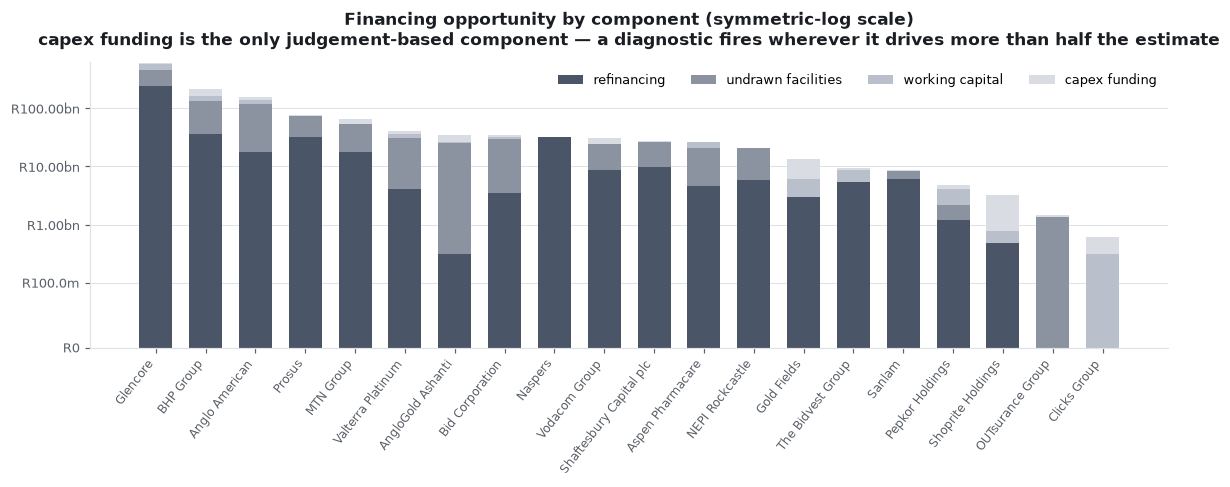

Clients where the judgement-based capex component drives more than half the lending estimate: 2 of 20 — each carries a `capex_judgement_dominates` diagnostic, and the component breakdown above lets a reviewer set that coefficient to zero and re-read the number.


In [46]:
fig, ax = plt.subplots(figsize=(11, 4.6))
plot = LENDING_COMP.sort_values("financing opportunity", ascending=False)
raw = COMPONENTS[COMPONENTS["product"] == "lending"].pivot_table(
    index="entity_id", columns="component", values="component_zar", aggfunc="first").fillna(0.0)
raw = raw.reindex(plot["id"])
bottom = np.zeros(len(raw))
shades = {"refinancing": "#4a5568", "undrawn_facilities": "#8b93a1",
          "working_capital": "#b9c0cb", "capex_funding": "#d9dde3"}
for component in ORDER:
    ax.bar(range(len(raw)), raw[component], bottom=bottom, width=0.66,
           color=shades[component], label=component.replace("_", " "))
    bottom += raw[component].to_numpy()
ax.set_xticks(range(len(raw)))
ax.set_xticklabels(plot["client"], rotation=52, ha="right", fontsize=8)
ax.set_yscale("symlog", linthresh=1e8); zar_axis(ax, "y")
ax.legend(ncols=4, loc="upper right")
ax.set_title("Financing opportunity by component (symmetric-log scale)\n"
             "capex funding is the only judgement-based component — a diagnostic fires "
             "wherever it drives more than half the estimate")
axis_style(ax)
plt.tight_layout(); plt.show()

capex_led = (raw["capex_funding"] / raw.sum(axis=1)).dropna()
print(f"Clients where the judgement-based capex component drives more than half the lending "
      f"estimate: {int((capex_led > 0.5).sum())} of 20 — each carries a "
      "`capex_judgement_dominates` diagnostic, and the component breakdown above lets a "
      "reviewer set that coefficient to zero and re-read the number.")

## The one *observed* competitor-credit signal

Everything above is a need inferred from disclosure. The `memo` field is different: it is
**observed evidence** of lending activity Syn Bank is not the lender on, visible in Syn Bank's
own transaction ledger. It is reported as a supporting signal on the lending narrative — never
converted into a rand estimate, because a settlement amount is not a facility size.

In [47]:
LENDING_EVIDENCE = FEATURES[["entity_id", "entity_name", "txn_memo_count_fy",
                             "named_lender_count", "undrawn_facilities_zar",
                             "committed_facilities_total_zar", "drawn_facilities_zar"]].copy()
LENDING_EVIDENCE = LENDING_EVIDENCE.merge(
    LENDING[["entity_id", "opportunity_zar"]], on="entity_id").sort_values(
        "txn_memo_count_fy", ascending=False)
LENDING_EVIDENCE.columns = ["id", "client", "competitor-lending memos (FY)", "lenders named",
                            "undrawn facilities", "committed facilities", "drawn facilities",
                            "financing opportunity"]
table(LENDING_EVIDENCE, "Observed competitor-credit evidence alongside the inferred need",
      money=["undrawn facilities", "committed facilities", "drawn facilities",
             "financing opportunity"],
      counts=["competitor-lending memos (FY)", "lenders named"])

**Observed competitor-credit evidence alongside the inferred need**

id,client,competitor-lending memos (FY),lenders named,undrawn facilities,committed facilities,drawn facilities,financing opportunity
E10,Bid Corporation,286,14,R26.40bn,n/a,n/a,R34.02bn
E16,MTN Group,258,1,R35.95bn,n/a,n/a,R65.25bn
E09,Shoprite Holdings,250,n/a,n/a,n/a,n/a,R3.17bn
E19,Aspen Pharmacare,111,n/a,R15.90bn,R52.02bn,R36.12bn,R26.62bn
E18,The Bidvest Group,101,n/a,n/a,n/a,n/a,R9.39bn
E14,Prosus,69,n/a,R42.74bn,R42.74bn,R0,R74.80bn
E05,Gold Fields,34,n/a,n/a,n/a,n/a,R13.48bn
E15,Naspers,27,n/a,n/a,n/a,n/a,R32.19bn
E04,AngloGold Ashanti,25,n/a,R24.40bn,R29.33bn,R4.93bn,R35.08bn
E02,Glencore,25,n/a,R214.11bn,R220.50bn,R6.39bn,R596.26bn


---

# 11. Pillar 5 — Investment Banking / Capital Markets  ·  `SIGNAL_ONLY`  ·  **no rand, no share**

Nothing in the supplied data indicates a planned issue, disposal or acquisition. There is no
deal record, no mandate log, and no pipeline. Sizing an investment-banking wallet from a
balance sheet would be pure invention, so the engine **estimates no rand amount at all** and
publishes a ranked signal and a mandate category instead.

```
signal_score = 0.20 scale + 0.25 leverage + 0.25 near_term_maturity
             + 0.20 capex_intensity + 0.10 syndicate_breadth
               (each a percentile rank inside this portfolio)

addressable_zar = NULL      opportunity_zar = NULL      share = NULL
```

A mandate **category** is assigned only when a disclosed threshold is met — otherwise none is
assigned, and the model says so.

In [48]:
IB = ENGINE[ENGINE["product"] == "investment_banking"].copy()
for column in ("observed_zar", "addressable_zar", "opportunity_zar", "share"):
    assert IB[column].isna().all(), f"investment banking must publish NULL {column}"
print("✓ observed_zar, addressable_zar, opportunity_zar and share are NULL for all 20 clients")
print("  NULL, never zero: 'we cannot size this' and 'this is worth nothing' are opposite "
      "statements, and a fillna(0) anywhere downstream would merge them.\n")

table(ASSUMPTIONS[ASSUMPTIONS["product"] == "investment_banking"][
          ["name", "value", "unit", "basis", "rationale"]],
      "The four disclosed thresholds that can trigger a mandate category")

✓ observed_zar, addressable_zar, opportunity_zar and share are NULL for all 20 clients
  NULL, never zero: 'we cannot size this' and 'this is worth nothing' are opposite statements, and a fillna(0) anywhere downstream would merge them.



**The four disclosed thresholds that can trigger a mandate category**

name,value,unit,basis,rationale
ib_near_term_maturity_threshold,0.300000,fraction of gross debt,judgement,"A debt capital markets category is only assigned when at least 30% of gross debt is classified current. Below that, a near-term refinancing mandate is not supported by the disclosure."
ib_capex_intensity_threshold,0.100000,capex / revenue,judgement,"A corporate finance / project funding category is only assigned above a 10% capex intensity, the level at which an investment programme is large enough to need external structuring."
ib_leverage_threshold,0.500000,net debt / revenue,judgement,A refinancing or restructuring category needs leverage above half of annual revenue alongside an elevated cost of debt; below it the balance sheet does not indicate stress.
ib_cost_of_debt_threshold,0.090000,finance costs / gross debt,judgement,An implied blended cost of debt above 9% is elevated against the South African policy rate over the reporting window and supports a refinancing conversation.


In [49]:
IB_VIEW = IB[["entity_id", "entity_name", "sector", "signal_score", "confidence",
              "confidence_band"]].merge(
    PROFILE[["entity_id", "ib_opportunity_type"]], on="entity_id")
IB_VIEW = IB_VIEW.merge(FEATURES[[
    "entity_id", "debt_to_revenue", "net_debt_to_revenue", "capex_to_revenue",
    "finance_costs_to_debt", "named_lender_count", "has_debt_maturity_disclosure"]],
    on="entity_id").sort_values("signal_score", ascending=False)
indexed = FEATURES.set_index("entity_id")
current = indexed.loc[IB_VIEW["entity_id"], "debt_current_zar"].to_numpy()
gross = indexed.loc[IB_VIEW["entity_id"], "gross_debt_zar"].to_numpy()
IB_VIEW["current debt / gross debt"] = np.divide(
    current, gross, out=np.full(len(current), np.nan), where=(gross > 0))
IB_VIEW = IB_VIEW[["entity_id", "entity_name", "sector", "signal_score", "ib_opportunity_type",
                   "confidence_band", "net_debt_to_revenue", "current debt / gross debt",
                   "capex_to_revenue", "finance_costs_to_debt", "named_lender_count"]]
IB_VIEW.columns = ["id", "client", "sector", "signal score", "mandate category", "band",
                   "net debt / revenue", "current / gross debt", "capex / revenue",
                   "implied cost of debt", "lenders named"]
table(IB_VIEW, "Investment Banking — a ranked signal, a category, and the disclosed "
               "indicators behind them. No rand figure appears, by design.",
      decimals=["signal score", "net debt / revenue", "current / gross debt",
                "capex / revenue", "implied cost of debt"],
      counts=["lenders named"])

categories = IB_VIEW["mandate category"].fillna("no category supported").value_counts()
print("Mandate categories assigned: " + ", ".join(f"{k} — {v}" for k, v in categories.items()))

**Investment Banking — a ranked signal, a category, and the disclosed indicators behind them. No rand figure appears, by design.**

id,client,sector,signal score,mandate category,band,net debt / revenue,current / gross debt,capex / revenue,implied cost of debt,lenders named
E20,Shaftesbury Capital plc,real_estate,0.746,corporate_finance,LOW,3.368,0.362,0.474,0.045,n/a
E02,Glencore,mining,0.700,debt_capital_markets,MEDIUM,0.145,0.349,0.028,0.071,n/a
E16,MTN Group,telecoms,0.677,corporate_finance,LOW,0.122,0.252,0.170,0.234,1
E01,BHP Group,mining,0.649,corporate_finance,LOW,0.241,0.082,0.191,0.046,n/a
E03,Anglo American,mining,0.639,corporate_finance,LOW,0.453,0.069,0.178,0.047,n/a
E10,Bid Corporation,consumer,0.608,advisory,LOW,0.026,0.195,0.026,0.035,14
E15,Naspers,tech,0.568,none_supported,MEDIUM,0.954,0.107,0.011,0.040,n/a
E14,Prosus,tech,0.564,none_supported,MEDIUM,1.052,0.108,0.010,0.038,n/a
E13,NEPI Rockcastle,real_estate,0.564,advisory,MEDIUM,2.834,0.100,0.072,0.036,6
E17,Vodacom Group,telecoms,0.562,corporate_finance,LOW,0.368,0.095,0.141,0.090,n/a


Mandate categories assigned: none_supported — 8, corporate_finance — 7, debt_capital_markets — 3, advisory — 2


---

# 12. Confidence

A computed score, not a label somebody chose. Four factors describe how good the **inputs**
are and combine **additively**. A fifth — `evidence_directness`, how sound the **method** is —
then **multiplies** that total.

## Input quality and method directness are different things, and the second is a ceiling

An earlier additive version of this score proved the point: it rated all twenty
investment-banking estimates HIGH — a pillar whose every threshold is an undrawn judgement —
purely because the balance-sheet fields behind it were fully disclosed. **Having every input a
model needs cannot make a weak model confident.** So directness multiplies rather than votes.

In [50]:
WEIGHTS = pd.DataFrame([
    ("input_completeness", confidence_module.WEIGHTS["input_completeness"], "additive",
     "Fraction of the pillar's economic drivers the client actually disclosed, rather than "
     "being imputed from peers."),
    ("sector_applicability", confidence_module.WEIGHTS["sector_applicability"], "additive",
     "Whether the model's economic logic applies to this sector at all — an insurer scored "
     "for import letters of credit should not read as confident."),
    ("observation_support", confidence_module.WEIGHTS["observation_support"], "additive",
     "How much internal activity backs the estimate, log-scaled against the busiest client "
     "in the pillar. Thin observation is a thin basis for a share."),
    ("internal_consistency", confidence_module.WEIGHTS["internal_consistency"], "additive",
     "Whether related disclosures agree: the gross-debt identity, the revenue split, and "
     "whether the revenue denominator is as-reported or constructed."),
    ("evidence_directness", None, "MULTIPLICATIVE",
     "How far the METHOD sits from an accounting identity. Identity 1.00 · structural 0.90 · "
     "peer benchmark 0.60 · judgement 0.35. Scaled down further when a component could not "
     "be built, and halved when the wallet had to be floored at observed activity."),
], columns=["factor", "weight", "combines", "what it measures"])
table(WEIGHTS, "confidence = (Σ additive factors × weight) × evidence_directness",
      decimals=["weight"])

print("Basis directness: " + " · ".join(
    f"{k} {v:.2f}" for k, v in confidence_module.BASIS_DIRECTNESS.items()))
print(f"Floor penalty when the wallet had to be floored at observed activity: "
      f"{confidence_module.FLOOR_PENALTY:.0%}")
print(f"Bands: HIGH ≥ {assumptions.CONFIDENCE_BAND_HIGH:.2f} · "
      f"MEDIUM ≥ {assumptions.CONFIDENCE_BAND_MEDIUM:.2f} · LOW below")

**confidence = (Σ additive factors × weight) × evidence_directness**

factor,weight,combines,what it measures
input_completeness,0.350,additive,"Fraction of the pillar's economic drivers the client actually disclosed, rather than being imputed from peers."
sector_applicability,0.250,additive,Whether the model's economic logic applies to this sector at all — an insurer scored for import letters of credit should not read as confident.
observation_support,0.200,additive,"How much internal activity backs the estimate, log-scaled against the busiest client in the pillar. Thin observation is a thin basis for a share."
internal_consistency,0.200,additive,"Whether related disclosures agree: the gross-debt identity, the revenue split, and whether the revenue denominator is as-reported or constructed."
evidence_directness,n/a,MULTIPLICATIVE,"How far the METHOD sits from an accounting identity. Identity 1.00 · structural 0.90 · peer benchmark 0.60 · judgement 0.35. Scaled down further when a component could not be built, and halved when the wallet had to be floored at observed activity."


Basis directness: accounting_identity 1.00 · structural 0.90 · portfolio_benchmark 0.60 · judgement 0.35
Floor penalty when the wallet had to be floored at observed activity: 50%
Bands: HIGH ≥ 0.70 · MEDIUM ≥ 0.45 · LOW below


## The arithmetic, verified on the published detail table

In [51]:
DETAIL = load("wallet_confidence_detail").merge(
    ENGINE[["entity_id", "product", "entity_name"]], on=["entity_id", "product"])

recomputed = sum(DETAIL[factor] * weight
                 for factor, weight in confidence_module.WEIGHTS.items())
assert np.allclose(recomputed, DETAIL["input_quality"], atol=1e-9)
assert np.allclose(DETAIL["input_quality"] * DETAIL["evidence_directness"],
                   DETAIL["confidence"], atol=1e-9)
print("✓ recomputed from the four additive factors and their weights: input_quality matches")
print("✓ input_quality × evidence_directness == confidence, for all 100 estimates\n")

SAMPLE = DETAIL[DETAIL["entity_id"] == "E09"][
    ["entity_name", "product", "input_completeness", "sector_applicability",
     "observation_support", "internal_consistency", "input_quality", "evidence_directness",
     "confidence", "confidence_band"]]
SAMPLE.columns = ["client", "product", "completeness", "sector fit", "observation",
                  "consistency", "input quality", "× directness", "= confidence", "band"]
table(SAMPLE, "Shoprite Holdings across all five pillars — same client, same disclosures, "
              "five very different confidences, and directness is what separates them",
      decimals=["completeness", "sector fit", "observation", "consistency", "input quality",
                "× directness", "= confidence"])

✓ recomputed from the four additive factors and their weights: input_quality matches
✓ input_quality × evidence_directness == confidence, for all 100 estimates



**Shoprite Holdings across all five pillars — same client, same disclosures, five very different confidences, and directness is what separates them**

client,product,completeness,sector fit,observation,consistency,input quality,× directness,= confidence,band
Shoprite Holdings,cash_management,1.000,1.000,0.874,0.750,0.925,1.000,0.925,HIGH
Shoprite Holdings,fx_global_markets,0.667,1.000,0.898,0.750,0.813,0.600,0.488,MEDIUM
Shoprite Holdings,trade_finance,1.000,1.000,0.939,0.750,0.938,0.600,0.563,MEDIUM
Shoprite Holdings,lending,0.750,1.000,0.912,1.000,0.895,0.343,0.307,LOW
Shoprite Holdings,investment_banking,1.000,1.000,0.912,0.750,0.932,0.350,0.326,LOW


## Portfolio confidence by product

> **The confidence spread is the model's most important finding about itself.** Cash management
> averages 0.86 with 80% HIGH because it rests on identities. FX and trade average 0.35 and
> 0.34 with 70% and 85% LOW, because they rest on peer coefficients applied to partly imputed
> drivers. **A dashboard that shows the FX rand figure at the same visual weight as the cash
> rand figure is misrepresenting the model**, which is why the range mark and the confidence
> band travel with every estimate.

**Product confidence summary**

pillar,class,mean,median,% HIGH,% MEDIUM,% LOW,% with a HIGH-severity flag
Transactional / Cash Management,CORE,0.860,0.925,80.00%,20.00%,0.00%,10.00%
FX / Global Markets,CORE,0.345,0.393,0.00%,30.00%,70.00%,30.00%
Trade Finance,CORE,0.337,0.335,0.00%,15.00%,85.00%,25.00%
Lending,SUPPORTING,0.607,0.611,30.00%,55.00%,15.00%,10.00%
Investment Banking / Capital Markets,SIGNAL_ONLY,0.382,0.397,0.00%,25.00%,75.00%,0.00%


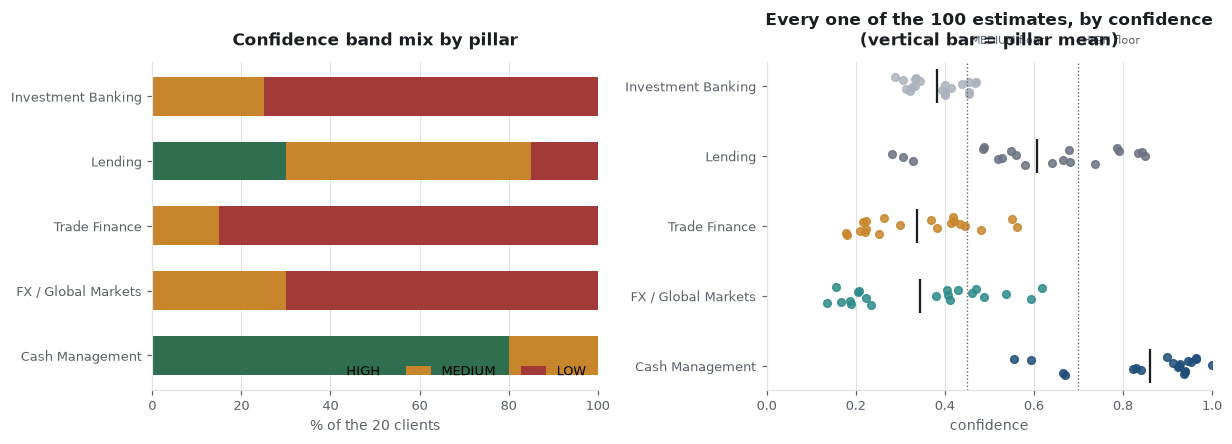

In [52]:
CONF = load("product_confidence")
CONF_VIEW = CONF[["product_label", "product_class", "mean_confidence", "median_confidence",
                  "pct_high", "pct_medium", "pct_low", "pct_major_diagnostic"]]
CONF_VIEW.columns = ["pillar", "class", "mean", "median", "% HIGH", "% MEDIUM", "% LOW",
                     "% with a HIGH-severity flag"]
table(CONF_VIEW, "Product confidence summary",
      decimals=["mean", "median"],
      percent=["% HIGH", "% MEDIUM", "% LOW", "% with a HIGH-severity flag"])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
order = CONF.set_index("product").reindex(PILLARS)
y = np.arange(len(order))
left = np.zeros(len(order))
for band, column in (("HIGH", "pct_high"), ("MEDIUM", "pct_medium"), ("LOW", "pct_low")):
    axes[0].barh(y, order[column] * 100, left=left, height=0.6,
                 color=CONFIDENCE_COLOUR[band], label=band)
    left += order[column].to_numpy() * 100
axes[0].set_yticks(y); axes[0].set_yticklabels([SHORT[p] for p in order.index], fontsize=8.5)
axes[0].set_xlim(0, 100); axes[0].set_xlabel("% of the 20 clients")
axes[0].legend(ncols=3, loc="lower right")
axes[0].set_title("Confidence band mix by pillar")
axis_style(axes[0], xgrid=True, ygrid=False)

for index, product in enumerate(PILLARS):
    values = ENGINE.loc[ENGINE["product"] == product, "confidence"]
    axes[1].scatter(values, np.full(len(values), index) + np.linspace(-0.13, 0.13, len(values)),
                    color=PILLAR_COLOUR[product], s=26, alpha=0.85)
    axes[1].scatter([values.mean()], [index], marker="|", s=520, color=INK, zorder=4)
for threshold, label in ((assumptions.CONFIDENCE_BAND_MEDIUM, "MEDIUM"),
                         (assumptions.CONFIDENCE_BAND_HIGH, "HIGH")):
    axes[1].axvline(threshold, color=MUTED, ls=":", lw=0.9)
    axes[1].text(threshold, len(PILLARS) - 0.4, f" {label} floor", fontsize=7.5, color=MUTED)
axes[1].set_yticks(range(len(PILLARS)))
axes[1].set_yticklabels([SHORT[p] for p in PILLARS], fontsize=8.5)
axes[1].set_xlim(0, 1); axes[1].set_xlabel("confidence")
axes[1].set_title("Every one of the 100 estimates, by confidence\n(vertical bar = pillar mean)")
axis_style(axes[1], xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

## Product classification is measured at build time, not hardcoded

```
no rand estimate for anybody           → SIGNAL_ONLY
rand estimate but no computable share  → SUPPORTING
share computable for ≥ 50% of clients  → CORE
```

A future run in which the lending data gained an observed numerator would reclassify itself
rather than silently contradict a dashboard.

In [53]:
CLASSIFICATION = load("product_classification")
table(CLASSIFICATION[["product_label", "pillar_role", "product_class", "clients_with_estimate",
                      "clients_with_observed", "clients_with_share", "classification_reason"]],
      "Product classification, assigned by measurement",
      counts=["clients_with_estimate", "clients_with_observed", "clients_with_share"])

**Product classification, assigned by measurement**

product_label,pillar_role,product_class,clients_with_estimate,clients_with_observed,clients_with_share,classification_reason
Transactional / Cash Management,share_of_wallet,CORE,20,20,20,"A share of wallet is computable for 20 of 20 clients (100%), from an observed numerator present for 20. Share can be shown as a headline number."
FX / Global Markets,share_of_wallet,CORE,20,20,20,"A share of wallet is computable for 20 of 20 clients (100%), from an observed numerator present for 20. Share can be shown as a headline number."
Trade Finance,share_of_wallet,CORE,20,20,20,"A share of wallet is computable for 20 of 20 clients (100%), from an observed numerator present for 20. Share can be shown as a headline number."
Lending,opportunity_signal,SUPPORTING,20,0,0,"A rand estimate exists for 20 of 20 clients (100%) but a share is computable for only 0, because the supplied data carries no observed numerator for this product. Show the rand amount as an opportunity indicator, never as a share."
Investment Banking / Capital Markets,opportunity_signal,SIGNAL_ONLY,0,0,0,"No rand estimate is produced for any client, so there is nothing to show as a currency figure. Publish the ranked signal and the category only."


---

# 13. Opportunity ranking — two questions, two answers

Bankers ask two different questions and they have different answers. **The two rankings
disagree, and they are meant to. Show both; never average them.**

### A. Commercial Opportunity Score — *where is the largest opportunity?*

```
commercial_opportunity_score = 0.45 × gap_percentile_within_product
                             + 0.30 × confidence
                             + 0.25 × (1 − share)          ← commercial headroom
```

Percentile rather than raw rand, so a trillion-rand revenue base cannot dominate on scale
alone and the five different estimate bases stay comparable. Confidence sits *inside* the score
so a large opportunity resting on an imputed denominator ranks below a smaller one built from
disclosures. Headroom is neutral at 0.5 where no share exists, rather than rewarding or
penalising a number that does not exist.

### B. Opportunity Intensity — *where are we most obviously absent?*

```
opportunity_intensity = opportunity_zar / addressable_cash_flow_zar
```

**No weights and no fitted coefficients at all.** One denominator per client — the client's own
addressable cash flow — which is identity-anchored, available for all twenty, and identical
across the five pillars, so a client's five intensities are directly comparable to each other.
This is what lets a small company with a proportionally enormous gap outrank a giant with a
proportionally small one, which a within-product percentile cannot do.

In [54]:
table(ASSUMPTIONS[ASSUMPTIONS["name"].str.startswith("opportunity_")][
          ["name", "value", "unit", "basis", "rationale"]],
      "The ranking weights, from the production registry", decimals=["value"])

TOP_COMMERCIAL = ENGINE.sort_values("commercial_rank").head(15)[
    ["commercial_rank", "entity_name", "product", "commercial_opportunity_score",
     "opportunity_zar", "share", "confidence_band", "high_severity_diagnostic"]]
TOP_COMMERCIAL.columns = ["#", "client", "pillar", "score", "opportunity", "share", "band",
                          "HIGH flag"]
table(TOP_COMMERCIAL, "A · Top 15 by Commercial Opportunity Score — *where is the largest "
                      "opportunity?*",
      money=["opportunity"], percent=["share"], decimals=["score"], counts=["#"])

TOP_INTENSITY = ENGINE[ENGINE["opportunity_intensity"].notna()].sort_values(
    "intensity_rank").head(15)[
    ["intensity_rank", "entity_name", "product", "opportunity_intensity", "opportunity_zar",
     "addressable_cash_flow_zar", "confidence_band", "commercial_rank"]]
TOP_INTENSITY.columns = ["#", "client", "pillar", "intensity", "opportunity",
                         "client's cash flow", "band", "commercial rank"]
table(TOP_INTENSITY, "B · Top 15 by Opportunity Intensity — *where are we most obviously "
                     "absent?*",
      money=["opportunity", "client's cash flow"], decimals=["intensity"],
      counts=["#", "commercial rank"])

**The ranking weights, from the production registry**

name,value,unit,basis,rationale
opportunity_weight_gap,0.450,weight,judgement,"Weight on the within-product percentile rank of the rand gap. Percentile rather than raw rand so that a client with a trillion-rand revenue base cannot dominate on scale alone, and so products with different estimate bases stay comparable."
opportunity_weight_confidence,0.300,weight,judgement,Weight on model confidence. Large opportunities resting on imputed denominators are pushed down the ranking rather than silently promoted.
opportunity_weight_headroom,0.250,weight,judgement,"Weight on commercial headroom (1 - share). A client where Syn Bank already handles most of the addressable activity is a retention conversation, not a growth opportunity."
opportunity_intensity_denominator,n/a,addressable cash flow,accounting_identity,"Opportunity intensity divides a product's rand gap by the client's OWN addressable cash flow (revenue + cost of sales). One denominator per client, identity-anchored and available for all twenty, so the five products share a common scale and the metric carries no fitted coefficient at all. It is a ratio, not a weighted index."


**A · Top 15 by Commercial Opportunity Score — *where is the largest opportunity?***

#,client,pillar,score,opportunity,share,band,HIGH flag
1,Glencore,cash_management,0.981,R8.75tn,0.03%,HIGH,False
2,Shoprite Holdings,cash_management,0.908,R443.98bn,0.88%,HIGH,False
3,Bid Corporation,cash_management,0.885,R409.26bn,1.03%,HIGH,False
4,BHP Group,cash_management,0.877,R1.51tn,0.61%,MEDIUM,True
5,Anglo American,cash_management,0.852,R536.14bn,0.89%,MEDIUM,True
6,Naspers,cash_management,0.848,R292.13bn,0.18%,HIGH,False
7,AngloGold Ashanti,cash_management,0.801,R265.70bn,0.38%,HIGH,False
8,Glencore,lending,0.796,R596.26bn,n/a,HIGH,False
9,Prosus,cash_management,0.782,R257.73bn,0.29%,HIGH,False
10,Glencore,trade_finance,0.772,R71.96bn,1.41%,LOW,True


**B · Top 15 by Opportunity Intensity — *where are we most obviously absent?***

#,client,pillar,intensity,opportunity,client's cash flow,band,commercial rank
1,Shaftesbury Capital plc,lending,3.865,R27.32bn,R7.07bn,MEDIUM,67
2,NEPI Rockcastle,lending,1.109,R20.67bn,R18.64bn,HIGH,49
3,Valterra Platinum,cash_management,1.000,R204.06bn,R204.10bn,HIGH,27
4,Glencore,cash_management,1.000,R8.75tn,R8.75tn,HIGH,1
5,Vodacom Group,cash_management,0.999,R278.56bn,R278.72bn,MEDIUM,25
6,Shaftesbury Capital plc,cash_management,0.998,R7.06bn,R7.07bn,HIGH,52
7,Clicks Group,cash_management,0.998,R84.12bn,R84.26bn,HIGH,34
8,NEPI Rockcastle,cash_management,0.998,R18.61bn,R18.64bn,HIGH,43
9,Naspers,cash_management,0.998,R292.13bn,R292.67bn,HIGH,6
10,OUTsurance Group,cash_management,0.997,R65.61bn,R65.80bn,HIGH,46


> ### The intensity leaderboard is dominated by cash, and that is a property of the metric
> For the cash pillar the ratio reduces to `1 − share` exactly, and Syn Bank's cash share is
> under half a percent for every client, so every cash row scores 0.91–1.00. **The
> discrimination lives *within* each pillar** — use `intensity_rank_in_product`, or filter to
> one pillar. The rows that beat cash are the genuine cross-pillar signals.

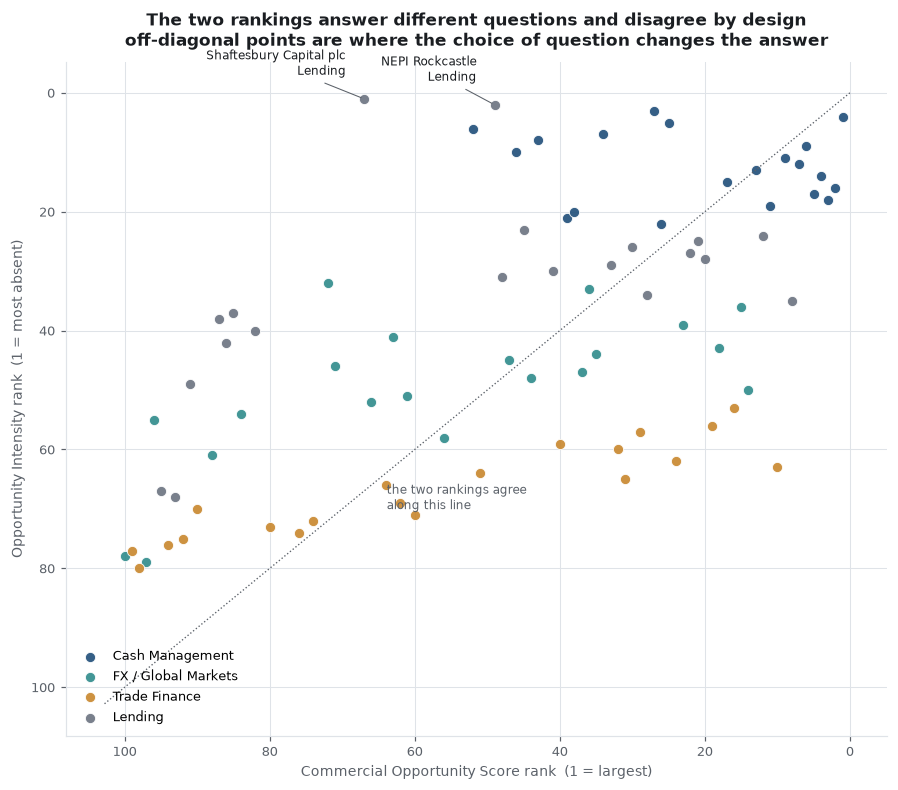

**Where they disagree most**

client,pillar,commercial rank,intensity rank,opportunity,intensity,band
Shaftesbury Capital plc,lending,67,1,R27.32bn,3.865,MEDIUM
Glencore,trade_finance,10,63,R71.96bn,0.008,LOW
Gold Fields,lending,87,38,R13.48bn,0.061,LOW
Sanlam,lending,85,37,R8.48bn,0.065,MEDIUM
NEPI Rockcastle,lending,49,2,R20.67bn,1.109,HIGH
Shaftesbury Capital plc,cash_management,52,6,R7.06bn,0.998,HIGH
Pepkor Holdings,lending,86,42,R4.79bn,0.031,MEDIUM
OUTsurance Group,lending,91,49,R1.46bn,0.022,MEDIUM


In [55]:
fig, ax = plt.subplots(figsize=(8.4, 7.4))
scored = ENGINE[ENGINE["intensity_rank"].notna()].copy()
for product in PILLARS:
    rows = scored[scored["product"] == product]
    if rows.empty:
        continue
    ax.scatter(rows["commercial_rank"], rows["intensity_rank"], s=46,
               color=PILLAR_COLOUR[product], label=SHORT[product], alpha=0.9,
               edgecolor="white", linewidth=0.6)
limit = max(scored["commercial_rank"].max(), scored["intensity_rank"].max()) + 3
ax.plot([0, limit], [0, limit], color=MUTED, ls=":", lw=0.9)
ax.text(limit * 0.62, limit * 0.68, "the two rankings agree\nalong this line", fontsize=8,
        color=MUTED)
for _, row in scored.nsmallest(2, "intensity_rank").iterrows():
    ax.annotate(f"{row['entity_name']}\n{SHORT[row['product']]}",
                (row["commercial_rank"], row["intensity_rank"]),
                textcoords="offset points", xytext=(-12, 16), fontsize=8, color=INK,
                ha="right",
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.7))
ax.set_xlabel("Commercial Opportunity Score rank  (1 = largest)")
ax.set_ylabel("Opportunity Intensity rank  (1 = most absent)")
ax.set_title("The two rankings answer different questions and disagree by design\n"
             "off-diagonal points are where the choice of question changes the answer")
ax.invert_xaxis(); ax.invert_yaxis()
ax.legend(loc="lower left")
axis_style(ax, xgrid=True, ygrid=True)
plt.tight_layout(); plt.show()

DISAGREE = scored.assign(swing=(scored["commercial_rank"] - scored["intensity_rank"]).abs())
DISAGREE = DISAGREE.nlargest(8, "swing")[
    ["entity_name", "product", "commercial_rank", "intensity_rank", "opportunity_zar",
     "opportunity_intensity", "confidence_band"]]
DISAGREE.columns = ["client", "pillar", "commercial rank", "intensity rank", "opportunity",
                    "intensity", "band"]
table(DISAGREE, "Where they disagree most", money=["opportunity"], decimals=["intensity"],
      counts=["commercial rank", "intensity rank"])

**Shaftesbury Capital's lending position is the metric earning its place.** Its financing need
is 3.86× its entire annual operating cash flow — the most disproportionate position in the
portfolio — and the commercial score buries it in the sixties because the rand amount is small
next to Glencore's. Both rankings are right about different questions, and a banker with only
one of them would miss one of the two clients.

### Intensity within each pillar, where the metric discriminates

In [56]:
WITHIN = (ENGINE[ENGINE["intensity_rank_in_product"].notna()]
          .sort_values(["product", "intensity_rank_in_product"])
          .groupby("product").head(4)[
              ["product", "intensity_rank_in_product", "entity_name", "opportunity_intensity",
               "opportunity_zar", "confidence_band"]])
WITHIN.columns = ["pillar", "#", "client", "intensity", "opportunity", "band"]
table(WITHIN, "Top 4 by intensity WITHIN each pillar — the prioritisation view",
      money=["opportunity"], decimals=["intensity"], counts=["#"])

**Top 4 by intensity WITHIN each pillar — the prioritisation view**

pillar,#,client,intensity,opportunity,band
cash_management,1,Valterra Platinum,1.000,R204.06bn,HIGH
cash_management,2,Glencore,1.000,R8.75tn,HIGH
cash_management,3,Vodacom Group,0.999,R278.56bn,MEDIUM
cash_management,4,Shaftesbury Capital plc,0.998,R7.06bn,HIGH
fx_global_markets,1,NEPI Rockcastle,0.108,R2.01bn,MEDIUM
fx_global_markets,2,Aspen Pharmacare,0.083,R5.63bn,MEDIUM
fx_global_markets,3,Valterra Platinum,0.066,R13.41bn,LOW
fx_global_markets,4,MTN Group,0.047,R17.59bn,LOW
lending,1,Shaftesbury Capital plc,3.865,R27.32bn,MEDIUM
lending,2,NEPI Rockcastle,1.109,R20.67bn,HIGH


> **There is no cross-pillar rand total, anywhere.** Not in this notebook, not in the contract,
> not on the dashboard. The five rand figures are not commensurable: two overlap by an
> unresolvable amount (SWIFT), one is a fee-free flow identity, two are peer-benchmarked
> exposures, and one is a financing need with no observed side at all. §15 shows the build-time
> assertion that enforces it.

---

# 14. Sensitivity analysis

**This is the section that decides how much of the rest of the notebook you should believe.**

The engine was rebuilt **36 times**, end to end, under every combination of four choices —
not perturbed, not approximated, rebuilt. Each run produced a full set of 100 estimates, and
the sweep measures what moved.

In [57]:
SENS_SUMMARY = load("model_sensitivity_summary")
SCENARIO_GRID = pd.DataFrame([
    ("benchmark_percentile", "median (0.50) · P75 (0.75) · P80 (0.80)",
     "The peer statistic that defines a well-penetrated peer. The published model uses P75."),
    ("leave_one_out", "True · False",
     "Whether the client being estimated is excluded from the population that sets its own "
     "coefficient. The published model excludes it."),
    ("benchmark_scope", "sector_preferred · portfolio_only",
     "Whether a sector benchmark may be formed at all. The published model prefers sector "
     "with a portfolio fallback."),
    ("capex_debt_funded_share", "0.20 · 0.30 · 0.40",
     "The one underived coefficient in the engine. The published model uses 0.30."),
], columns=["knob", "values tested", "what it decides"])
table(SCENARIO_GRID, f"The scenario grid — 3 × 2 × 2 × 3 = {len(SENS_SUMMARY)} full model runs")

SCEN = load("model_sensitivity")
print(f"{len(SENS_SUMMARY)} scenarios × {SCEN.groupby('scenario').size().iloc[0]} estimates "
      f"= {len(SCEN):,} rows of sensitivity output")
print(f"Base scenario: {SENS_SUMMARY.loc[SENS_SUMMARY['is_base'], 'scenario'].iloc[0]}")

**The scenario grid — 3 × 2 × 2 × 3 = 36 full model runs**

knob,values tested,what it decides
benchmark_percentile,median (0.50) · P75 (0.75) · P80 (0.80),The peer statistic that defines a well-penetrated peer. The published model uses P75.
leave_one_out,True · False,Whether the client being estimated is excluded from the population that sets its own coefficient. The published model excludes it.
benchmark_scope,sector_preferred · portfolio_only,Whether a sector benchmark may be formed at all. The published model prefers sector with a portfolio fallback.
capex_debt_funded_share,0.20 · 0.30 · 0.40,The one underived coefficient in the engine. The published model uses 0.30.


36 scenarios × 100 estimates = 3,600 rows of sensitivity output
Base scenario: p75_loo_sector_capex30


## 14.1 The verdict, per pillar

In [58]:
ROBUST = load("model_sensitivity_robustness")
ROBUST_VIEW = ROBUST[["product_label", "scenarios_tested", "min_spearman_rank_in_product",
                      "max_abs_total_gap_drift", "verdict", "worst_scenario"]]
ROBUST_VIEW.columns = ["pillar", "scenarios", "worst rank correlation (Spearman)",
                       "worst total drift", "verdict", "worst scenario"]
table(ROBUST_VIEW, "Robustness verdict — computed by the sweep, not asserted. "
                    "`scenarios` is 35 because each alternative is compared against the base "
                    "run, which cannot be compared with itself.",
      counts=["scenarios"], decimals=["worst rank correlation (Spearman)"],
      percent=["worst total drift"])

BY_PRODUCT = load("model_sensitivity_by_product")
SPAN = BY_PRODUCT.groupby(["product", "product_label"], as_index=False).agg(
    lowest=("total_gap_zar", "min"), highest=("total_gap_zar", "max"))
SPAN["ratio"] = SPAN["highest"] / SPAN["lowest"]
SPAN = SPAN.set_index("product").reindex(PILLARS).reset_index().dropna(subset=["product_label"])
SPAN_VIEW = SPAN[["product_label", "lowest", "highest", "ratio"]]
SPAN_VIEW.columns = ["pillar", "lowest across 36 runs", "highest across 36 runs", "ratio"]
table(SPAN_VIEW, "Portfolio OPPORTUNITY total, across the whole grid",
      money=["lowest across 36 runs", "highest across 36 runs"], decimals=["ratio"])

**Robustness verdict — computed by the sweep, not asserted. `scenarios` is 35 because each alternative is compared against the base run, which cannot be compared with itself.**

pillar,scenarios,worst rank correlation (Spearman),worst total drift,verdict,worst scenario
Transactional / Cash Management,35,1.000,0.00%,ROBUST,median_loo_sector_capex20
FX / Global Markets,35,0.510,76.69%,ASSUMPTION_SENSITIVE,median_self_included_sector_capex20
Trade Finance,35,0.848,66.13%,ASSUMPTION_SENSITIVE,median_self_included_portfolio_capex20
Lending,35,0.997,4.75%,ROBUST,median_loo_sector_capex20
Investment Banking / Capital Markets,35,1.000,n/a,NO_RAND_MAGNITUDE_ORDERING_ROBUST,median_loo_sector_capex20
"Portfolio, every product",35,0.884,2.40%,SEE_PER_PRODUCT,median_self_included_portfolio_capex20


**Portfolio OPPORTUNITY total, across the whole grid**

pillar,lowest across 36 runs,highest across 36 runs,ratio
Transactional / Cash Management,R14.25tn,R14.25tn,1.000
FX / Global Markets,R78.37bn,R583.70bn,7.448
Trade Finance,R39.28bn,R157.64bn,4.014
Lending,R1.32tn,R1.44tn,1.090
Investment Banking / Capital Markets,n/a,n/a,n/a


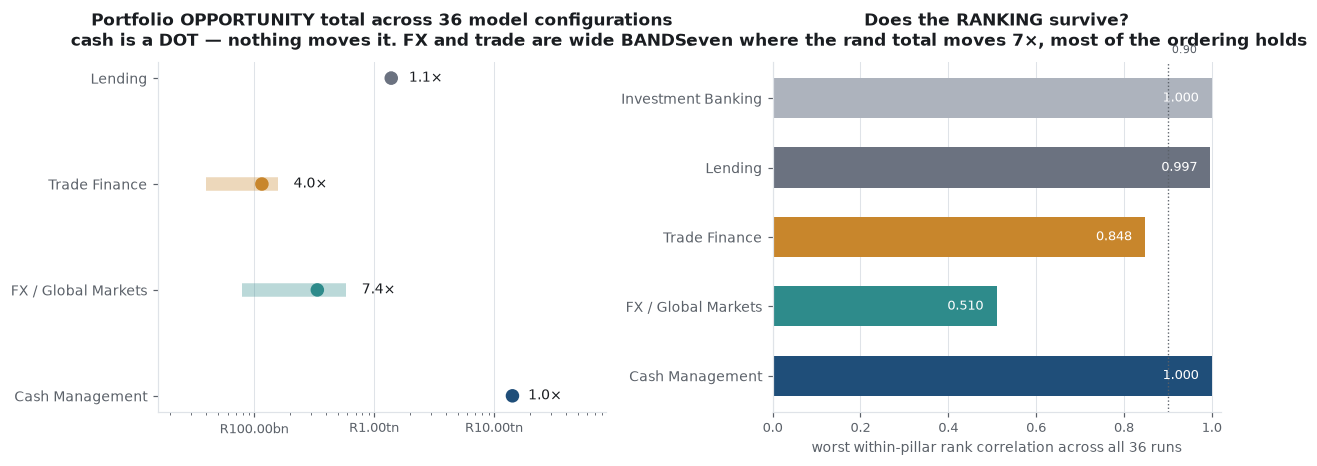

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

plot = SPAN.dropna(subset=["lowest"])
y = np.arange(len(plot))
axes[0].hlines(y, plot["lowest"], plot["highest"],
               color=[PILLAR_COLOUR[p] for p in plot["product"]], lw=9, alpha=0.32)
base_totals = BY_PRODUCT[BY_PRODUCT["scenario"] ==
                         SENS_SUMMARY.loc[SENS_SUMMARY["is_base"], "scenario"].iloc[0]]
base_totals = base_totals.set_index("product")["total_gap_zar"]
axes[0].scatter(base_totals.reindex(plot["product"]).to_numpy(), y,
                color=[PILLAR_COLOUR[p] for p in plot["product"]], s=64, zorder=3)
for index, (low, high, ratio) in enumerate(zip(plot["lowest"], plot["highest"], plot["ratio"])):
    axes[0].text(high * 1.35, index, f"{ratio:.1f}×", va="center", fontsize=9, color=INK)
axes[0].set_yticks(y); axes[0].set_yticklabels([SHORT[p] for p in plot["product"]], fontsize=9)
axes[0].set_xscale("log"); zar_axis(axes[0], "x")
axes[0].set_xlim(plot["lowest"].min() * 0.4, plot["highest"].max() * 6)
axes[0].set_title("Portfolio OPPORTUNITY total across 36 model configurations\n"
                  "cash is a DOT — nothing moves it. FX and trade are wide BANDS.")
axis_style(axes[0], xgrid=True, ygrid=False)

order = ROBUST[ROBUST["product"] != "ALL"].set_index("product").reindex(PILLARS)
y = np.arange(len(order))
axes[1].barh(y, order["min_spearman_rank_in_product"], height=0.58,
             color=[PILLAR_COLOUR[p] for p in order.index])
axes[1].axvline(0.9, color=MUTED, ls=":", lw=0.9)
axes[1].text(0.9, len(order) - 0.35, " 0.90", fontsize=7.5, color=MUTED)
axes[1].set_yticks(y); axes[1].set_yticklabels([SHORT[p] for p in order.index], fontsize=9)
axes[1].set_xlim(0, 1.02)
axes[1].set_xlabel("worst within-pillar rank correlation across all 36 runs")
axes[1].set_title("Does the RANKING survive?\n"
                  "even where the rand total moves 7×, most of the ordering holds")
for index, value in enumerate(order["min_spearman_rank_in_product"]):
    axes[1].text(value - 0.03, index, f"{value:.3f}", va="center", ha="right", fontsize=8.5,
                 color="white")
axis_style(axes[1], xgrid=True, ygrid=False)
plt.tight_layout(); plt.show()

## 14.2 What this means for each pillar

| Pillar | Verdict | What you may quote |
|---|---|---|
| **Transactional / Cash Management** | `ROBUST` | The rand figure. Both coefficients are accounting identities, so **no scenario in the grid moves it at all** — 0% drift, rank correlation 1.000, opportunity total R14.25tn in every run. |
| **Lending** | `ROBUST` | The rand figure, with the capex component named. Rank correlation ≥ 0.997, under 5% drift even when the one judgement coefficient moves by a third in either direction. |
| **FX / Global Markets** | `ASSUMPTION_SENSITIVE` | The **rank** and the **range**. The portfolio opportunity total spans **7.4×** (R78.37bn – R583.70bn); the denominator *is* the coefficient. Never a point estimate. |
| **Trade Finance** | `ASSUMPTION_SENSITIVE` | The **rank** and the **range**. The portfolio opportunity total spans **4.0×** (R39.28bn – R157.64bn). |
| **Investment Banking** | `NO_RAND_MAGNITUDE_ORDERING_ROBUST` | The **ordering only** — there is no rand figure to be sensitive. Signal ordering is unchanged across all 36 runs. |

This is not a defect in FX and trade. It is the honest consequence of having **no disclosed
total for either activity**: with nothing to anchor to, the choice of peer statistic *is* the
answer. The engine's response is to publish the range, the rank stability and a
`sensitivity_flag` on every single estimate, and to change the wording of the generated
explanation when the flag is set.

In [60]:
STABILITY = SENSITIVITY.merge(ENGINE[["entity_id", "entity_name", "product"]],
                              on=["entity_id", "product"])
PIVOT = pd.crosstab(STABILITY["product"].map(SHORT), STABILITY["sensitivity_flag"])
PIVOT = PIVOT.reindex([SHORT[p] for p in PILLARS]).fillna(0).astype(int).reset_index()
PIVOT.columns.name = None
table(PIVOT, "Sensitivity flag on each of the 100 published estimates")

STABILITY_PIVOT = pd.crosstab(STABILITY["product"].map(SHORT), STABILITY["rank_stability"])
STABILITY_PIVOT = STABILITY_PIVOT.reindex(
    [SHORT[p] for p in PILLARS]).fillna(0).astype(int).reset_index()
STABILITY_PIVOT.columns.name = None
table(STABILITY_PIVOT, "Rank stability across the 36 runs — how far each estimate's within-"
                       "pillar rank moved")

TOP10 = SENS_SUMMARY["top10_overlap"]
print(f"Identity of the top ten opportunities: {int(TOP10.min())}–{int(TOP10.max())} of 10 "
      f"survive every one of the {len(SENS_SUMMARY)} scenarios "
      f"(mean {TOP10.mean():.1f}). The list a banker would actually work is stable even "
      "where the rand amounts on it are not.")

**Sensitivity flag on each of the 100 published estimates**

product,MODERATE,NOT_APPLICABLE,SENSITIVE,STABLE
Cash Management,0,0,0,20
FX / Global Markets,0,0,18,2
Trade Finance,1,0,17,2
Lending,5,0,3,12
Investment Banking,0,20,0,0


**Rank stability across the 36 runs — how far each estimate's within-pillar rank moved**

product,MODERATE,NOT_APPLICABLE,SENSITIVE,STABLE
Cash Management,0,0,0,20
FX / Global Markets,10,0,7,3
Trade Finance,13,0,2,5
Lending,0,0,0,20
Investment Banking,0,20,0,0


Identity of the top ten opportunities: 9–10 of 10 survive every one of the 36 scenarios (mean 9.7). The list a banker would actually work is stable even where the rand amounts on it are not.


## 14.3 Which knob does the damage

In [61]:
BASE_SCENARIO = SENS_SUMMARY.loc[SENS_SUMMARY["is_base"], "scenario"].iloc[0]
KNOBS = []
for knob in ("benchmark_percentile", "leave_one_out", "benchmark_scope",
             "capex_debt_funded_share"):
    for product in ("fx_global_markets", "trade_finance", "lending", "cash_management"):
        rows = BY_PRODUCT[BY_PRODUCT["product"] == product]
        spread = rows.groupby(knob)["total_gap_zar"].mean()
        KNOBS.append({"knob": knob, "pillar": SHORT[product],
                      "lowest setting mean": spread.min(), "highest setting mean": spread.max(),
                      "ratio": spread.max() / spread.min() if spread.min() else np.nan})
KNOB_TABLE = pd.DataFrame(KNOBS).pivot(index="knob", columns="pillar",
                                       values="ratio").reset_index()
KNOB_TABLE.columns.name = None
table(KNOB_TABLE, "Mean OPPORTUNITY total ratio (highest setting ÷ lowest setting) — how "
                  "much each knob moves each pillar, holding nothing else fixed",
      decimals=[c for c in KNOB_TABLE.columns if c != "knob"])
cash_ratios = KNOB_TABLE[SHORT["cash_management"]]
print(f"Cash Management moves by a factor of {cash_ratios.min():.3f}–{cash_ratios.max():.3f} on "
      "every knob: both of its coefficients are accounting identities, so there is nothing in "
      "the grid to turn.")
print("The benchmark percentile is the dominant lever on FX and trade, exactly as expected "
      "when the denominator IS the coefficient. The capex share is the dominant lever on "
      "lending, and the only knob that moves it by more than 1%.")

**Mean OPPORTUNITY total ratio (highest setting ÷ lowest setting) — how much each knob moves each pillar, holding nothing else fixed**

knob,Cash Management,FX / Global Markets,Lending,Trade Finance
benchmark_percentile,1.000,5.504,1.000,3.093
benchmark_scope,1.000,1.124,1.010,1.208
capex_debt_funded_share,1.000,1.000,1.079,1.000
leave_one_out,1.000,1.043,1.001,1.036


Cash Management moves by a factor of 1.000–1.000 on every knob: both of its coefficients are accounting identities, so there is nothing in the grid to turn.
The benchmark percentile is the dominant lever on FX and trade, exactly as expected when the denominator IS the coefficient. The capex share is the dominant lever on lending, and the only knob that moves it by more than 1%.


---

# 15. Portfolio results

Everything below is generated directly from the analytical contract.

In [62]:
PORTFOLIO = load("portfolio_summary").set_index("product").reindex(PILLARS).reset_index()
PORT_VIEW = PORTFOLIO[["product_label", "product_class", "estimate_basis", "total_observed_zar",
                       "total_estimate_zar", "total_gap_zar", "portfolio_share",
                       "mean_confidence"]].copy()
PORT_VIEW.columns = ["pillar", "class", "estimate basis", "observed", "addressable",
                     "opportunity", "share", "mean confidence"]
table(PORT_VIEW, "Portfolio position by pillar — five rows that must never be added together",
      money=["observed", "addressable", "opportunity"], percent=["share"],
      decimals=["mean confidence"])

**Portfolio position by pillar — five rows that must never be added together**

pillar,class,estimate basis,observed,addressable,opportunity,share,mean confidence
Transactional / Cash Management,CORE,addressable_cash_flow,R58.81bn,R14.31tn,R14.25tn,0.41%,0.860
FX / Global Markets,CORE,peer_benchmark_addressable,R45.18bn,R381.34bn,R336.15bn,11.85%,0.345
Trade Finance,CORE,peer_benchmark_addressable,R12.70bn,R128.66bn,R115.96bn,9.87%,0.337
Lending,SUPPORTING,financing_opportunity,n/a,R1.39tn,R1.39tn,n/a,0.607
Investment Banking / Capital Markets,SIGNAL_ONLY,signal_only,n/a,n/a,n/a,n/a,0.382


> **These five rows are not additive and there is no sixth.** 279,389 transactional rows sit on
> the SWIFT channel and overlap cross-border payments by an amount the supplied fields cannot
> resolve; the five estimate bases are not commensurable; and lending has no observed side at
> all. The prohibition is enforced by construction, at every build:

In [63]:
contract.assert_no_pillar_summation(PROFILE)
print("✓ contract.assert_no_pillar_summation(PROFILE) passed — no column in the published "
      "client profile equals the row-wise total of the pillar columns.\n")
print("  Pillar columns it checks:", ", ".join(contract.PILLAR_VALUE_COLUMNS))
print("\n  This is not only a test. It runs inside build_client_profiles() on every build, so "
      "a future edit that happens to create a cross-pillar total fails loudly at build time "
      "rather than shipping.")

✓ contract.assert_no_pillar_summation(PROFILE) passed — no column in the published client profile equals the row-wise total of the pillar columns.

  Pillar columns it checks: addressable_cash_flow_zar, fx_addressable_zar, trade_addressable_zar, lending_opportunity_zar

  This is not only a test. It runs inside build_client_profiles() on every build, so a future edit that happens to create a cross-pillar total fails loudly at build time rather than shipping.


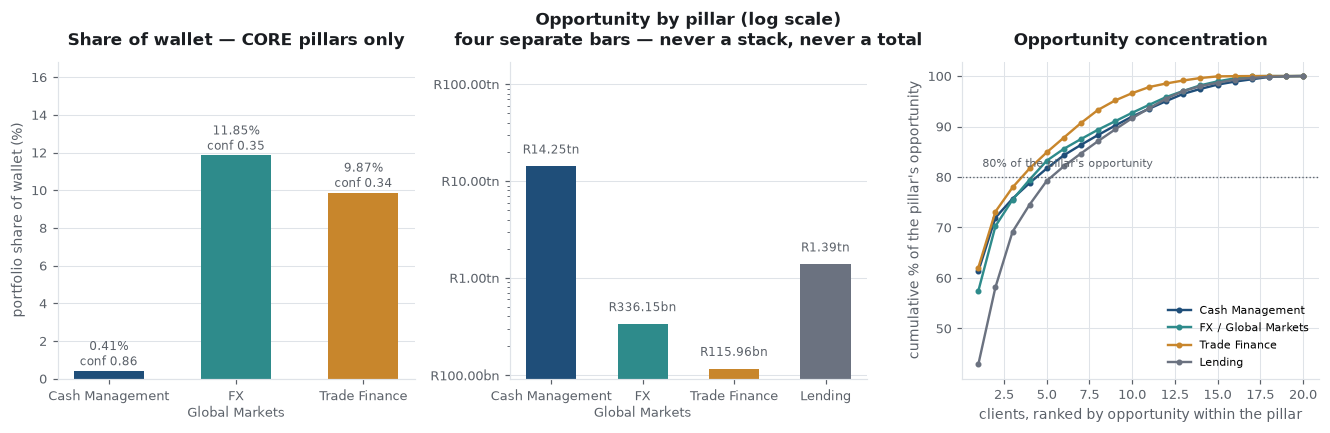

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.1))

# --- 1. share of wallet, the three CORE pillars -------------------------------------
core = PORTFOLIO[PORTFOLIO["product_class"] == "CORE"]
axes[0].bar(range(len(core)), core["portfolio_share"] * 100, width=0.55,
            color=[PILLAR_COLOUR[p] for p in core["product"]])
axes[0].set_xticks(range(len(core)))
axes[0].set_xticklabels([SHORT[p].replace(" / ", "\n") for p in core["product"]], fontsize=8.5)
axes[0].set_ylabel("portfolio share of wallet (%)")
for x, (value, conf) in enumerate(zip(core["portfolio_share"] * 100, core["mean_confidence"])):
    axes[0].text(x, value + 0.3, f"{value:.2f}%\nconf {conf:.2f}", ha="center", fontsize=8,
                 color=MUTED)
axes[0].set_ylim(0, core["portfolio_share"].max() * 100 * 1.42)
axes[0].set_title("Share of wallet — CORE pillars only")
axis_style(axes[0])

# --- 2. opportunity by product, SEPARATE panels, never stacked ----------------------
opportunity = PORTFOLIO.dropna(subset=["total_gap_zar"])
axes[1].bar(range(len(opportunity)), opportunity["total_gap_zar"], width=0.55,
            color=[PILLAR_COLOUR[p] for p in opportunity["product"]])
axes[1].set_xticks(range(len(opportunity)))
axes[1].set_xticklabels([SHORT[p].replace(" / ", "\n") for p in opportunity["product"]],
                        fontsize=8.5)
axes[1].set_yscale("log"); zar_axis(axes[1], "y")
for x, value in enumerate(opportunity["total_gap_zar"]):
    axes[1].text(x, value * 1.35, zar(value), ha="center", fontsize=8, color=MUTED)
axes[1].set_ylim(top=opportunity["total_gap_zar"].max() * 12)
axes[1].set_title("Opportunity by pillar (log scale)\nfour separate bars — never a stack, "
                  "never a total")
axis_style(axes[1])

# --- 3. opportunity concentration ----------------------------------------------------
for product in ("cash_management", "fx_global_markets", "trade_finance", "lending"):
    rows = ENGINE[ENGINE["product"] == product].sort_values("opportunity_zar", ascending=False)
    cumulative = rows["opportunity_zar"].cumsum() / rows["opportunity_zar"].sum()
    axes[2].plot(range(1, len(rows) + 1), cumulative * 100, marker="o", ms=3,
                 color=PILLAR_COLOUR[product], label=SHORT[product], lw=1.6)
axes[2].axhline(80, color=MUTED, ls=":", lw=0.9)
axes[2].text(1, 82, " 80% of the pillar's opportunity", fontsize=7.5, color=MUTED)
axes[2].set_xlabel("clients, ranked by opportunity within the pillar")
axes[2].set_ylabel("cumulative % of the pillar's opportunity")
axes[2].set_title("Opportunity concentration")
axes[2].legend(loc="lower right", fontsize=7.5)
axis_style(axes[2], xgrid=True)
plt.tight_layout(); plt.show()

In [65]:
CONCENTRATION = []
for product in ("cash_management", "fx_global_markets", "trade_finance", "lending"):
    rows = ENGINE[ENGINE["product"] == product].sort_values("opportunity_zar", ascending=False)
    total = rows["opportunity_zar"].sum()
    CONCENTRATION.append({
        "pillar": SHORT[product],
        "top client": rows.iloc[0]["entity_name"],
        "top client share of pillar": rows.iloc[0]["opportunity_zar"] / total,
        "top 3 share": rows["opportunity_zar"].head(3).sum() / total,
        "top 5 share": rows["opportunity_zar"].head(5).sum() / total,
        "clients to reach 80%": int((rows["opportunity_zar"].cumsum() / total < 0.8).sum() + 1),
    })
table(pd.DataFrame(CONCENTRATION), "Opportunity concentration within each pillar",
      percent=["top client share of pillar", "top 3 share", "top 5 share"],
      counts=["clients to reach 80%"])

**Opportunity concentration within each pillar**

pillar,top client,top client share of pillar,top 3 share,top 5 share,clients to reach 80%
Cash Management,Glencore,61.36%,75.70%,81.69%,5
FX / Global Markets,Glencore,57.44%,75.49%,83.22%,5
Trade Finance,Glencore,62.06%,77.93%,84.88%,4
Lending,Glencore,42.90%,69.15%,79.22%,6


## The rows most likely to be quoted, and least likely to survive review

The commercial score already discounts these, but the rand amounts must not be quoted without
the caveat. Every one carries a HIGH-severity diagnostic.

In [66]:
RISKY = ENGINE[ENGINE["high_severity_diagnostic"]].sort_values(
    "opportunity_zar", ascending=False).head(10)[
    ["entity_name", "product", "opportunity_zar", "confidence", "confidence_band",
     "benchmark_level", "benchmark_n", "commercial_rank", "diagnostic_flags"]]
RISKY.columns = ["client", "pillar", "opportunity", "confidence", "band", "benchmark", "n",
                 "commercial rank", "diagnostics"]
table(RISKY, "Large opportunities on low confidence — quote only with the caveat",
      money=["opportunity"], decimals=["confidence"], counts=["n", "commercial rank"])

DIAGNOSTICS = load("model_diagnostics")
table(DIAGNOSTICS.groupby(["severity", "diagnostic"], as_index=False).size().rename(
          columns={"size": "findings"}).sort_values(["severity", "findings"],
                                                    ascending=[True, False]),
      "Every diagnostic the engine raised about its own output",
      counts=["findings"])

**Large opportunities on low confidence — quote only with the caveat**

client,pillar,opportunity,confidence,band,benchmark,n,commercial rank,diagnostics
BHP Group,cash_management,R1.51tn,0.669,MEDIUM,not_applicable,n/a,4,cogs_imputed
Anglo American,cash_management,R536.14bn,0.665,MEDIUM,not_applicable,n/a,5,cogs_imputed
BHP Group,lending,R212.14bn,0.581,MEDIUM,sector,5,20,no_competitor_lending_evidence
Glencore,fx_global_markets,R193.07bn,0.190,LOW,mixed,9,14,"foreign_revenue_imputed,no_disclosed_hedging"
Anglo American,lending,R152.73bn,0.641,MEDIUM,sector,5,21,no_competitor_lending_evidence
Glencore,trade_finance,R71.96bn,0.251,LOW,mixed,6,10,foreign_revenue_imputed
BHP Group,fx_global_markets,R43.12bn,0.235,LOW,mixed,9,18,"foreign_revenue_imputed,cogs_imputed,estimate_dominated_by_imputed_driver"
MTN Group,fx_global_markets,R17.59bn,0.429,LOW,portfolio,12,23,"cogs_imputed,no_disclosed_hedging"
Valterra Platinum,fx_global_markets,R13.41bn,0.413,LOW,mixed,8,15,"no_disclosed_hedging,revenue_split_identity_failed"
BHP Group,trade_finance,R12.84bn,0.182,LOW,mixed,6,24,"cogs_imputed,foreign_revenue_imputed"


**Every diagnostic the engine raised about its own output**

severity,diagnostic,findings
HIGH,large_opportunity_low_confidence,11
HIGH,opportunity_driven_by_company_size,8
HIGH,product_model_insufficient_evidence,3
INFO,extreme_gap_in_product,8
INFO,product_ranking_tracks_company_size,1
MEDIUM,estimate_driven_by_missing_variable,31
MEDIUM,unusually_high_share,4
MEDIUM,sector_systematically_extreme_share,1


---

# 16. Client case studies

Three real clients from the published output, chosen because each stresses a different part of
the model:

| | Client | Why this one |
|---|---|---|
| **A** | **Glencore** (E02, mining, USD) | The largest opportunity in the portfolio — and, inside a single client, the sharpest contrast between an identity-anchored figure you can quote and two peer-benchmarked figures you cannot |
| **B** | **MTN Group** (E16, telecoms, ZAR) | The FX / Trade case. Both pillars fall back to a portfolio benchmark, both carry unusually *high* observed shares, and both are assumption-sensitive |
| **C** | **Shaftesbury Capital plc** (E20, real estate, GBP) | The Lending / Investment Banking case — the client whose financing need is 3.86× its entire annual operating turnover, and which the commercial ranking buries |

The renderer below is presentation only. Every figure it shows is read from the contract, the
commercial intelligence layer or the sensitivity sweep.

In [67]:
INTELLIGENCE = load("client_opportunity_intelligence")
EXPLANATIONS = load("opportunity_explanations")
QUESTIONS = load("banker_questions")

EXTERNAL_SIGNALS = [
    ("revenue_total_zar", "Revenue", "money"),
    ("cost_of_sales_zar", "Cost of sales", "money"),
    ("revenue_foreign_zar", "Foreign revenue", "money"),
    ("foreign_revenue_share", "Foreign revenue share", "percent"),
    ("gross_debt_zar", "Gross debt", "money"),
    ("debt_current_zar", "Debt classified current", "money"),
    ("undrawn_facilities_zar", "Undrawn committed facilities", "money"),
    ("capex_zar", "Capex", "money"),
    ("fx_forward_notional_zar", "Disclosed FX forward notional", "money"),
    ("working_capital_zar", "Working capital cycle", "money"),
    ("named_lender_count", "Lenders named in the facilities note", "count"),
    ("txn_memo_count_fy", "Competitor-lending memos (FY)", "count"),
    ("txn_payroll_count_fy", "Payroll instructions (FY)", "count"),
    ("employees", "Employees", "count"),
]


def case_study(entity_id):
    """Render one client from the published tables. Presentation only."""
    profile = PROFILE[PROFILE["entity_id"] == entity_id].iloc[0]
    intel = INTELLIGENCE[INTELLIGENCE["entity_id"] == entity_id].iloc[0]
    features = FEATURES[FEATURES["entity_id"] == entity_id].iloc[0]
    pillars = ENGINE[ENGINE["entity_id"] == entity_id].set_index("product").reindex(PILLARS)
    sens = SENSITIVITY[SENSITIVITY["entity_id"] == entity_id].set_index("product")

    display(Markdown(
        f"## {profile['entity_name']}  ·  `{entity_id}`  ·  {profile['sector']}  ·  "
        f"{features['reporting_currency']} reporter  ·  {profile['fy_label']} "
        f"(year end {pd.Timestamp(profile['fiscal_year_end']).date()})\n\n"
        f"> {intel['opportunity_summary']}"))

    rows = []
    for product in PILLARS:
        pillar = pillars.loc[product]
        band = sens.loc[product] if product in sens.index else None
        rows.append({
            "pillar": SHORT[product],
            "class": pillar["product_class"],
            "estimate basis": pillar["estimate_basis"],
            "observed": pillar["observed_zar"],
            "addressable": pillar["addressable_zar"],
            "share": pillar["share"],
            "opportunity": pillar["opportunity_zar"],
            "confidence": pillar["confidence"],
            "band": pillar["confidence_band"],
            "benchmark": pillar["benchmark_level"],
            "n": pillar["benchmark_n"],
            "sensitivity range": (
                f"{zar(band['estimate_low'])} – {zar(band['estimate_high'])}"
                if band is not None and pd.notna(band["estimate_low"]) else "n/a"),
            "flag": band["sensitivity_flag"] if band is not None else "n/a",
            "rank stability": band["rank_stability"] if band is not None else "n/a",
        })
    table(pd.DataFrame(rows), "All five pillars — observed, addressable, share, opportunity, "
                              "confidence and sensitivity",
          money=["observed", "addressable", "opportunity"], percent=["share"],
          decimals=["confidence"], counts=["n"])

    signals = []
    for column, label, kind in EXTERNAL_SIGNALS:
        value = features[column]
        signals.append({"supporting signal": label,
                        "value": (zar(value) if kind == "money"
                                  else pct(value) if kind == "percent" else count(value))})
    half = (len(signals) + 1) // 2
    side_by_side = pd.concat([
        pd.DataFrame(signals[:half]).reset_index(drop=True),
        pd.DataFrame(signals[half:]).reset_index(drop=True).rename(
            columns={"supporting signal": "supporting signal ", "value": "value "}),
    ], axis=1).fillna("")
    table(side_by_side, "Supporting external and internal signals")

    display(Markdown("**Selected opportunities and the recommended action**"))
    for slot in ("primary", "secondary", "supporting_signal"):
        rows = EXPLANATIONS[(EXPLANATIONS["entity_id"] == entity_id)
                            & (EXPLANATIONS["selection_slot"] == slot)]
        if rows.empty:
            continue
        row = rows.iloc[0]
        display(Markdown(
            f"---\n\n#### {slot.replace('_', ' ').title()} — {row['product_label']} "
            f"&nbsp;·&nbsp; `{row['product_class']}` &nbsp;·&nbsp; "
            f"status **{row['opportunity_status']}** &nbsp;·&nbsp; "
            f"confidence **{row['confidence_band']}**\n\n"
            f"**What.** {row['what']}\n\n"
            f"**Why.** {row['why']}\n\n"
            f"**Evidence.** {row['evidence']}\n\n"
            f"**Recommended action.** {row['next_action']}\n\n"
            f"**Limitation.** {row['limitation']}"))

    asked = QUESTIONS[QUESTIONS["entity_id"] == entity_id][
        ["selection_slot", "product_label", "question"]]
    table(asked, "Questions the banker can take into the meeting — generated "
                 "deterministically from the same fields")

## A · Glencore — the largest opportunity in the portfolio

Rank 1 on the Commercial Opportunity Score, and the clearest illustration of why a single
client needs three different levels of caution applied to three different figures.

In [68]:
case_study("E02")

## Glencore  ·  `E02`  ·  mining  ·  USD reporter  ·  FY2025 (year end 2025-12-31)

> Glencore (mining, FY2025): primary opportunity is Transactional / Cash Management at PRIORITY, R8.75tn of unserved activity, HIGH confidence. Secondary: Lending (PRIORITY). 10 model diagnostics recorded across all pillars, with HIGH severity on: fx_global_markets, trade_finance — review those before quoting their rand figures. Syn Bank currently handles 0.03% of this client's Addressable Cash Flow.

**All five pillars — observed, addressable, share, opportunity, confidence and sensitivity**

pillar,class,estimate basis,observed,addressable,share,opportunity,confidence,band,benchmark,n,sensitivity range,flag,rank stability
Cash Management,CORE,addressable_cash_flow,R2.50bn,R8.75tn,0.03%,R8.75tn,0.938,HIGH,not_applicable,n/a,R8.75tn – R8.75tn,STABLE,STABLE
FX / Global Markets,CORE,peer_benchmark_addressable,R2.41bn,R195.48bn,1.23%,R193.07bn,0.190,LOW,mixed,9,R53.76bn – R358.29bn,SENSITIVE,STABLE
Trade Finance,CORE,peer_benchmark_addressable,R1.03bn,R72.99bn,1.41%,R71.96bn,0.251,LOW,mixed,6,R28.41bn – R103.15bn,SENSITIVE,STABLE
Lending,SUPPORTING,financing_opportunity,n/a,R596.26bn,n/a,R596.26bn,0.738,HIGH,sector,5,R573.47bn – R609.30bn,STABLE,STABLE
Investment Banking,SIGNAL_ONLY,signal_only,n/a,n/a,n/a,n/a,0.454,MEDIUM,not_applicable,n/a,n/a,NOT_APPLICABLE,NOT_APPLICABLE


**Supporting external and internal signals**

supporting signal,value,supporting signal,value
Revenue,R4.43tn,Capex,R123.25bn
Cost of sales,R4.32tn,Disclosed FX forward notional,n/a
Foreign revenue,n/a,Working capital cycle,R367.93bn
Foreign revenue share,n/a,Lenders named in the facilities note,n/a
Gross debt,R688.58bn,Competitor-lending memos (FY),25
Debt classified current,R240.57bn,Payroll instructions (FY),64
Undrawn committed facilities,R214.11bn,Employees,"140,000"


...

---

#### Primary — Transactional / Cash Management &nbsp;·&nbsp; `CORE` &nbsp;·&nbsp; status **PRIORITY** &nbsp;·&nbsp; confidence **HIGH**

**What.** Transactional / Cash Management: R8.75tn of unserved activity against R8.75tn of Addressable Cash Flow.

**Why.** The client's Addressable Cash Flow of R8.75tn is its own annual operating turnover: revenue collected in plus cost of sales paid out, both of which must move through a bank account. Syn Bank currently handles 0.03% of the client's observable addressable cash flow — R2.50bn in FY2025 — leaving R8.75tn of operating flow that Syn Bank's data does not show. The denominator is an accounting identity, not an estimate, which is why this is the best-evidenced pillar in the model.

**Evidence.** From `opportunity_engine.parquet` for E02 x cash_management: `observed_zar` = R2.50bn; `addressable_zar` = R8.75tn; `share` = 0.03%; `opportunity_zar` = R8.75tn; `confidence` = 0.94; `diagnostic_count` = 1. 1 model diagnostic recorded (none HIGH severity). Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R8.75tn to R8.75tn around a base of R8.75tn.

**Recommended action.** Recommend investigation. Establish where the rest of the client's operating collections and supplier payments are settled, and whether Syn Bank is positioned on the primary operating account or only on secondary flows.

**Limitation.** Addressable Cash Flow is the client's own annual operating turnover — the collections and supplier payments it must move through a bank account somewhere. It is not bank income, and nothing is estimated on it in fee terms, because Syn Bank discloses no pricing.

---

#### Secondary — Lending &nbsp;·&nbsp; `SUPPORTING` &nbsp;·&nbsp; status **PRIORITY** &nbsp;·&nbsp; confidence **HIGH**

**What.** Lending: a financing opportunity of R596.26bn inside a twelve-month horizon.

**Why.** The client's disclosed debt structure indicates R596.26bn of financing decisions falling inside a twelve-month horizon: debt classified as current, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied datasets contain no loan book, so there is no observed lending activity to divide and no share of wallet is computed. This is a financing-need indicator, not a wallet.

**Evidence.** From `opportunity_engine.parquet` for E02 x lending: `opportunity_zar` = R596.26bn; `addressable_zar` = R596.26bn; `confidence` = 0.74; `diagnostic_count` = 1; `share_basis` = no_observed_activity_in_dataset. 1 model diagnostic recorded (none HIGH severity). Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R573.47bn to R609.30bn around a base of R596.26bn.

**Recommended action.** Recommend investigation. Establish the maturity profile of the debt falling due inside twelve months, how much is already committed, and whether the undrawn facilities are being renewed.

**Limitation.** This is a financing-need indicator built from the client's disclosed debt structure — debt falling due, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied data contains no loan book, so no share of wallet is computed and none should be quoted.

---

#### Supporting Signal — Trade Finance &nbsp;·&nbsp; `CORE` &nbsp;·&nbsp; status **MONITOR** &nbsp;·&nbsp; confidence **LOW**

**What.** Trade Finance: R71.96bn of unserved activity against R72.99bn of peer-benchmark addressable trade-finance activity.

**Why.** Syn Bank issued R1.03bn of trade instruments for this client in FY2025. Scaling the client's procurement base, export exposure and revenue by peer issuance intensity -- measured across 6 mixed peers, with this client excluded -- puts peer-benchmark addressable trade-finance activity at R72.99bn, a share of 1.41% and R71.96bn of potential headroom.

**Evidence.** From `opportunity_engine.parquet` for E02 x trade_finance: `observed_zar` = R1.03bn; `addressable_zar` = R72.99bn; `share` = 1.41%; `opportunity_zar` = R71.96bn; `benchmark_level` = mixed; `benchmark_n` = 6; `confidence` = 0.25; `diagnostic_count` = 4. 4 model diagnostics recorded (including at least one HIGH severity); flags `foreign_revenue_imputed`. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R28.41bn to R103.15bn around a base of R72.99bn.

**Recommended action.** Monitor / validate before pursuing. Establish the client's actual annual trade-instrument issuance and the size of its existing facilities, then test the peer-benchmark estimate against what the client says.

**Limitation.** No disclosure states this client's total trade-finance issuance, so the addressable figure is the client's own procurement and export base scaled by peer issuance intensity, with this client excluded from that peer population. It is a benchmark expectation, not a disclosed market total. The model indicates potential headroom, but the estimate is benchmark-sensitive: across the tested assumptions the addressable figure spans R28.41bn to R103.15bn (102% of the base case), and the client's position within this pillar holds its position across every tested assumption. Present it as a range, not as a single figure. Confidence is LOW, so this figure should be validated against the client's own disclosure before it is used in a commercial conversation. A HIGH-severity model diagnostic is open on this estimate; review it before quoting the rand amount.

**Questions the banker can take into the meeting — generated deterministically from the same fields**

selection_slot,product_label,question
primary,Transactional / Cash Management,"Our records show R2.50bn of your operating collections and supplier payments settling through Syn Bank in FY2025, against an addressable operating cash flow of about R8.75tn implied by your reported revenue and cost of sales — roughly 0.0%. Which bank currently holds your primary operating account, and what drives that split?"
primary,Transactional / Cash Management,"About R8.75tn of your annual operating flow is not visible in our transaction data. Is that a deliberate multi-banking arrangement, a legacy of an acquisition, or simply where the relationship has settled?"
primary,Transactional / Cash Management,"Where is your payroll run, and would you consider consolidating it alongside your collections and supplier payments?"
primary,Transactional / Cash Management,"What would need to change in service, pricing or systems integration for a larger share of your day-to-day settlement to run through us?"
secondary,Lending,Your disclosed debt structure points to roughly R596.26bn of financing decisions falling inside the next twelve months. How much of that requirement is already committed?


> **What makes Glencore instructive.** Its cash figure is HIGH confidence and **STABLE across
> all 36 model configurations** — the denominator is revenue plus cost of sales, an accounting
> identity, so no assumption in the grid can move it. Its FX and trade figures are LOW
> confidence, carry HIGH-severity diagnostics, and sit on peer benchmarks with `n = 9` and
> `n = 6`. The same client, the same disclosures, three completely different levels of
> defensibility — and the model says so on the face of each row rather than in a footnote.

## B · MTN Group — the FX and Trade case

MTN is where the peer-benchmark machinery is under the most strain, and where the sensitivity
range does the most work.

In [69]:
case_study("E16")

## MTN Group  ·  `E16`  ·  telecoms  ·  ZAR reporter  ·  FY2025 (year end 2025-12-31)

> MTN Group (telecoms, FY2025): primary opportunity is Lending at PRIORITY, R65.25bn of unserved activity, HIGH confidence, moderately sensitive to benchmark assumptions. Secondary: Transactional / Cash Management (INVESTIGATE). 5 model diagnostics recorded across all pillars, with HIGH severity on: fx_global_markets, trade_finance — review those before quoting their rand figures. Syn Bank currently handles 1.05% of this client's Addressable Cash Flow.

**All five pillars — observed, addressable, share, opportunity, confidence and sensitivity**

pillar,class,estimate basis,observed,addressable,share,opportunity,confidence,band,benchmark,n,sensitivity range,flag,rank stability
Cash Management,CORE,addressable_cash_flow,R3.96bn,R376.90bn,1.05%,R372.94bn,0.593,MEDIUM,not_applicable,n/a,R376.90bn – R376.90bn,STABLE,STABLE
FX / Global Markets,CORE,peer_benchmark_addressable,R6.43bn,R24.02bn,26.78%,R17.59bn,0.429,LOW,portfolio,12,R6.43bn – R33.72bn,SENSITIVE,SENSITIVE
Trade Finance,CORE,peer_benchmark_addressable,R1.54bn,R7.10bn,21.63%,R5.56bn,0.421,LOW,portfolio,19,R2.30bn – R8.05bn,SENSITIVE,SENSITIVE
Lending,SUPPORTING,financing_opportunity,n/a,R65.25bn,n/a,R65.25bn,0.790,HIGH,portfolio,12,R61.40bn – R69.10bn,MODERATE,STABLE
Investment Banking,SIGNAL_ONLY,signal_only,n/a,n/a,n/a,n/a,0.345,LOW,not_applicable,n/a,n/a,NOT_APPLICABLE,NOT_APPLICABLE


**Supporting external and internal signals**

supporting signal,value,supporting signal,value
Revenue,R226.71bn,Capex,R38.50bn
Cost of sales,n/a,Disclosed FX forward notional,n/a
Foreign revenue,R176.22bn,Working capital cycle,R-27.46bn
Foreign revenue share,77.73%,Lenders named in the facilities note,1
Gross debt,R70.37bn,Competitor-lending memos (FY),258
Debt classified current,R17.75bn,Payroll instructions (FY),683
Undrawn committed facilities,R35.95bn,Employees,n/a


...

---

#### Primary — Lending &nbsp;·&nbsp; `SUPPORTING` &nbsp;·&nbsp; status **PRIORITY** &nbsp;·&nbsp; confidence **HIGH**

**What.** Lending: a financing opportunity of R65.25bn inside a twelve-month horizon.

**Why.** The client's disclosed debt structure indicates R65.25bn of financing decisions falling inside a twelve-month horizon: debt classified as current, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied datasets contain no loan book, so there is no observed lending activity to divide and no share of wallet is computed. This is a financing-need indicator, not a wallet.

**Evidence.** From `opportunity_engine.parquet` for E16 x lending: `opportunity_zar` = R65.25bn; `addressable_zar` = R65.25bn; `confidence` = 0.79; `diagnostic_count` = 0; `share_basis` = no_observed_activity_in_dataset. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R61.40bn to R69.10bn around a base of R65.25bn.

**Recommended action.** Recommend investigation. Establish the maturity profile of the debt falling due inside twelve months, how much is already committed, and whether the undrawn facilities are being renewed.

**Limitation.** This is a financing-need indicator built from the client's disclosed debt structure — debt falling due, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied data contains no loan book, so no share of wallet is computed and none should be quoted.

---

#### Secondary — Transactional / Cash Management &nbsp;·&nbsp; `CORE` &nbsp;·&nbsp; status **INVESTIGATE** &nbsp;·&nbsp; confidence **MEDIUM**

**What.** Transactional / Cash Management: R372.94bn of unserved activity against R376.90bn of Addressable Cash Flow.

**Why.** The client's Addressable Cash Flow of R376.90bn is its own annual operating turnover: revenue collected in plus cost of sales paid out, both of which must move through a bank account. Syn Bank currently handles 1.05% of the client's observable addressable cash flow — R3.96bn in FY2025 — leaving R372.94bn of operating flow that Syn Bank's data does not show. The denominator is an accounting identity, not an estimate, which is why this is the best-evidenced pillar in the model.

**Evidence.** From `opportunity_engine.parquet` for E16 x cash_management: `observed_zar` = R3.96bn; `addressable_zar` = R376.90bn; `share` = 1.05%; `opportunity_zar` = R372.94bn; `confidence` = 0.59; `diagnostic_count` = 1. 1 model diagnostic recorded (none HIGH severity); flags `cogs_imputed`. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R376.90bn to R376.90bn around a base of R376.90bn.

**Recommended action.** Consider investigation. Establish where the rest of the client's operating collections and supplier payments are settled, and whether Syn Bank is positioned on the primary operating account or only on secondary flows.

**Limitation.** Addressable Cash Flow is the client's own annual operating turnover — the collections and supplier payments it must move through a bank account somewhere. It is not bank income, and nothing is estimated on it in fee terms, because Syn Bank discloses no pricing.

---

#### Supporting Signal — Trade Finance &nbsp;·&nbsp; `CORE` &nbsp;·&nbsp; status **MONITOR** &nbsp;·&nbsp; confidence **LOW**

**What.** Trade Finance: R5.56bn of unserved activity against R7.10bn of peer-benchmark addressable trade-finance activity.

**Why.** Syn Bank issued R1.54bn of trade instruments for this client in FY2025. Scaling the client's procurement base, export exposure and revenue by peer issuance intensity -- measured across 19 portfolio peers, with this client excluded -- puts peer-benchmark addressable trade-finance activity at R7.10bn, a share of 21.63% and R5.56bn of potential headroom.

**Evidence.** From `opportunity_engine.parquet` for E16 x trade_finance: `observed_zar` = R1.54bn; `addressable_zar` = R7.10bn; `share` = 21.63%; `opportunity_zar` = R5.56bn; `benchmark_level` = portfolio; `benchmark_n` = 19; `confidence` = 0.42; `diagnostic_count` = 2. 2 model diagnostics recorded (including at least one HIGH severity); flags `cogs_imputed`. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R2.30bn to R8.05bn around a base of R7.10bn.

**Recommended action.** Monitor / validate before pursuing. Establish the client's actual annual trade-instrument issuance and the size of its existing facilities, then test the peer-benchmark estimate against what the client says.

**Limitation.** No disclosure states this client's total trade-finance issuance, so the addressable figure is the client's own procurement and export base scaled by peer issuance intensity, with this client excluded from that peer population. It is a benchmark expectation, not a disclosed market total. The model indicates potential headroom, but the estimate is benchmark-sensitive: across the tested assumptions the addressable figure spans R2.30bn to R8.05bn (81% of the base case), and the client's position within this pillar moves substantially depending on the benchmark assumption. Present it as a range, not as a single figure. Confidence is LOW, so this figure should be validated against the client's own disclosure before it is used in a commercial conversation. A HIGH-severity model diagnostic is open on this estimate; review it before quoting the rand amount.

**Questions the banker can take into the meeting — generated deterministically from the same fields**

selection_slot,product_label,question
secondary,Transactional / Cash Management,"Our records show R3.96bn of your operating collections and supplier payments settling through Syn Bank in FY2025, against an addressable operating cash flow of about R376.90bn implied by your reported revenue and cost of sales — roughly 1.1%. Which bank currently holds your primary operating account, and what drives that split?"
primary,Lending,Your disclosed debt structure points to roughly R65.25bn of financing decisions falling inside the next twelve months. How much of that requirement is already committed?
primary,Lending,"Your undrawn committed facilities are capacity you are paying for and not using — are those lines up for renewal, and what would make you consolidate them?"
primary,Lending,"How is your working-capital cycle funded today — from operating cash, from committed lines, or from a mix — and is that mix under review?"
primary,Lending,How much of your planned capital expenditure do you expect to fund with new debt rather than operating cash flow?


> **Why MTN stresses the model.** It is one of two telecoms clients, and **neither discloses
> cost of sales**, so the sector can never reach the three-peer minimum after leave-one-out
> exclusion. Both the FX and the trade estimate therefore fall back to a **portfolio benchmark
> applied to an imputed cost-of-sales driver** — two layers of estimation stacked on each
> other, which the `input_completeness` factor and the `cogs_imputed` diagnostic both record.
> Both land on LOW confidence with a HIGH-severity diagnostic open, and the summary above says
> so in the first sentence a banker reads.
>
> **MTN's observed FX and trade shares — 26.8% and 21.6% — sit close to the portfolio medians
> of 26.1% and 18.9%, and those medians are the model's most uncomfortable result about
> itself.** A peer-benchmark denominator that leaves Syn Bank holding roughly a quarter of
> every client's cross-border settlement is more likely to be too *small* than to be right.
> §18 states the consequence plainly: if the whole portfolio is under-penetrated, every
> peer-benchmark wallet is understated together and no amount of internal data would reveal
> it. Rank these; do not read the level.
>
> **This is also the one client in twenty where cash management does not win the primary slot.**
> The selection score puts Lending first at `PRIORITY` — R65.25bn of financing need on HIGH
> confidence — precisely because MTN's cash pillar, while large, sits on MEDIUM confidence with
> an imputed cost-of-sales denominator, while its lending estimate rests on disclosed debt
> structure. Against that, MTN's payroll engagement (2,032 instructions in three years against
> sector peer Vodacom's 11) says the primary domestic relationship is genuinely there. The FX
> and trade numbers belong in the room as **ranges with their benchmark population stated**,
> never as headline figures.

## C · Shaftesbury Capital plc — the Lending and Investment Banking case

In [70]:
case_study("E20")

## Shaftesbury Capital plc  ·  `E20`  ·  real_estate  ·  GBP reporter  ·  FY2025 (year end 2025-12-31)

> Shaftesbury Capital plc (real_estate, FY2025): primary opportunity is Transactional / Cash Management at INVESTIGATE, R7.06bn of unserved activity, HIGH confidence. Secondary: Lending (INVESTIGATE). Syn Bank currently handles 0.15% of this client's Addressable Cash Flow.

**All five pillars — observed, addressable, share, opportunity, confidence and sensitivity**

pillar,class,estimate basis,observed,addressable,share,opportunity,confidence,band,benchmark,n,sensitivity range,flag,rank stability
Cash Management,CORE,addressable_cash_flow,R10.9m,R7.07bn,0.15%,R7.06bn,0.900,HIGH,not_applicable,n/a,R7.07bn – R7.07bn,STABLE,STABLE
FX / Global Markets,CORE,peer_benchmark_addressable,R129.5m,R235.3m,55.04%,R105.8m,0.157,LOW,portfolio,12,R129.5m – R394.3m,SENSITIVE,MODERATE
Trade Finance,CORE,peer_benchmark_addressable,R5.7m,R9.6m,59.65%,R3.9m,0.418,LOW,portfolio,19,R5.7m – R10.0m,SENSITIVE,STABLE
Lending,SUPPORTING,financing_opportunity,n/a,R27.32bn,n/a,R27.32bn,0.487,MEDIUM,portfolio,12,R27.05bn – R27.59bn,STABLE,STABLE
Investment Banking,SIGNAL_ONLY,signal_only,n/a,n/a,n/a,n/a,0.288,LOW,not_applicable,n/a,n/a,NOT_APPLICABLE,NOT_APPLICABLE


**Supporting external and internal signals**

supporting signal,value,supporting signal,value
Revenue,R5.63bn,Capex,R2.67bn
Cost of sales,R1.44bn,Disclosed FX forward notional,n/a
Foreign revenue,n/a,Working capital cycle,n/a
Foreign revenue share,n/a,Lenders named in the facilities note,n/a
Gross debt,R27.02bn,Competitor-lending memos (FY),1
Debt classified current,R9.78bn,Payroll instructions (FY),1
Undrawn committed facilities,R16.74bn,Employees,101


...

---

#### Primary — Transactional / Cash Management &nbsp;·&nbsp; `CORE` &nbsp;·&nbsp; status **INVESTIGATE** &nbsp;·&nbsp; confidence **HIGH**

**What.** Transactional / Cash Management: R7.06bn of unserved activity against R7.07bn of Addressable Cash Flow.

**Why.** The client's Addressable Cash Flow of R7.07bn is its own annual operating turnover: revenue collected in plus cost of sales paid out, both of which must move through a bank account. Syn Bank currently handles 0.15% of the client's observable addressable cash flow — R10.9m in FY2025 — leaving R7.06bn of operating flow that Syn Bank's data does not show. The denominator is an accounting identity, not an estimate, which is why this is the best-evidenced pillar in the model.

**Evidence.** From `opportunity_engine.parquet` for E20 x cash_management: `observed_zar` = R10.9m; `addressable_zar` = R7.07bn; `share` = 0.15%; `opportunity_zar` = R7.06bn; `confidence` = 0.90; `diagnostic_count` = 0. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R7.07bn to R7.07bn around a base of R7.07bn.

**Recommended action.** Consider investigation. Establish where the rest of the client's operating collections and supplier payments are settled, and whether Syn Bank is positioned on the primary operating account or only on secondary flows.

**Limitation.** Addressable Cash Flow is the client's own annual operating turnover — the collections and supplier payments it must move through a bank account somewhere. It is not bank income, and nothing is estimated on it in fee terms, because Syn Bank discloses no pricing.

---

#### Secondary — Lending &nbsp;·&nbsp; `SUPPORTING` &nbsp;·&nbsp; status **INVESTIGATE** &nbsp;·&nbsp; confidence **MEDIUM**

**What.** Lending: a financing opportunity of R27.32bn inside a twelve-month horizon.

**Why.** The client's disclosed debt structure indicates R27.32bn of financing decisions falling inside a twelve-month horizon: debt classified as current, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied datasets contain no loan book, so there is no observed lending activity to divide and no share of wallet is computed. This is a financing-need indicator, not a wallet.

**Evidence.** From `opportunity_engine.parquet` for E20 x lending: `opportunity_zar` = R27.32bn; `addressable_zar` = R27.32bn; `confidence` = 0.49; `diagnostic_count` = 0; `share_basis` = no_observed_activity_in_dataset. Across 36 tested scenarios in `model_sensitivity.parquet`, the addressable figure ranges R27.05bn to R27.59bn around a base of R27.32bn.

**Recommended action.** Consider investigation. Establish the maturity profile of the debt falling due inside twelve months, how much is already committed, and whether the undrawn facilities are being renewed.

**Limitation.** This is a financing-need indicator built from the client's disclosed debt structure — debt falling due, undrawn committed facilities, the working-capital cycle and capex. Syn Bank's supplied data contains no loan book, so no share of wallet is computed and none should be quoted.

---

#### Supporting Signal — Investment Banking / Capital Markets &nbsp;·&nbsp; `SIGNAL_ONLY` &nbsp;·&nbsp; status **MONITOR** &nbsp;·&nbsp; confidence **LOW**

**What.** Investment Banking / Capital Markets: an investment-banking opportunity signal of 0.75 on a 0-1 scale, ranked against the other nineteen clients in this portfolio. No rand amount is estimated.

**Why.** An investment-banking opportunity signal of 0.75, built from five percentile-ranked balance-sheet facts: scale, leverage, near-term maturity, capex intensity and syndicate breadth. The disclosed balance sheet supports a corporate finance category. Nothing in the supplied data indicates a planned issue, disposal or acquisition, so no rand amount is estimated and none should be quoted.

**Evidence.** From `opportunity_engine.parquet` for E20 x investment_banking: `signal_score` = 0.75; `confidence` = 0.29; `diagnostic_count` = 0; `share_basis` = no_observed_activity_in_dataset.

**Recommended action.** Monitor / validate before pursuing. Treat as background for a relationship conversation. Confirm whether any capital-markets or corporate-finance activity is planned before allocating coverage effort.

**Limitation.** A ranked mandate-likelihood signal relative to the other nineteen clients in this portfolio. No rand amount is estimated, because nothing in the supplied data indicates a planned issue, disposal or acquisition. Confidence is LOW, so this figure should be validated against the client's own disclosure before it is used in a commercial conversation.

**Questions the banker can take into the meeting — generated deterministically from the same fields**

selection_slot,product_label,question
primary,Transactional / Cash Management,"Our records show R10.9m of your operating collections and supplier payments settling through Syn Bank in FY2025, against an addressable operating cash flow of about R7.07bn implied by your reported revenue and cost of sales — roughly 0.2%. Which bank currently holds your primary operating account, and what drives that split?"
primary,Transactional / Cash Management,"About R7.06bn of your annual operating flow is not visible in our transaction data. Is that a deliberate multi-banking arrangement, a legacy of an acquisition, or simply where the relationship has settled?"
primary,Transactional / Cash Management,"Where is your payroll run, and would you consider consolidating it alongside your collections and supplier payments?"
primary,Transactional / Cash Management,"What would need to change in service, pricing or systems integration for a larger share of your day-to-day settlement to run through us?"
secondary,Lending,Your disclosed debt structure points to roughly R27.32bn of financing decisions falling inside the next twelve months. How much of that requirement is already committed?


> **The metric earning its place.** Shaftesbury's financing need is **3.86× its entire annual
> operating cash flow** — the single most disproportionate position in the portfolio — and the
> Commercial Opportunity Score buries it at rank 67 of 100 because the rand amount is small
> next to Glencore's. Opportunity Intensity puts it at rank 1. A banker working only the
> commercial ranking would never reach this client; a banker working only intensity would
> over-weight it against genuinely larger opportunities. **This is precisely why both rankings
> are published and neither is averaged into the other.**
>
> Note also what the model refuses to do here. Shaftesbury has the highest investment-banking
> signal in the portfolio at 0.75, and a `corporate_finance` category. It still gets **no rand
> figure**, because nothing in the supplied data indicates a planned issue, disposal or
> acquisition — and the status is `MONITOR`, not `PRIORITY`, because its confidence is LOW.

---

# 17. Generative AI — the Client Opportunity Copilot

## The architecture

```
question
  ─► router       classify intent, resolve client / product / sector      deterministic
  ─► retrieval    filter and rank in pandas over seven published tables   deterministic
  ─► context      render the selected rows; enumerate EVERY figure in them deterministic
  ─► LLM          write prose over that context, and nothing else          generative
  ─► validation   reject any answer containing an unsupported figure       deterministic
  ─► audit        record the whole chain, secrets never written            deterministic
  ─► answer
```

Every step before the model is deterministic, and every step after it is a check.

> ## The LLM does not calculate financial figures. It explains validated analytical results.
>
> **The model never sees a raw dataset, never performs arithmetic, and never decides a
> ranking.** Retrieval filters and ranks in pandas over the stage 3–4 tables before the model
> is invoked. If the model ranked, the ranking would be unverifiable and would silently
> disagree with the numbers printed beside it.

## Provider and decoding

The endpoint is OpenAI-compatible, so the client code is identical across providers and only
the endpoint, key and model name differ. Decoding is deterministic by design: a banker asking
the same question twice must get the same answer.

In [71]:
from src.syn_wallet.copilot import config as copilot_config
from src.syn_wallet.copilot import context as copilot_context
from src.syn_wallet.copilot import prompts as copilot_prompts
from src.syn_wallet.copilot import validation as copilot_validation
from src.syn_wallet.copilot.engine import Copilot

PROVIDERS = pd.DataFrame(
    [{"provider": p.name, "base_url": p.base_url, "key env var": p.key_env,
      "default model": p.default_model}
     for p in copilot_config.PROVIDERS.values()])
table(PROVIDERS, "Configured providers — DeepSeek is the primary, NVIDIA NIM the fallback")

settings = copilot_config.generation_settings().as_dict()
table(pd.DataFrame([{"setting": k, "value": v} for k, v in settings.items()]),
      "Generation settings recorded on every audit entry — no key is ever among them")

copilot = Copilot.from_processed()
status = copilot.llm_status()
print(f"Live generation available : {status['available']}")
print(f"Provider / model          : {status['provider']} / {status['model']}")
if not status["available"]:
    print(f"Reason                    : {status['reason']}")
print("\nThe copilot works with no API key at all: stored demo answers first, deterministic "
      "templated answers otherwise, and it labels which one you are reading. Judging happens "
      "on someone else's laptop.")

**Configured providers — DeepSeek is the primary, NVIDIA NIM the fallback**

provider,base_url,key env var,default model
deepseek,https://api.deepseek.com,DEEPSEEK_API_KEY,deepseek-chat
nvidia,https://integrate.api.nvidia.com/v1,NVIDIA_API_KEY,z-ai/glm-5.2


**Generation settings recorded on every audit entry — no key is ever among them**

setting,value
provider,deepseek
model,deepseek-chat
base_url,https://api.deepseek.com
temperature,0.200000
top_p,0.950000
seed,42
max_output_tokens,16384
prompt_version,copilot-prompt-1.1.0


Live generation available : True
Provider / model          : deepseek / deepseek-chat

The copilot works with no API key at all: stored demo answers first, deterministic templated answers otherwise, and it labels which one you are reading. Judging happens on someone else's laptop.


## 17.1 The deterministic half, inspected without spending a token

`Copilot.plan()` runs the router, retrieval and context builder and stops. This is the whole
deterministic half of the system, and it is exposed separately precisely so that a reviewer can
see exactly what the model *would* be shown.

In [72]:
QUESTION = "Where is the biggest FX opportunity, and how confident are you in it?"
route, retrieved, bundle = copilot.plan(QUESTION)

print(f"question  : {QUESTION}\n")
print(f"intent    : {route.intent}")
print(f"clients   : {route.entity_ids or '(portfolio-wide)'}")
print(f"products  : {route.products}")
print(f"matched on: {route.matched_on}")
print(f"\nretrieval touched  : "
      f"{', '.join(f'{k} {len(v)} rows' for k, v in {'clients': retrieved.clients, 'pillars': retrieved.pillars, 'explanations': retrieved.explanations, 'questions': retrieved.questions, 'sensitivity': retrieved.sensitivity, 'diagnostics': retrieved.diagnostics, 'portfolio': retrieved.portfolio}.items() if len(v))}")
print(f"context sections   : {bundle.sections}")
print(f"context size       : ~{bundle.token_estimate:,} tokens "
      f"(hard cap {copilot_config.MAX_CONTEXT_TOKENS:,}), truncated = {bundle.truncated}")
print(f"figure allow-list  : {len(bundle.figures)} distinct rand and percentage tokens")

question  : Where is the biggest FX opportunity, and how confident are you in it?

intent    : sensitivity_query
clients   : (portfolio-wide)
products  : ('fx_global_markets',)
matched on: ()

retrieval touched  : clients 8 rows, pillars 12 rows, explanations 12 rows, sensitivity 12 rows
context sections   : ['clients', 'pillars', 'methodology']
context size       : ~6,904 tokens (hard cap 9,000), truncated = True
figure allow-list  : 163 distinct rand and percentage tokens


In [73]:
print("--- the context the model is given (first 2,200 characters) "
      + "-" * 18 + "\n")
print(bundle.text[:2200])
print("\n... [truncated for display]")

--- the context the model is given (first 2,200 characters) ------------------

## CLIENTS
### E01 BHP Group (mining, fiscal year FY2025)
- Model summary: BHP Group (mining, FY2025): primary opportunity is Transactional / Cash Management at INVESTIGATE, R1.51tn of unserved activity, MEDIUM confidence. Secondary: Lending (INVESTIGATE). 13 model diagnostics recorded across all pillars, with HIGH severity on: cash_management, fx_global_markets, lending, trade_finance — review those before quoting their rand figures. Syn Bank currently handles 0.61% of this client's Addressable Cash Flow.
- Portfolio position: commercial rank 4 of 100 client-product rows; mean confidence across the three Share of Wallet pillars 0.36
- Primary opportunity: Transactional / Cash Management — status INVESTIGATE, action 'Consider investigation', confidence MEDIUM
- Secondary opportunity: Lending (status INVESTIGATE)
- Supporting signal: FX / Global Markets (status MONITOR)
- HIGH-severity model diagnostics open

## 17.2 The guard that matters — hallucination is *detected*, not merely discouraged

Every rand amount and percentage the model writes must appear in an **allow-list built while
the context was rendered**. A prompt is a request; a check is a guarantee.

**A cross-pillar total fails automatically**, because upstream never produced one — so the
number cannot be in the allow-list, no matter how plausible it looks. Below, a fabricated
answer that sums Glencore's cash and FX opportunities is run through the real validator.

In [74]:
supported = ("Glencore's Transactional / Cash Management opportunity is R8.75tn against a "
             "0.03% share of wallet.")
fabricated = ("Glencore's combined opportunity across cash management and FX is R8.94tn, "
              "which represents confirmed revenue Syn Bank could win back from competitors.")

for label, answer in (("An answer the context supports", supported),
                      ("A fabricated cross-pillar total", fabricated)):
    verdict = copilot_validation.validate(answer, bundle.figures)
    display(Markdown(f"**{label}**\n\n> {answer}"))
    print(f"  accepted : {verdict.ok}")
    print(f"  verdict  : {verdict.summary()}")
    for violation in verdict.violations:
        print(f"    ✗ REJECTED  {violation.kind}: {violation.detail}")
    for warning in verdict.warnings:
        print(f"    ! warned    {warning.kind}: {warning.detail}")
    if verdict.unsupported_figures:
        print(f"    unsupported figures: {verdict.unsupported_figures}")
    print()

print("A rejected answer is DISCARDED, not patched. The banker gets the deterministic answer, "
      "a notice saying why, and the violation goes into the audit log — so a reviewer can see "
      "how often the model misbehaved rather than having to trust that it did not.")

**An answer the context supports**

> Glencore's Transactional / Cash Management opportunity is R8.75tn against a 0.03% share of wallet.

  accepted : True
  verdict  : passed: 2 figures all supported by the context



**A fabricated cross-pillar total**

> Glencore's combined opportunity across cash management and FX is R8.94tn, which represents confirmed revenue Syn Bank could win back from competitors.

  accepted : False
  verdict  : unsupported_figure: 1 figure(s) in the answer do not appear in the retrieved context; forbidden_phrase: answer asserts the banned phrase 'win back'; forbidden_phrase: answer asserts the banned phrase 'confirmed revenue'; forbidden_phrase: answer asserts the banned phrase 'combined opportunity across'
    ✗ REJECTED  unsupported_figure: 1 figure(s) in the answer do not appear in the retrieved context
    ✗ REJECTED  forbidden_phrase: answer asserts the banned phrase 'win back'
    ✗ REJECTED  forbidden_phrase: answer asserts the banned phrase 'confirmed revenue'
    ✗ REJECTED  forbidden_phrase: answer asserts the banned phrase 'combined opportunity across'
    unsupported figures: ['r8.94tn']

A rejected answer is DISCARDED, not patched. The banker gets the deterministic answer, a notice saying why, and the violation goes into the audit log — so a reviewer can see how often the model misbehaved rather than having to trust that it did not.


## 17.3 Two real answers

The first is asked with generation switched off, which is the path a judge on a laptop with no
API key will take: a stored answer generated from these same analytical outputs, clearly
labelled. The second attempts a live call and falls back gracefully if no key is configured.

Note the `mode` on each — the system always tells you which one you are reading.

In [75]:
# allow_llm=False forces the offline path even where a key IS configured, so this cell
# reproduces exactly what a judge with no API key would see. The notice wording below is the
# production string for that mode.
answer = copilot.brief("Glencore", allow_llm=False)
print(f"mode    : {answer.mode}")
print(f"intent  : {answer.intent}")
print(f"clients : {answer.entity_ids}")
print(f"latency : {answer.latency_seconds:.2f}s\n")
display(Markdown(answer.rendered()))

mode    : demo_stored_response
intent  : client_briefing
clients : ['E02']
latency : 0.01s



**Demo response** — a stored answer generated from the same analytical outputs, shown because no live language-model key is configured.

## Executive Summary

Glencore's primary opportunity is Transactional / Cash Management, with R8.75tn of unserved operating flow against a 0.03% share of wallet — the best-evidenced figure in the model. The single most useful action is to establish where Glencore's primary operating account sits and why only a negligible share of its operating turnover settles through Syn Bank. Lending is a secondary priority at R596.26bn of financing opportunity, while Trade Finance should be monitored but not pursued until the estimate is validated.

## Relationship Snapshot

**Transactional / Cash Management:** Syn Bank handled R2.50bn of Glencore's R8.75tn Addressable Cash Flow in FY2025 — a 0.03% share of wallet.

**FX / Global Markets:** Syn Bank handled R2.41bn against R195.48bn of peer-benchmark addressable FX activity — a 1.23% share. Note: this pillar carries HIGH-severity model diagnostics and the rand figure should not be quoted without caveats.

**Trade Finance:** Syn Bank handled R1.03bn against R72.99bn of peer-benchmark addressable trade-finance activity — a 1.41% share. This pillar carries HIGH-severity diagnostics and LOW confidence.

**Lending:** No observed activity exists in Syn Bank's data — there is no loan book — so no share of wallet is computed. The financing opportunity is R596.26bn.

**Investment Banking:** No observed activity and no rand figure. The opportunity signal is 0.70, category debt_capital_markets.

## Priority Opportunities

### Transactional / Cash Management

- **Opportunity:** R8.75tn of unserved operating flow
- **Confidence:** HIGH (0.94) — anchored on an accounting identity (revenue plus cost of sales), not an estimate
- **Why:** Glencore's Addressable Cash Flow of R8.75tn is its own annual operating turnover — collections received and supplier payments made — all of which must move through a bank account somewhere. Syn Bank currently handles only R2.50bn of that flow.
- **Evidence:** Observed R2.50bn against R8.75tn Addressable Cash Flow; share 0.03%; opportunity R8.75tn; confidence 0.94; no HIGH-severity diagnostics. The addressable figure is stable at R8.75tn across all 36 tested model configurations.
- **Limitation:** Addressable Cash Flow is the client's own operating turnover, not bank income, and no fee figure is estimated on it because Syn Bank discloses no pricing. The figure does not tell you where the rest of the flow sits — only that it is not visible in Syn Bank's data.
- **Recommended action:** Investigate where Glencore's primary operating account is held and whether Syn Bank is positioned on primary flows or only secondary ones. Establish whether the R8.75tn gap reflects deliberate multi-banking, an acquisition legacy, or simply where the relationship has settled.

### Lending

- **Opportunity:** R596.26bn financing opportunity
- **Confidence:** HIGH (0.74) — built from Glencore's disclosed debt structure
- **Why:** Glencore's disclosed debt structure indicates R596.26bn of financing decisions falling inside a twelve-month horizon: debt classified as current, undrawn committed facilities, the working-capital cycle and capex.
- **Evidence:** Opportunity R596.26bn; confidence 0.74; no HIGH-severity diagnostics. The addressable figure ranges R573.47bn to R609.30bn across 36 tested configurations (6% of base).
- **Limitation:** This is a financing-need indicator, not a wallet. Syn Bank's data contains no loan book, so no share of wallet exists and none should be quoted. The figure does not indicate how much of this financing is already committed elsewhere.
- **Recommended action:** Establish the maturity profile of debt falling due inside twelve months, how much is already committed, and whether undrawn facilities are being renewed.

### Trade Finance

- **Opportunity:** R71.96bn of unserved peer-benchmark activity
- **Confidence:** LOW (0.25) — the estimate rests materially on imputed drivers and a peer-scaling proxy
- **Why:** Syn Bank issued R1.03bn of trade instruments for Glencore in FY2025. Scaling Glencore's procurement base, export exposure and revenue by peer issuance intensity — measured across 6 mixed peers, with Glencore excluded — puts peer-benchmark addressable activity at R72.99bn.
- **Evidence:** Observed R1.03bn against R72.99bn peer-benchmark addressable; share 1.41%; opportunity R71.96bn; confidence 0.25; 4 diagnostics including HIGH severity. Flags include `foreign_revenue_imputed`.
- **Limitation:** This is a peer benchmark, not a disclosed total. The estimate is SENSITIVE: across 36 tested configurations the addressable figure ranges R28.41bn to R103.15bn (102% of base), and the opportunity figure ranges R27.38bn to R102.12bn. A HIGH-severity diagnostic is open — the size of the opportunity partly restates the size of the company rather than evidence of an under-served relationship. Present as a range, not a single figure.
- **Recommended action:** Monitor and validate before pursuing. Establish Glencore's actual annual trade-instrument issuance and the size of its existing facilities, then test the peer-benchmark estimate against what the client says.

## Banker Questions

1. **[Transactional / Cash Management]** Our records show R2.50bn of your operating collections and supplier payments settling through Syn Bank in FY2025, against an addressable operating cash flow of about R8.75tn implied by your reported revenue and cost of sales — roughly 0.0%. Which bank currently holds your primary operating account, and what drives that split?
   *Why it matters:* Cash management is the best-evidenced pillar in the model and the share is strikingly low; establishing where the primary operating mandate sits is the single most useful fact this conversation can produce.

2. **[Transactional / Cash Management]** About R8.75tn of your annual operating flow is not visible in our transaction data. Is that a deliberate multi-banking arrangement, a legacy of an acquisition, or simply where the relationship has settled?
   *Why it matters:* Distinguishes a policy decision from an accident of history — the two lead to very different conversations.

3. **[Transactional / Cash Management]** Where is your payroll run, and would you consider consolidating it alongside your collections and supplier payments?
   *Why it matters:* Payroll is the stickiest transactional product and the sharpest engagement signal in this dataset; a client running payroll elsewhere has its primary banking relationship elsewhere.

4. **[Transactional / Cash Management]** What would need to change in service, pricing or systems integration for a larger share of your day-to-day settlement to run through us?
   *Why it matters:* Converts a measured gap into a specific, actionable objection.

## Model Caveats

- The five pillars are measured on incomparable bases and two overlap on the SWIFT channel by an unresolvable amount. There is no portfolio total and none can be constructed — do not add the rand figures across pillars.
- An opportunity is addressable activity NOT OBSERVED in Syn Bank's data. It is not evidence that another bank holds it, and it is never business Syn Bank has booked.
- FX / Global Markets and Trade Finance carry HIGH-severity diagnostics. The FX rand figure should not be quoted without noting the LOW confidence and that the opportunity size partly restates company size; the Trade Finance figure must be presented as a range (R27.38bn to R102.12bn), not a single number.

In [76]:
live = copilot.ask("Which client should I prioritise for a cash management conversation, "
                   "and what should I ask them?")
print(f"mode     : {live.mode}")
print(f"provider : {live.settings.get('provider', 'n/a')} / {live.settings.get('model', 'n/a')}")
print(f"latency  : {live.latency_seconds:.2f}s")
if live.validation:
    print(f"validation: ok = {live.validation.get('ok')}, "
          f"figures checked = {live.validation.get('checked_figures', 'n/a')}, "
          f"violations = {live.validation.get('violation_count', 0)}, "
          f"warnings = {live.validation.get('warning_count', 0)}")
if live.error:
    print(f"note     : {live.error}")
print()
display(Markdown(live.rendered()))

mode     : llm
provider : deepseek / deepseek-chat
latency  : 6.57s
validation: ok = True, figures checked = 3, violations = 0, warnings = 0



**Prioritise Glencore (E02).**

The relationship is thin relative to the client's scale: Syn Bank handles R2.50bn of Glencore's R8.75tn Addressable Cash Flow, a 0.03% share. The unserved activity is R8.75tn, HIGH confidence (0.94), and the model flags no HIGH-severity diagnostic on this pillar. The opportunity figure is stable across all 36 tested configurations. Note that HIGH-severity diagnostics are open on the FX and Trade pillars, so keep those conversations separate and review before quoting any rand figures there.

**Questions to ask:**

1. **Where are the client's operating collections and supplier payments settled, and is Syn Bank positioned on the primary operating account or only on secondary flows?** This is the core diagnostic question. A useful answer tells you whether the R8.75tn of unserved activity is genuinely out of reach or simply sitting with another provider on the main account.

2. **What proportion of the client's annual operating turnover moves through Syn Bank versus other banking relationships?** This tests the 0.03% observed share directly. A useful answer confirms whether the gap is structural (e.g. regional banking mandates) or addressable through consolidation.

3. **Which entities within the group run their collections and payments through accounts not held with Syn Bank?** Glencore is a diversified group; a useful answer identifies specific subsidiaries or geographies where Syn Bank has no visibility, pointing to where a pilot or phased onboarding could start.

4. **What is the client's payment and collections infrastructure roadmap for the next 12–24 months?** A useful answer reveals upcoming treasury transformation, ERP migrations, or bank account rationalisation projects where Syn Bank could position early rather than react.

5. **Who holds the mandate for the client's primary operating accounts, and when is that mandate next up for review?** A useful answer gives you a concrete timeline and a decision-maker to target, rather than a vague sense of opportunity.

## 17.4 What the copilot is not allowed to do

| Control | How it is enforced |
|---|---|
| Never calculates | Retrieval filters and ranks in pandas *before* the model is called; the model receives finished figures |
| Never invents a figure | Every rand and percentage in the answer must trace to the context allow-list, with rounding tolerance but no invention |
| Never totals the pillars | Both as digits (the figure check) and as words (`"total across all pillars"`, `"combined opportunity across"`) |
| Never uses banned vocabulary | The same 16-phrase blocklist as the deterministic layer, inherited from `intelligence.config` so the two cannot drift apart |
| Never leaks a secret | The key is read from the environment at call time; `audit._assert_no_secret` inspects every record before it is written, and a test asserts it |
| Never claims the service failed when it answered | A truncated answer gets its own mode and its own notice, distinct from an unreachable service |

Adversarial testing lives in `tests/test_copilot_adversarial.py` and `analysis/adversarial_suite.py`
— prompt-injection attempts, questions about clients that do not exist, requests for a
portfolio total, and requests to compute something new. `ADVERSARIAL_QA_REPORT.md` records the
results.

In [77]:
audit_path = paths.PROCESSED_DIR / "copilot_audit.jsonl"
if audit_path.is_file():
    entries = [json.loads(line) for line in
               audit_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    recent = pd.DataFrame([{
        "record_id": e.get("record_id", "")[:12],
        "intent": e.get("intent"),
        "mode": e.get("mode"),
        "latency (s)": e.get("latency_seconds"),
        "prompt version": e.get("settings", {}).get("prompt_version"),
        "validation ok": e.get("validation", {}).get("ok"),
        "question": (e.get("query") or "")[:70],
    } for e in entries[-6:]])
    table(recent, "The audit log — every question, route, context, answer and verdict is "
                  "recorded; no secret ever is",
          decimals=["latency (s)"])

---

# 18. Limitations

These are the model's own published limitations, and they are the reason to trust the parts
that are not on this list.

### On what the figures mean

- **Cash management publishes Addressable Cash Flow, not a fee wallet.** It is the client's own
  annual operating turnover. The fee income a bank would earn on that flow is **not estimable**
  from this data and is published as a permanently NULL column. No pricing exists anywhere in
  this repository, and none may be inferred.
- **A gap is addressable activity not observed in Syn Bank's supplied data.** It is never
  evidence that a competitor holds it, never lost revenue, and never win-back.
- **The five pillars are not additive and there is no portfolio total.** The transactional and
  cross-border pillars overlap by an unresolvable amount on the SWIFT channel; the five
  estimate bases are not commensurable; lending has no observed side at all.

### On the estimates

- **FX and trade are peer-benchmark estimates, not disclosed totals.** No disclosure states
  either activity's true size, so the denominator *is* the coefficient.
- **FX and trade are assumption-sensitive** — 7.4× and 4.0× across the 36-scenario grid. Rank
  them; state the range; never quote a point estimate.
- **If the whole portfolio is under-penetrated, every peer-benchmark wallet is understated
  together**, and no amount of internal data would reveal it. The benchmark client is near 100%
  share by construction.
- **Lending has no observed Syn Bank numerator**, so no share of wallet exists and none is
  computed. What is published is a financing-need indicator built from disclosed debt
  structure.
- **Investment banking is signal-only** — a ranked mandate likelihood and a category. No rand
  amount, no share.

### On the inputs

- **`capex_debt_funded_share = 0.30` is the one underived coefficient in the engine.** Moving
  it by a third in either direction moves the lending total under 5%, and a diagnostic fires
  wherever it drives more than half of a client's estimate.
- **Nine of twenty clients report in a currency other than ZAR** and are converted at SARB rates
  averaged over each entity's own fiscal-year window. A different FX basis would move their
  figures; the three prepared rate sources agree to within 0.85%.
- **Fiscal year ends span nine months across five distinct dates**, so "the fiscal year" is not
  one window across the portfolio, and cross-client rand comparisons carry that caveat.
- **Three clients fail the revenue-split identity and several disclose an unverifiable zero
  debt.** Both are carried through as flags rather than corrected.
- **Four clients disclose no cost of sales**, so their supplier-payment and import components
  rest on a peer ratio applied to revenue.

### On the metrics

- **Opportunity intensity is near-degenerate for cash management**, where it reduces to
  `1 − share` and every client scores 0.91–1.00. Use `intensity_rank_in_product`.
- **The cash ranking is close to a size ranking.** That is the honest consequence of an
  identity-anchored denominator — the biggest payment flows really are the biggest
  opportunities — but the ordering carries little client-specific information beyond scale, and
  a `product_ranking_tracks_company_size` diagnostic says so in the data.

In [78]:
JUDGEMENTS = ASSUMPTIONS[ASSUMPTIONS["basis"] == "judgement"][
    ["name", "value", "unit", "product", "rationale"]]
table(JUDGEMENTS, f"Every judgement-based coefficient in the engine — {len(JUDGEMENTS)} of "
                  f"{len(ASSUMPTIONS)} declared assumptions. Each is named, each has a written "
                  "reason, and each has a diagnostic that fires when an estimate leans on it.")

**Every judgement-based coefficient in the engine — 17 of 27 declared assumptions. Each is named, each has a written reason, and each has a diagnostic that fires when an estimate leans on it.**

name,value,unit,product,rationale
payroll_rand_wallet,nan,excluded,cash_management,"DELIBERATELY EXCLUDED from the rand wallet. No employee-cost field exists in the external data, and observed payroll volume is a token R61m across the whole portfolio for a year at an average of R11k per transaction. Sizing a payroll wallet would require inventing a cost per head. Payroll is carried instead as a mandate signal (rows per employee) feeding confidence and the narrative."
tax_rand_wallet,nan,excluded,cash_management,"DELIBERATELY EXCLUDED. No tax charge is disclosed, and observed tax volume is R163m across the portfolio for a year on 5,395 instructions over three years. Retained as an engagement signal only."
intercompany_rand_wallet,nan,excluded,cash_management,"DELIBERATELY EXCLUDED from both numerator and denominator. Treasury sweep volume has no external anchor, and including observed sweeps in the numerator while the denominator cannot cover them would inflate share. Reported separately as out-of-scope observed activity so the excluded amount stays visible."
capex_debt_funded_share,0.300000,fraction of annual capex,lending,"THE ONE UNDERIVED COEFFICIENT IN THE ENGINE. Capex is funded from a mix of operating cash flow and new debt, and no cash-flow statement field exists to split it. 0.30 is a deliberately conservative third. A diagnostic fires whenever this component exceeds half of a client's lending estimate, and the component breakdown lets a reviewer set it to zero."
ib_near_term_maturity_threshold,0.300000,fraction of gross debt,investment_banking,"A debt capital markets category is only assigned when at least 30% of gross debt is classified current. Below that, a near-term refinancing mandate is not supported by the disclosure."
ib_capex_intensity_threshold,0.100000,capex / revenue,investment_banking,"A corporate finance / project funding category is only assigned above a 10% capex intensity, the level at which an investment programme is large enough to need external structuring."
ib_leverage_threshold,0.500000,net debt / revenue,investment_banking,A refinancing or restructuring category needs leverage above half of annual revenue alongside an elevated cost of debt; below it the balance sheet does not indicate stress.
ib_cost_of_debt_threshold,0.090000,finance costs / gross debt,investment_banking,An implied blended cost of debt above 9% is elevated against the South African policy rate over the reporting window and supports a refinancing conversation.
share_cap,1.000000,share,all,"Reported share is capped at 100%. An uncapped share above 1.0 means observed activity exceeds the estimated wallet, which is a model finding, not a client fact; the uncapped value and a diagnostic flag are both retained."
benchmark_percentile,0.750000,percentile,all,"Portfolio benchmarks are set at the 75th percentile of observed intensity, not the maximum. The maximum would let a single outlier define every client's wallet; the median would define the wallet as average performance and understate the opportunity. The upper quartile is 'what a well-penetrated peer achieves'. MODEL_SENSITIVITY.md measures what the median and the 80th percentile would do instead."


---

# 19. Conclusion — what a banker can do differently on Monday

The engine does not produce a number to put in a budget. It produces **a conversation a
relationship manager could not otherwise have had**, and it is explicit about which parts of
that conversation are safe to have.

**1. Walk in knowing the size of the account, not the size of the relationship.**
Before this, a banker looking at Glencore saw R2.50bn of activity and no way to tell whether
that was most of the account or a rounding error. It is 0.03% — against R8.75tn of operating
turnover the client must move through *some* bank. That single ratio changes what the meeting
is about: not "are you happy with the service", but "where does the rest of your settlement
run, and what would have to change".

**2. Know which number to say out loud, and which to say as a range.**
The cash figure rests on an accounting identity and does not move across 36 model
configurations — quote it. The FX and trade figures span 7.4× and 4.0× — rank them, quote the
range, and name the benchmark population. The engine attaches the confidence band and the range
to every estimate so the banker never has to guess which kind of number they are holding.

**3. Stop treating "we have no lending relationship" as an absence of information.**
There is no loan book in the data, so no share is computed. But the disclosed debt structure
sizes the financing decisions falling inside twelve months, and 4,184 memo lines are *observed*
evidence of facility drawdowns and syndicate settlements moving through Syn Bank accounts on
credit Syn Bank did not extend. That is a specific, evidenced reason to have a conversation
about a specific facility at a specific renewal.

**4. Find the clients the size ranking hides.**
Shaftesbury Capital sits at rank 67 on commercial opportunity and rank 1 on intensity, with a
financing need 3.86× its annual turnover. Two rankings, two questions, two different client
lists — and the coverage decision is better for having both.

**5. Ask a better question, not a longer one.**
Every selected opportunity ships with the questions that follow from it — generated from the
same fields, so the number on the page and the question in the meeting cannot drift apart. The
copilot writes the briefing; the engine owns every figure in it.

---

**And what the engine refuses to do is the reason to trust the rest.** It will not convert a
flow into a fee, because no pricing exists. It will not total five incommensurable pillars,
because two of them overlap by an amount the data cannot resolve. It will not call a gap
competitor-held, because a gap is an absence of evidence, not evidence of an absence. It will
not let a language model invent a figure, because every figure it writes must trace back to a
number the deterministic engine produced.

A model that will not say anything it cannot defend is a model a banker can take into a client
meeting.

---

### Reproduce everything in this notebook

```bash
git clone <repo> && cd "Standard Bank Hackathon"
python -m venv .venv && .venv/bin/pip install -r requirements.txt

tar -xzf data/data.tgz -C data/
.venv/bin/python -m src.syn_wallet.clean_data       --overwrite
.venv/bin/python -m src.syn_wallet.build_features   --overwrite
.venv/bin/python -m src.syn_wallet.build_wallet     --overwrite --sensitivity
.venv/bin/python -m src.syn_wallet.build_intelligence --overwrite

.venv/bin/python -m pytest                          # the full test suite
.venv/bin/python -m src.syn_wallet.serve            # the dashboard, http://127.0.0.1:8000
.venv/bin/jupyter lab submission/SynBank_Share_of_Wallet_Analysis.ipynb
```

The bootstrap cell at the top of this notebook runs the four pipeline commands for you if their
outputs are missing, so opening the notebook on a clean clone and choosing *Run All* is
sufficient.

Full technical and business methodology: [`METHODOLOGY.md`](METHODOLOGY.md).